# AXA Financial Indonesia Prediksi Klaim Asuransi
## MCF ITB 2026

Notebook ini menyajikan pipeline lengkap untuk memprediksi **Frekuensi Klaim**, **Severitas Klaim**, dan **Total Klaim** bulanan portofolio AXA Financial Indonesia yang terdiri dari 4.096 pemegang polis, dengan horizon forecast 17 bulan (Agustus 2025 - Desember 2026).

### Gambaran Masalah
- **Data historis**: 19 bulan (Januari 2024 - Juli 2025), 4.627 klaim PAID
- **Horizon forecast**: 17 bulan (Agustus 2025 - Desember 2026)
- **Metrik evaluasi**: MAPE (Mean Absolute Percentage Error)
- **Tantangan utama**: Rasio historis vs forecast hampir 1:1 sehingga risiko overfitting tinggi

### Pendekatan
Digunakan **ensemble tiga model komplementer**:

| Model | Peran |
|---|---|
| **Prophet** | Menangkap tren jangka panjang dan seasonality kuartalan |
| **LightGBM** | Menangkap pola non-linear dan interaksi fitur |
| **Seasonal Naive** | Baseline statistik berbasis rata-rata historis per bulan |

Ketiga model digabungkan menggunakan **inverse MAPE weighting** dari walk-forward cross-validation, dengan **progressive weighting** yang secara bertahap meningkatkan bobot Seasonal Naive di horizon panjang untuk mencegah error compounding.

### Struktur Notebook

| Cell | Deskripsi |
|---|---|
| 0 | Instalasi library dan import |
| 1 | Load data, preprocessing, dan winsorisasi |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Agregasi bulanan, proyeksi exposure, feature engineering |
| 4 | Walk-forward cross-validation dan perhitungan bobot ensemble |
| 4A | Sensitivity analysis: Prophet hyperparameter & Naive blending |
| 5 | Training model final pada seluruh data |
| 6 | Forecast 17 bulan dengan progressive weighting |
| 6A | Block bootstrap prediction intervals (Total Claim, Frequency, Severity) |
| 6B | Backtesting empirical coverage prediction intervals |
| 7 | Pembuatan file submission Kaggle |
| 8 | Analisis dampak feature engineering |
| 9A | Analisis faktor berpengaruh level individual klaim |
| 9B | Analisis feature importance level portofolio |
| 10 | Ekspor Model |
| 11 | Rekomendasi bisnis |

In [1]:
# INSTALL DAN IMPORT LIBRARY

import subprocess, sys
for pkg in ['prophet', 'lightgbm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import mstats, spearmanr, kruskal
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.patches as mpatches

## Cell 1
## Load Data, Preprocessing, dan Winsorisasi

### Sumber Data
Dua dataset digabungkan untuk analisis ini:
- **Data_Polis.csv** 4.096 pemegang polis aktif dengan atribut demografis (gender, tanggal lahir, tanggal efektif polis) dan informasi produk (Plan Code: M-001, M-002, M-003)
- **Data_Klaim.csv** 5.781 transaksi klaim dengan diagnosis (ICD), tipe layanan (Inpatient/Outpatient), metode pembayaran (Cashless/Reimburse), tanggal masuk-keluar RS, dan nominal klaim yang disetujui

### Langkah Preprocessing
1. **Parsing tanggal** standarisasi format dari YYYYMMDD (data polis) dan format campuran (data klaim)
2. **Filter PAID** hanya menyimpan klaim dengan status PAID; tersisa 4.627 records
3. **Deduplikasi** menghapus Claim ID yang duplikat
4. **Winsorisasi (1% - 99%)** membatasi nilai klaim ekstrem di level individual klaim

### Mengapa Winsorisasi, Bukan StandardScaler?
Distribusi nominal klaim asuransi sangat right-skewed dengan outlier ekstrem. Winsorisasi dipilih karena:
- Mempertahankan skala Rupiah asli yang penting untuk pelaporan aktuaria
- LightGBM adalah tree-based model yang **invariant terhadap monotonic transformation** StandardScaler tidak memberikan manfaat
- Winsorisasi membatasi pengaruh outlier tanpa membuang data tersebut

### Feature Engineering Data Polis
- **Umur** dihitung per 1 Juli 2025 sebagai tanggal referensi
- **Lama_Polis** tahun sejak tanggal efektif polis
- **Kelompok_Umur** 5 kategori: <18, 18-30, 31-45, 46-60, >60
- **Length of Stay** selisih tanggal masuk dan keluar RS
- **Claim_Ratio** nominal klaim disetujui dibagi biaya RS aktual

### Hasil
| Dataset | Shape |
|---|---|
| Data Polis | (4.096, 9) |
| Data Klaim (setelah filter) | (4.627, 14) |
| Merged | (4.627, 21) |

**Missing values pada Data Klaim:**
- Inpatient/Outpatient: 37 baris
- ICD Diagnosis: 6 baris
- Tanggal Pembayaran Klaim: 37 baris
- Lokasi RS: 7 baris

Missing values ditangani dengan eksklusi baris hanya pada analisis yang membutuhkan kolom tersebut.

**Batas winsorisasi:**
- Lower bound: Rp 187.242
- Upper bound: Rp 633.686.130

MISSING VALUES - DATA POLIS
Tidak ada missing value

MISSING VALUES - DATA KLAIM
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64


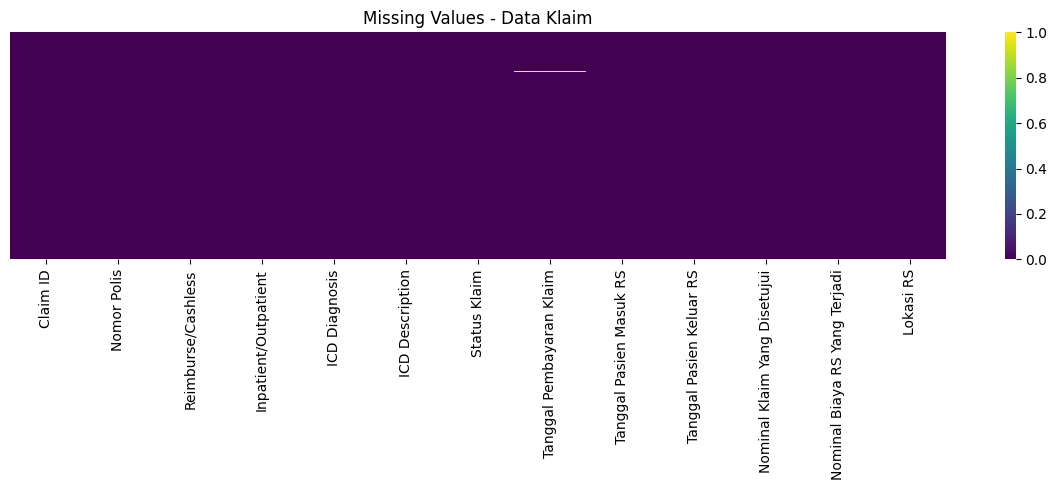


Filter PAID: 4627 rows
Duplikat dihapus: 0 rows

Winsorize 1%-99% selesai
   Lower bound : Rp 187,242
   Upper bound : Rp 633,686,130

Cell 1 selesai
   Polis  : (4096, 9)
   Klaim  : (4627, 14)
   Merged : (4627, 21)


In [ ]:
# LOAD DATA DAN PREPROCESSING

df_polis = pd.read_csv('Data_Polis.csv')
df_klaim = pd.read_csv('Data_Klaim.csv')

# Strip whitespace semua kolom string
df_polis.columns = df_polis.columns.str.strip()
df_klaim.columns = df_klaim.columns.str.strip()

for col in df_polis.select_dtypes('object').columns:
    df_polis[col] = df_polis[col].str.strip()
for col in df_klaim.select_dtypes('object').columns:
    df_klaim[col] = df_klaim[col].str.strip()

# Parse tanggal polis
df_polis['Tanggal Lahir'] = pd.to_datetime(df_polis['Tanggal Lahir'], format='%Y%m%d')
df_polis['Tanggal Efektif Polis'] = pd.to_datetime(df_polis['Tanggal Efektif Polis'], format='%Y%m%d')

# Parse tanggal klaim
df_klaim['Tanggal Pembayaran Klaim'] = pd.to_datetime(df_klaim['Tanggal Pembayaran Klaim'], errors='coerce')
df_klaim['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_klaim['Tanggal Pasien Masuk RS'],  errors='coerce')
df_klaim['Tanggal Pasien Keluar RS'] = pd.to_datetime(df_klaim['Tanggal Pasien Keluar RS'], errors='coerce')

# Identifikasi missing values
print("MISSING VALUES - DATA POLIS")
mv_polis = df_polis.isnull().sum()
print(mv_polis[mv_polis > 0] if mv_polis.sum() > 0 else "Tidak ada missing value")

print("\nMISSING VALUES - DATA KLAIM")
mv_klaim = df_klaim.isnull().sum()
print(mv_klaim[mv_klaim > 0] if mv_klaim.sum() > 0 else "Tidak ada missing value")

# Visualisasi missing values dengan heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df_klaim.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values - Data Klaim')
plt.tight_layout()
plt.show()

# Filter hanya klaim PAID dan hapus duplikat
df_klaim = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()
before = len(df_klaim)
df_klaim = df_klaim.drop_duplicates(subset='Claim ID')
print(f"\nFilter PAID: {len(df_klaim)} rows")
print(f"Duplikat dihapus: {before - len(df_klaim)} rows")

# Normalisasi melalui Winsorizing 1%-99% di level individual klaim
# Pendekatan ini dipilih karena:
# 1. Data klaim asuransi sangat skewed — winsorize lebih tepat dari StandardScaler
# 2. LightGBM sebagai tree-based model invariant terhadap monotonic transformation
# 3. Winsorize mempertahankan interpretabilitas skala asli untuk kebutuhan aktuaria

low_p  = np.percentile(df_klaim['Nominal Klaim Yang Disetujui'], 1)
high_p = np.percentile(df_klaim['Nominal Klaim Yang Disetujui'], 99)
df_klaim['Nominal Klaim Yang Disetujui'] = df_klaim['Nominal Klaim Yang Disetujui'].clip(low_p, high_p)

print(f"\nWinsorize 1%-99% selesai")
print(f"Lower bound : Rp {low_p:,.0f}")
print(f"Upper bound : Rp {high_p:,.0f}")

# Periode klaim dari tanggal masuk RS
df_klaim['Periode_Klaim'] = (
    df_klaim['Tanggal Pasien Masuk RS']
    .dt.to_period('M')
    .dt.to_timestamp()
)

# Feature engineering polis
reference_date = pd.Timestamp('2025-07-01')

df_polis['Umur'] = (
    (reference_date - df_polis['Tanggal Lahir']).dt.days / 365.25
).astype(int)

df_polis['Lama_Polis'] = (
    (reference_date - df_polis['Tanggal Efektif Polis']).dt.days / 365.25
).round(2)

df_polis['Kelompok_Umur'] = pd.cut(
    df_polis['Umur'],
    bins=[0, 17, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '>60']
)

# Merge polis ke klaim untuk analisis
df_merged = df_klaim.merge(
    df_polis[['Nomor Polis', 'Gender', 'Plan Code', 'Umur', 'Lama_Polis', 'Kelompok_Umur']],
    on='Nomor Polis',
    how='left'
)

df_merged['Length_of_Stay'] = (
    df_merged['Tanggal Pasien Keluar RS'] - df_merged['Tanggal Pasien Masuk RS']
).dt.days.clip(lower=0)

df_merged['Claim_Ratio'] = (
    df_merged['Nominal Klaim Yang Disetujui'] / df_merged['Nominal Biaya RS Yang Terjadi'].replace(0, np.nan)
).fillna(0).clip(0, 1)

print(f"\nCell 1 selesai")
print(f"Polis : {df_polis.shape}")
print(f"Klaim : {df_klaim.shape}")
print(f"Merged : {df_merged.shape}")

## Cell 2
## Exploratory Data Analysis (EDA)

### Tujuan
Memahami karakteristik distribusi, tren temporal, dan hubungan antar variabel pada data klaim sebelum masuk ke tahap pemodelan. EDA dilakukan pada dua level:
- **Level individual klaim** distribusi nominal, perbandingan antar kategori demografis dan produk
- **Level portofolio bulanan** tren frekuensi, severitas, dan total klaim dari waktu ke waktu

### Visualisasi yang Dihasilkan
| Plot | Deskripsi |
|---|---|
| 1 | Distribusi nominal klaim (histogram) |
| 2 | Boxplot nominal per gender |
| 3 | Boxplot nominal per kelompok umur |
| 4 | Boxplot nominal per plan code |
| 5 | Boxplot nominal per tipe layanan (Inpatient/Outpatient) |
| 6 | Boxplot nominal per metode klaim (Cashless/Reimburse) |
| 7 | Scatter plot: Umur vs nominal klaim |
| 8 | Scatter plot: Length of Stay vs nominal klaim |
| 9 | Bar chart: jumlah klaim per kelompok umur |
| 10 | Bar chart: tren frekuensi klaim bulanan |
| 11 | Line chart: tren severitas klaim bulanan |
| 12 | Line chart: tren total klaim bulanan |
| 13 | Bar chart: Top 10 ICD diagnosis |
| 14 | Heatmap korelasi fitur numerik |
| 15 | Pie chart: proporsi Inpatient vs Outpatient |

### Temuan Utama

**Distribusi & Outlier**
- Distribusi nominal klaim sangat right-skewed mayoritas klaim di bawah Rp 50 juta, namun terdapat outlier hingga Rp 633 juta setelah winsorisasi
- Puncak distribusi berada di bawah Rp 20 juta dengan frekuensi lebih dari 2.000 klaim

**Faktor Demografis**
- Gender tidak menunjukkan perbedaan signifikan pada median nominal klaim (F dan M hampir identik)
- Kelompok umur >60 tahun memiliki median tertinggi; kelompok 31-45 memiliki jangkauan terluas (outlier >Rp 160 juta)
- Kelompok umur >60 mendominasi frekuensi klaim dengan lebih dari 2.200 kasus

**Faktor Produk & Layanan**
- Plan M-003 memiliki median nominal klaim tertinggi; Plan M-001 memiliki nilai maksimum tertinggi
- Inpatient (IP) menyumbang 49,2% volume klaim dengan nilai per klaim tertinggi (maks >Rp 175 juta)
- Metode Cashless secara konsisten menghasilkan median klaim lebih tinggi dibanding Reimburse (~Rp 20 juta vs <Rp 10 juta)

**Tren Temporal**
- Puncak historis: Januari 2024 (302 klaim, severitas Rp 62,75 juta, total Rp 18,95 miliar)
- Setelah Januari 2024, frekuensi stabil di 208-278 klaim/bulan
- Titik terendah: Januari 2025 (<Rp 10 miliar total) sebelum rebound di 2025
- Lonjakan severitas kembali terjadi di Februari 2025 (Rp 58,3 juta)

**Korelasi**
- Length of Stay adalah prediktor numerik terkuat berdasarkan uji Spearman di Cell 9A (ρ=0,503). Heatmap di Cell ini menggunakan korelasi Pearson yang menghasilkan nilai berbeda (0,422) karena metode perhitungan yang berbeda, Spearman lebih robust terhadap outlier dan distribusi skewed
- Umur berkorelasi positif lemah dengan nominal klaim (Spearman ρ=0,136)
- Lama_Polis dan Claim_Ratio tidak signifikan

**Top Diagnosis**
- N18.0 (gagal ginjal stadium akhir): ~300 klaim - tertinggi
- C50 (kanker payudara) dan H26 (katarak): masing-masing >200 klaim
- Ketiga diagnosis ini sangat berkorelasi dengan dominasi kelompok umur >60 tahun

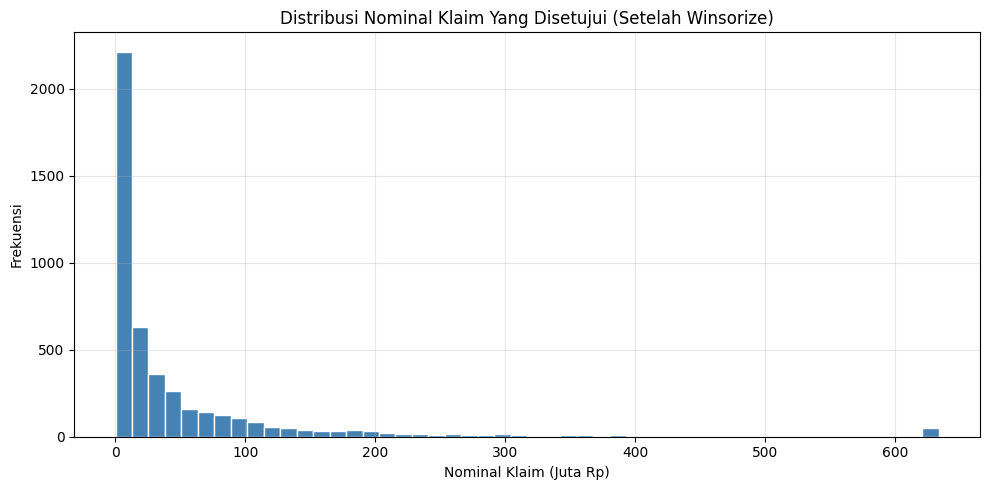

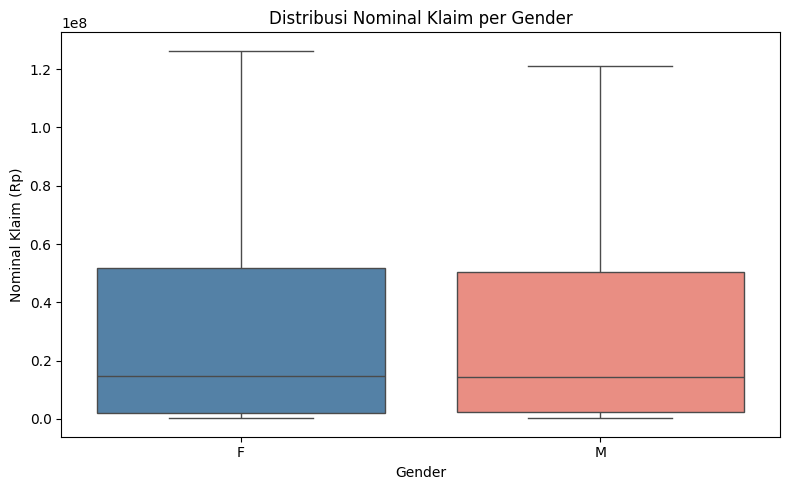

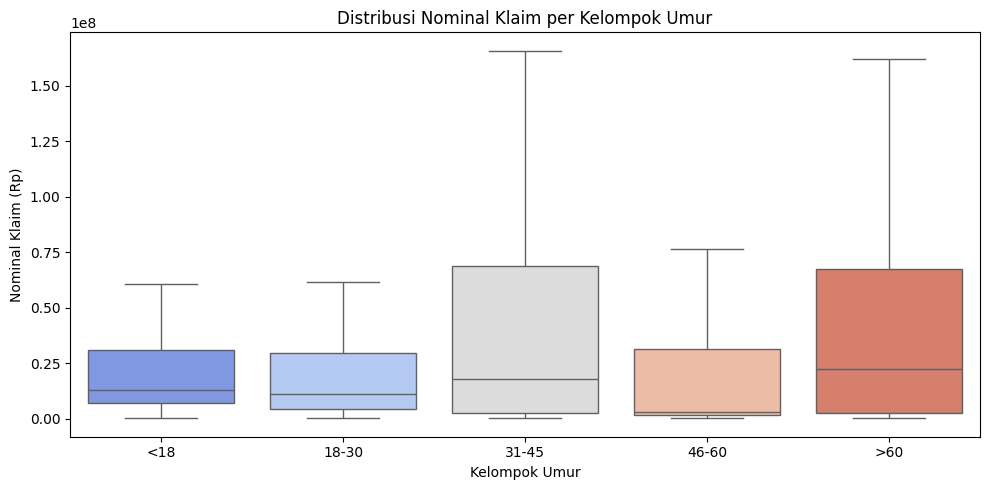

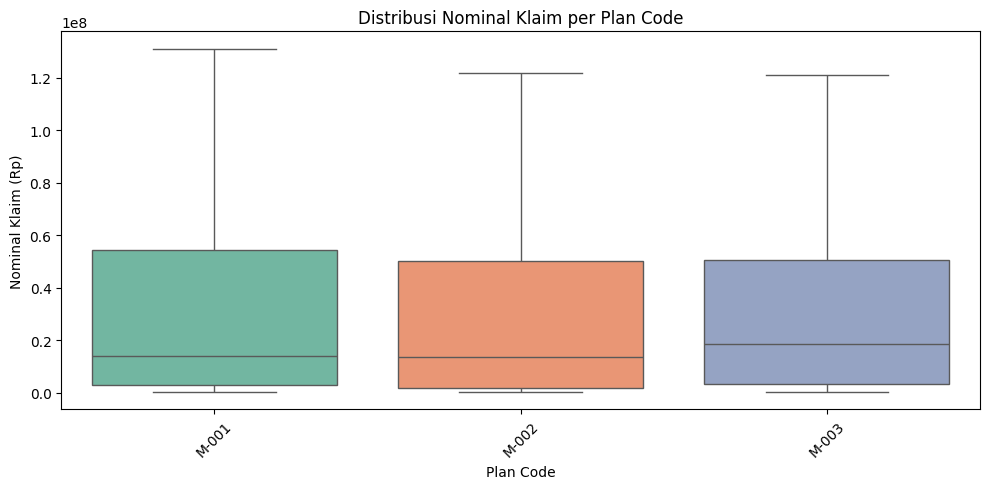

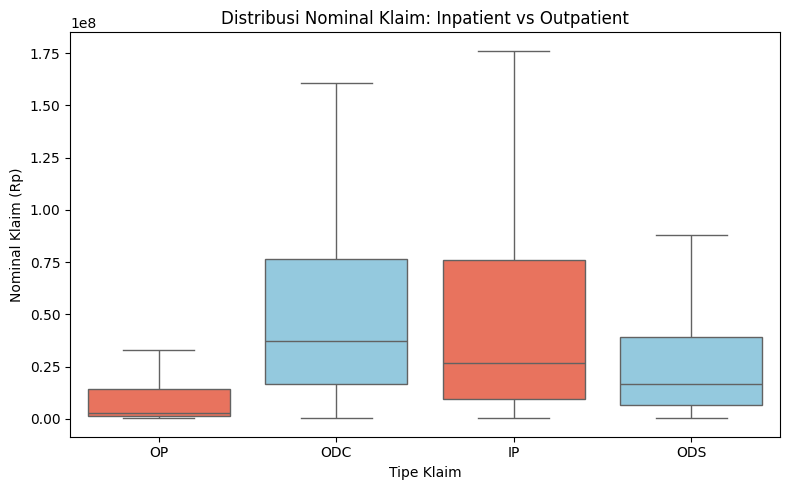

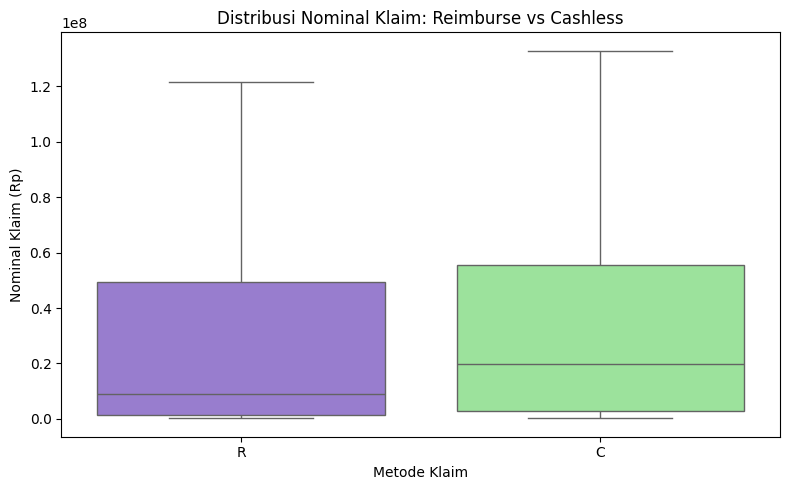

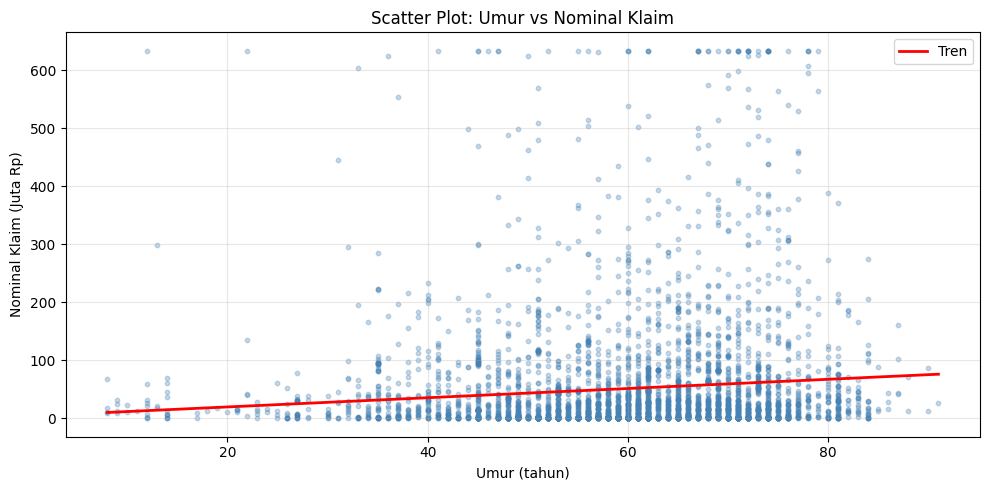

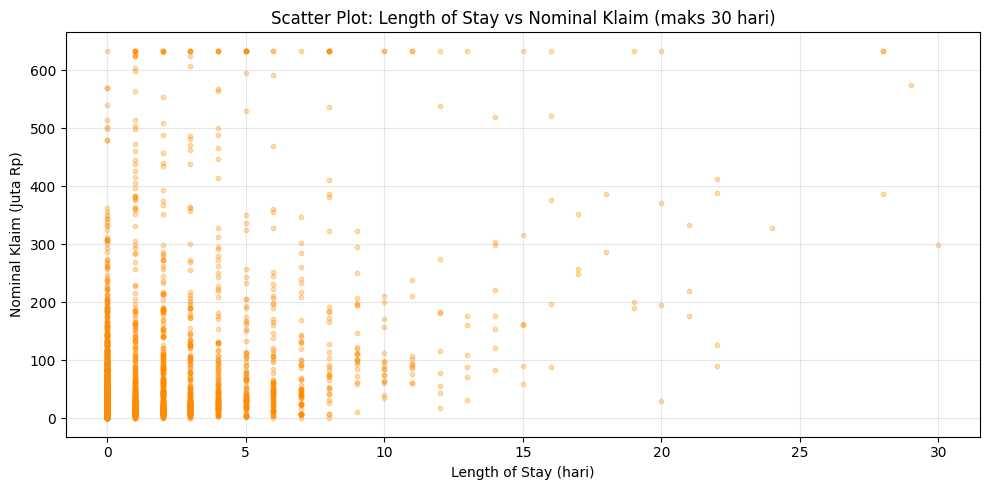

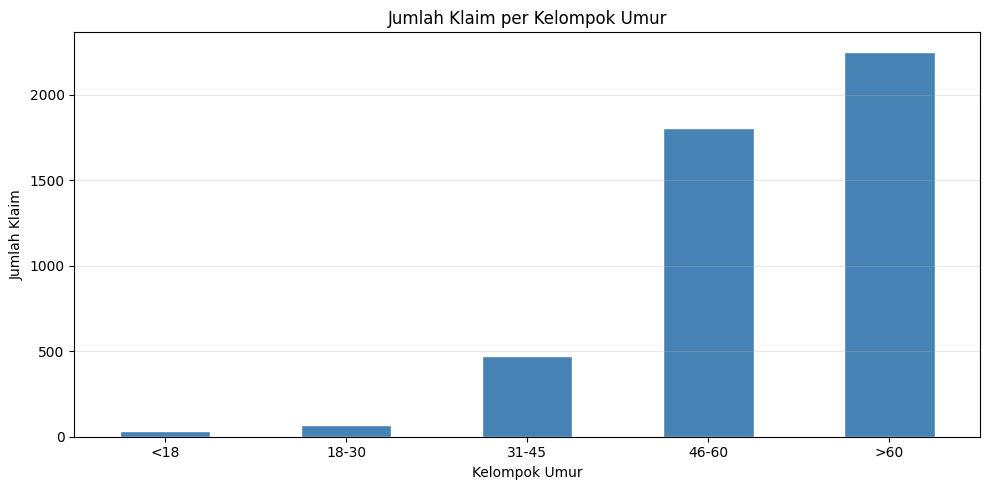

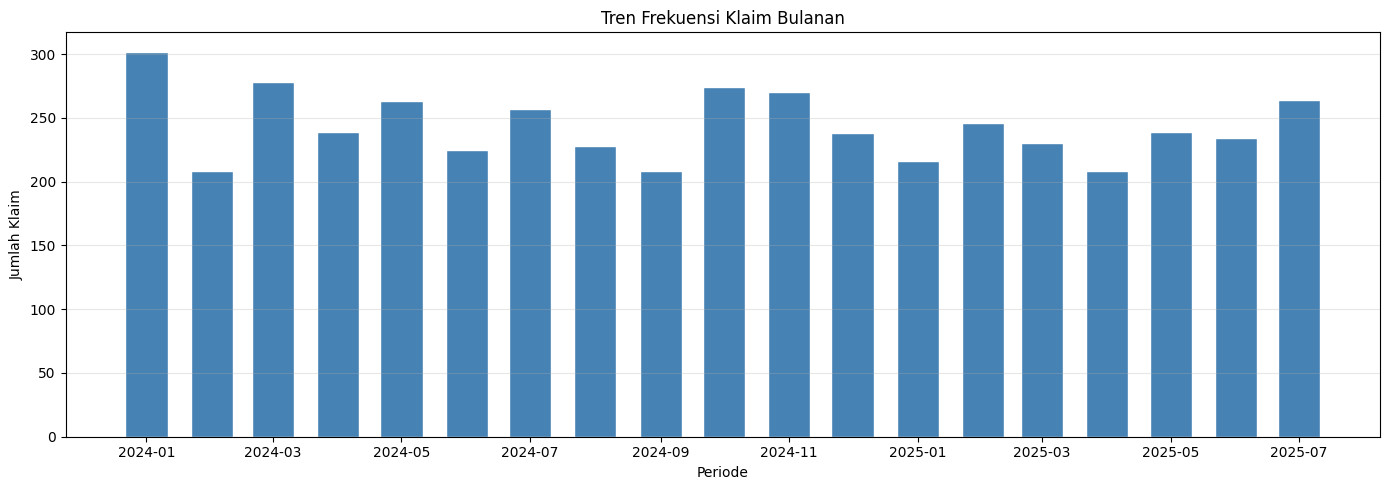

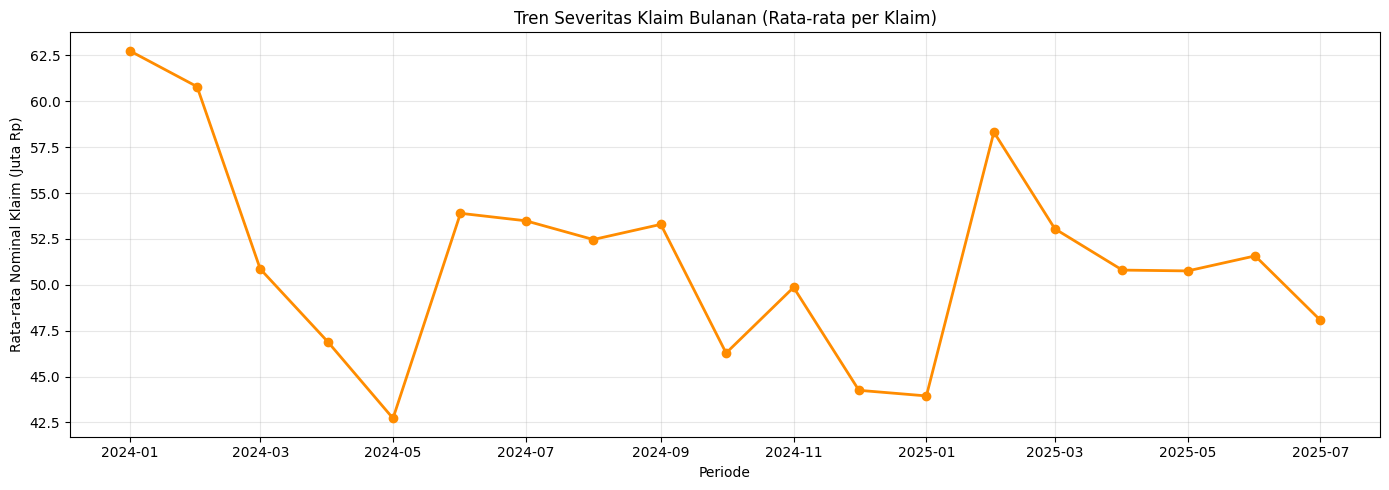

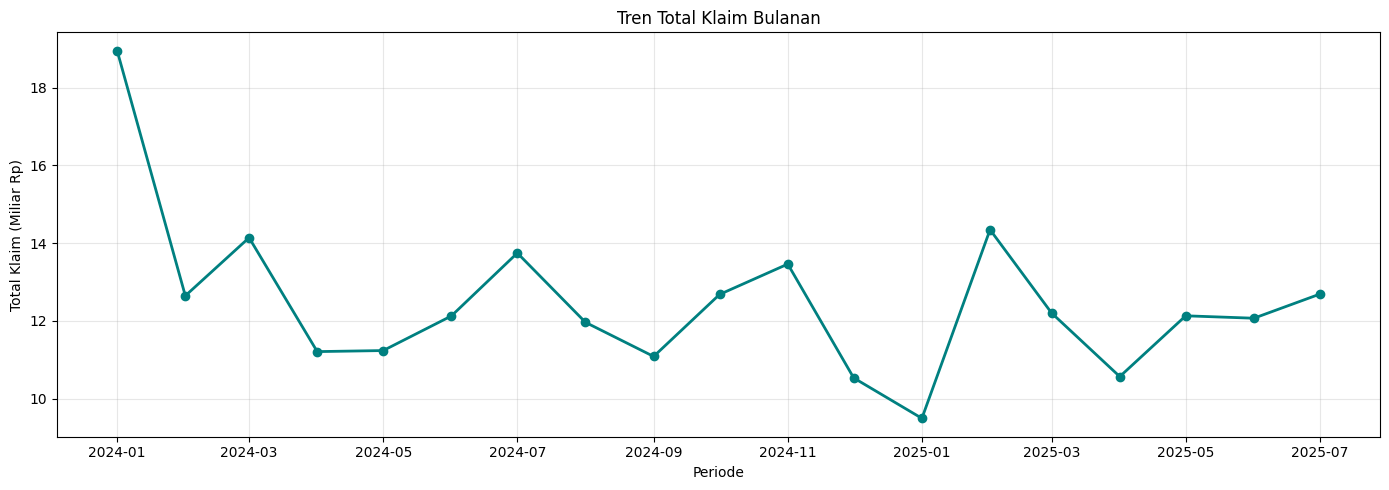

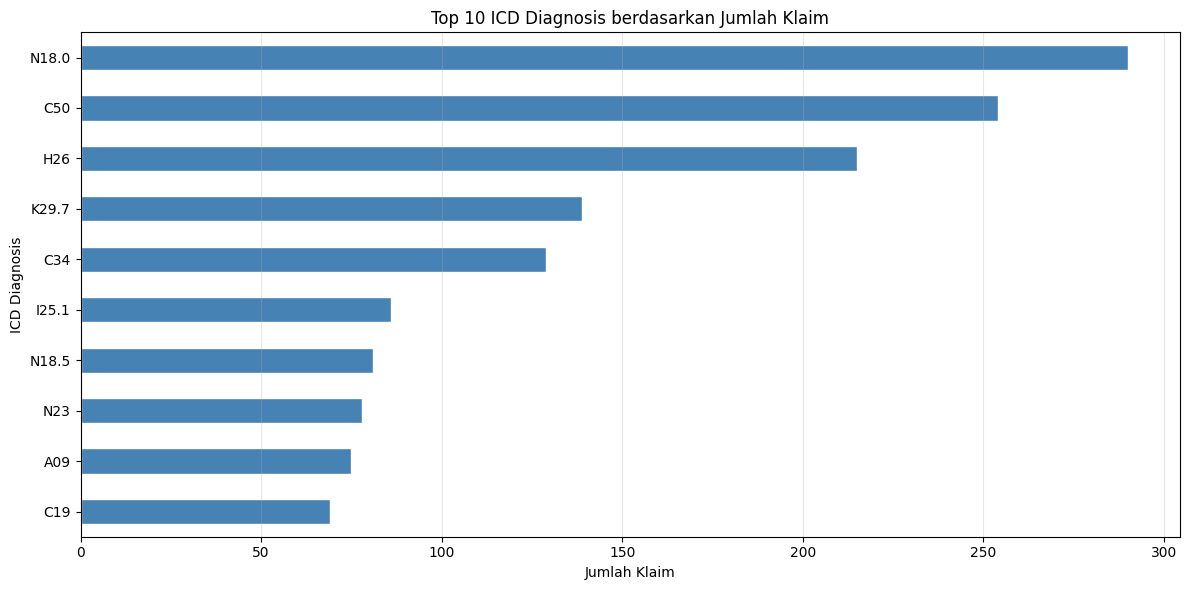

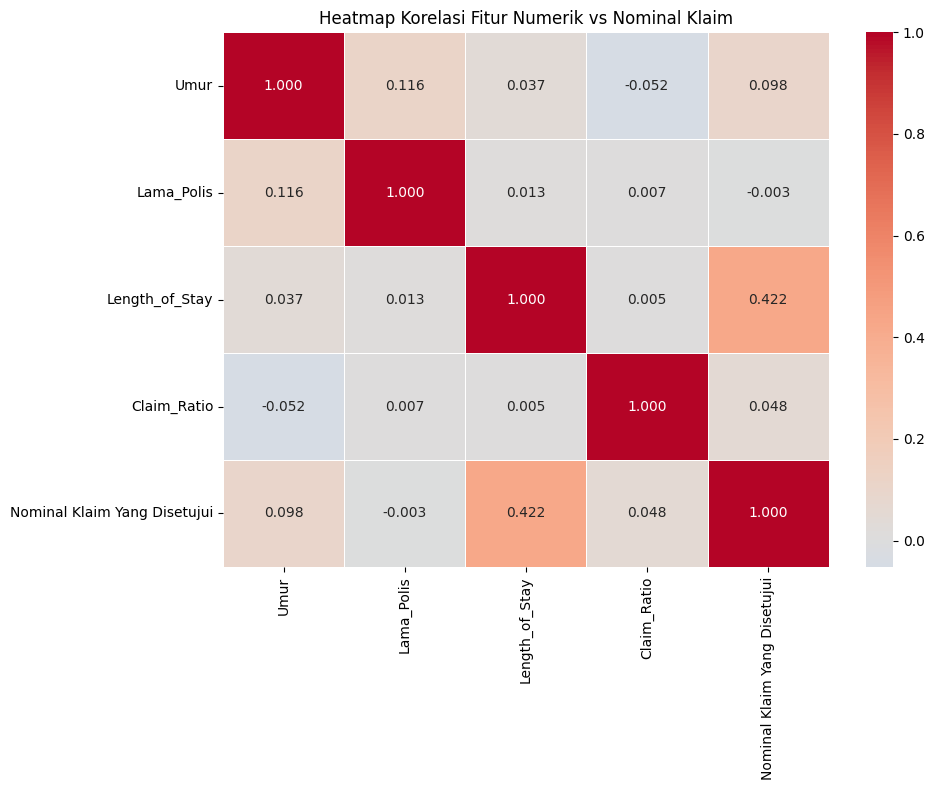

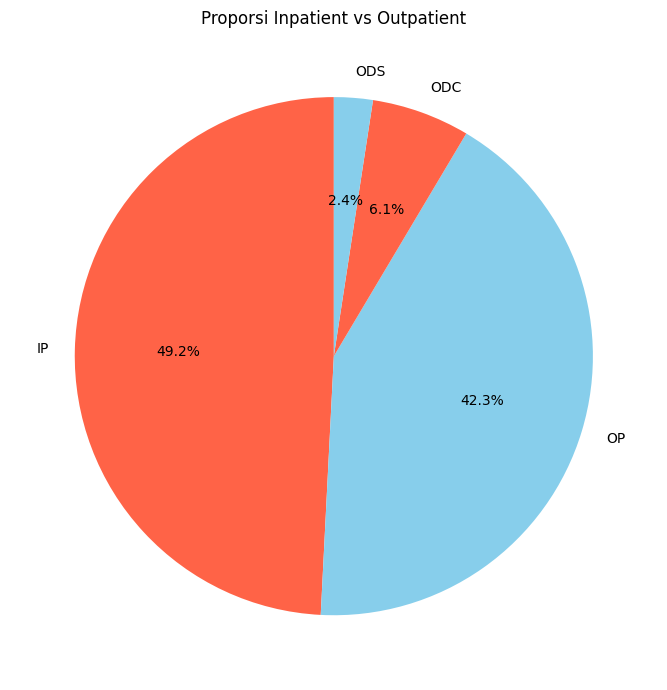

In [ ]:
# EKSPLORASI DATA (EDA)

target_col = 'Nominal Klaim Yang Disetujui'

# 1. Distribusi Nominal Klaim setelah winsorize
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_klaim[target_col] / 1e6, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribusi Nominal Klaim Yang Disetujui (Setelah Winsorize)')
ax.set_xlabel('Nominal Klaim (Juta Rp)')
ax.set_ylabel('Frekuensi')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Boxplot Nominal Klaim per Gender
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_merged, x='Gender', y=target_col, palette=['steelblue', 'salmon'], showfliers=False, ax=ax)
ax.set_title('Distribusi Nominal Klaim per Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Nominal Klaim (Rp)')
plt.tight_layout()
plt.show()

# 3. Boxplot Nominal Klaim per Kelompok Umur
fig, ax = plt.subplots(figsize=(10, 5))
order = ['<18', '18-30', '31-45', '46-60', '>60']
sns.boxplot(data=df_merged, x='Kelompok_Umur', y=target_col, order=order, palette='coolwarm', showfliers=False, ax=ax)
ax.set_title('Distribusi Nominal Klaim per Kelompok Umur')
ax.set_xlabel('Kelompok Umur')
ax.set_ylabel('Nominal Klaim (Rp)')
plt.tight_layout()
plt.show()

# 4. Boxplot Nominal Klaim per Plan Code
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_merged, x='Plan Code', y=target_col, palette='Set2', showfliers=False, ax=ax)
ax.set_title('Distribusi Nominal Klaim per Plan Code')
ax.set_xlabel('Plan Code')
ax.set_ylabel('Nominal Klaim (Rp)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 5. Boxplot Nominal Klaim: Inpatient vs Outpatient
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_merged, x='Inpatient/Outpatient', y=target_col, palette=['tomato', 'skyblue'], showfliers=False, ax=ax)
ax.set_title('Distribusi Nominal Klaim: Inpatient vs Outpatient')
ax.set_xlabel('Tipe Klaim')
ax.set_ylabel('Nominal Klaim (Rp)')
plt.tight_layout()
plt.show()

# 6. Boxplot Nominal Klaim: Reimburse vs Cashless
if 'Reimburse/Cashless' in df_merged.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df_merged, x='Reimburse/Cashless', y=target_col, palette=['mediumpurple', 'lightgreen'], showfliers=False, ax=ax)
    ax.set_title('Distribusi Nominal Klaim: Reimburse vs Cashless')
    ax.set_xlabel('Metode Klaim')
    ax.set_ylabel('Nominal Klaim (Rp)')
    plt.tight_layout()
    plt.show()

# 7. Scatter plot: Umur vs Nominal Klaim
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_merged['Umur'], df_merged[target_col] / 1e6, alpha=0.3, color='steelblue', s=10)
z = np.polyfit(df_merged['Umur'].dropna(), df_merged.loc[df_merged['Umur'].notna(), target_col] / 1e6, 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_merged['Umur'].min(), df_merged['Umur'].max(), 100)
ax.plot(x_line, p_line(x_line), color='red', linewidth=2, label='Tren')
ax.set_title('Scatter Plot: Umur vs Nominal Klaim')
ax.set_xlabel('Umur (tahun)')
ax.set_ylabel('Nominal Klaim (Juta Rp)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Scatter plot: Length of Stay vs Nominal Klaim
fig, ax = plt.subplots(figsize=(10, 5))
los_clean = df_merged[df_merged['Length_of_Stay'] <= 30]
ax.scatter(los_clean['Length_of_Stay'], los_clean[target_col] / 1e6, alpha=0.3, color='darkorange', s=10)
ax.set_title('Scatter Plot: Length of Stay vs Nominal Klaim (maks 30 hari)')
ax.set_xlabel('Length of Stay (hari)')
ax.set_ylabel('Nominal Klaim (Juta Rp)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Histogram jumlah klaim per kelompok umur
fig, ax = plt.subplots(figsize=(10, 5))
freq_umur = df_merged.groupby('Kelompok_Umur')['Claim ID'].count().reindex(order)
freq_umur.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Jumlah Klaim per Kelompok Umur')
ax.set_xlabel('Kelompok Umur')
ax.set_ylabel('Jumlah Klaim')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 10. Tren frekuensi klaim bulanan
fig, ax = plt.subplots(figsize=(14, 5))
monthly_freq = df_klaim.groupby('Periode_Klaim')['Claim ID'].count()
ax.bar(monthly_freq.index, monthly_freq.values, color='steelblue', edgecolor='white', width=20)
ax.set_title('Tren Frekuensi Klaim Bulanan')
ax.set_xlabel('Periode')
ax.set_ylabel('Jumlah Klaim')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 11. Tren severitas klaim bulanan
fig, ax = plt.subplots(figsize=(14, 5))
monthly_sev = df_klaim.groupby('Periode_Klaim')['Nominal Klaim Yang Disetujui'].mean()
ax.plot(monthly_sev.index, monthly_sev.values / 1e6, marker='o', color='darkorange', linewidth=2)
ax.set_title('Tren Severitas Klaim Bulanan (Rata-rata per Klaim)')
ax.set_xlabel('Periode')
ax.set_ylabel('Rata-rata Nominal Klaim (Juta Rp)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 12. Tren total klaim bulanan
fig, ax = plt.subplots(figsize=(14, 5))
monthly_total = df_klaim.groupby('Periode_Klaim')['Nominal Klaim Yang Disetujui'].sum()
ax.plot(monthly_total.index, monthly_total.values / 1e9, marker='o', color='teal', linewidth=2)
ax.set_title('Tren Total Klaim Bulanan')
ax.set_xlabel('Periode')
ax.set_ylabel('Total Klaim (Miliar Rp)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 13. Top 10 ICD Diagnosis berdasarkan jumlah klaim
fig, ax = plt.subplots(figsize=(12, 6))
top_icd = (df_merged['ICD Diagnosis']
           .value_counts()
           .head(10))
top_icd.sort_values().plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Top 10 ICD Diagnosis berdasarkan Jumlah Klaim')
ax.set_xlabel('Jumlah Klaim')
ax.set_ylabel('ICD Diagnosis')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 14. Heatmap korelasi fitur numerik
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = ['Umur', 'Lama_Polis', 'Length_of_Stay', 'Claim_Ratio', target_col]
corr_matrix = df_merged[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Heatmap Korelasi Fitur Numerik vs Nominal Klaim')
plt.tight_layout()
plt.show()

# 15. Proporsi Inpatient vs Outpatient
fig, ax = plt.subplots(figsize=(7, 7))
inout = df_merged['Inpatient/Outpatient'].value_counts()
ax.pie(inout.values, labels=inout.index, autopct='%1.1f%%', colors=['tomato', 'skyblue'], startangle=90)
ax.set_title('Proporsi Inpatient vs Outpatient')
plt.tight_layout()
plt.show()

## Cell 3
## Agregasi Bulanan, Exposure, dan Feature Engineering

### Tujuan
Mengubah data klaim level individual menjadi data time series bulanan yang siap digunakan oleh ketiga model (Prophet, LightGBM, Seasonal Naive). Tiga target variabel yang diprediksi adalah:
- **Claim_Frequency** jumlah klaim per bulan
- **Claim_Severity** rata-rata nominal klaim per bulan
- **Total_Claim** total nominal klaim per bulan

### Agregasi Bulanan
Klaim dikelompokkan berdasarkan bulan masuk RS (Tanggal Pasien Masuk RS), menghasilkan 19 titik data bulanan (Januari 2024 - Juli 2025).

### Exposure
Exposure didefinisikan sebagai jumlah polis aktif per akhir bulan. Hasil 
regresi linear menunjukkan **slope = 0,00 polis/bulan**, artinya portofolio 
stabil di 4.096 polis sepanjang periode historis. Proyeksi exposure untuk 
17 bulan ke depan dipertahankan di 4.096 polis.

> Exposure menunjukkan feature importance 0% pada semua model karena tidak 
> ada variasi antar bulan dalam data historis bukan karena variabel ini 
> tidak relevan secara aktuaria. Exposure tetap dipertahankan dalam feature 
> sets karena dua alasan: (1) dalam standar aktuaria, exposure adalah 
> variabel fundamental dalam pricing dan reserving; (2) jika portofolio 
> berubah di masa depan (akuisisi, lapse massal), model dapat langsung 
> mengakomodasi tanpa re-engineering fitur.


### Feature Engineering untuk LightGBM
Fitur dibangun dalam beberapa kategori:

**1. Fitur Kalender**
- `Time_Index` indeks waktu linear
- `Month`, `Quarter` bulan dan kuartal numerik

**2. Cyclical Encoding**
- `Month_Sin`, `Month_Cos` encoding sinus/cosinus bulan untuk menghindari diskontinuitas bulan 12 sampai bulan 1
- `Quarter_Sin`, `Quarter_Cos` encoding kuartalan

**3. Lag Features** *(tanpa Lag-12 dan YoY untuk mencegah data leakage di 2026)*
- `Freq_Lag_1/2/3`, `Sev_Lag_1/2/3`, `Total_Lag_1/2`

**4. Rolling Statistics**
- Rolling mean 3 dan 6 bulan: `Freq_Rolling_3/6`, `Sev_Rolling_3/6`, `Total_Rolling_3/6`
- Rolling std 3 bulan: `Freq_Std_3`, `Sev_Std_3`

**5. Growth Rate**
- `Freq_Growth`, `Sev_Growth` pertumbuhan Month-over-Month

### Seasonal Naive
Nilai rata-rata historis per bulan kalender dihitung sebagai baseline. Untuk bulan dengan hanya 1 observasi, digunakan blending 50% nilai aktual + 50% rata-rata bulan sekitarnya untuk mengurangi sensitivitas terhadap single data point.

### Ringkasan Feature Sets
| Target | Jumlah Fitur |
|---|---|
| Claim Frequency | 12 fitur |
| Claim Severity | 12 fitur |
| Total Claim | 11 fitur |

In [ ]:
# AGREGASI BULANAN, EXPOSURE, DAN FEATURE ENGINEERING

# Agregasi bulanan
df_monthly = df_klaim.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum'),
    Claim_Severity=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()

df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

print("DATA BULANAN")
display(df_monthly)
print(f"\nRentang  : {df_monthly['Periode_Klaim'].min()} -> {df_monthly['Periode_Klaim'].max()}")
print(f"Total : {len(df_monthly)} bulan")

# Exposure per bulan jumlah polis aktif
exposure_list = []
for period in df_monthly['Periode_Klaim']:
    period_end = period + pd.offsets.MonthEnd(0)
    n_active = df_polis[
        df_polis['Tanggal Efektif Polis'] <= period_end
    ].shape[0]
    exposure_list.append({'Periode_Klaim': period, 'Exposure': n_active})

df_exposure = pd.DataFrame(exposure_list)
df_monthly = df_monthly.merge(df_exposure, on='Periode_Klaim', how='left')

df_monthly['Claim_Rate'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Exposure']
)

print("\nEXPOSURE PER BULAN")
display(df_monthly[['Periode_Klaim', 'Exposure', 'Claim_Rate']])

# Exposure forecast dengan tren linear
time_idx = np.arange(len(df_monthly))
exp_values = df_monthly['Exposure'].values
coeffs = np.polyfit(time_idx, exp_values, 1)
exposure_poly = np.poly1d(coeffs)

future_idx_start = len(df_monthly)
future_exposure = [
    max(int(exposure_poly(future_idx_start + i)), df_monthly['Exposure'].max())
    for i in range(17)
]

print(f"\nTren linear exposure: slope = {coeffs[0]:.2f} polis/bulan")
print(f"Exposure historis terakhir : {df_monthly['Exposure'].iloc[-1]}")
print(f"Exposure forecast bulan 1 : {future_exposure[0]}")
print(f"Exposure forecast bulan 17 : {future_exposure[16]}")

# Calendar features
df_monthly['Time_Index'] = np.arange(len(df_monthly))
df_monthly['Month'] = df_monthly['Periode_Klaim'].dt.month
df_monthly['Quarter'] = df_monthly['Periode_Klaim'].dt.quarter

# Cyclical encoding menghindari discontinuity di bulan 12 ke 1
df_monthly['Month_Sin'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Month_Cos'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Quarter_Sin'] = np.sin(2 * np.pi * df_monthly['Quarter'] / 4)
df_monthly['Quarter_Cos'] = np.cos(2 * np.pi * df_monthly['Quarter'] / 4)

# Lag features — tanpa Lag_12 dan YoY untuk menghindari leakage di 2026
df_monthly['Freq_Lag_1'] = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_2'] = df_monthly['Claim_Frequency'].shift(2)
df_monthly['Freq_Lag_3'] = df_monthly['Claim_Frequency'].shift(3)

df_monthly['Sev_Lag_1'] = df_monthly['Claim_Severity'].shift(1)
df_monthly['Sev_Lag_2'] = df_monthly['Claim_Severity'].shift(2)
df_monthly['Sev_Lag_3'] = df_monthly['Claim_Severity'].shift(3)

df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)
df_monthly['Total_Lag_2'] = df_monthly['Total_Claim'].shift(2)

# Rolling features
df_monthly['Freq_Rolling_3'] = df_monthly['Claim_Frequency'].shift(1).rolling(3).mean()
df_monthly['Sev_Rolling_3'] = df_monthly['Claim_Severity'].shift(1).rolling(3).mean()
df_monthly['Total_Rolling_3'] = df_monthly['Total_Claim'].shift(1).rolling(3).mean()

df_monthly['Freq_Rolling_6'] = df_monthly['Claim_Frequency'].shift(1).rolling(6).mean()
df_monthly['Sev_Rolling_6'] = df_monthly['Claim_Severity'].shift(1).rolling(6).mean()
df_monthly['Total_Rolling_6'] = df_monthly['Total_Claim'].shift(1).rolling(6).mean()

df_monthly['Freq_Std_3'] = df_monthly['Claim_Frequency'].shift(1).rolling(3).std()
df_monthly['Sev_Std_3'] = df_monthly['Claim_Severity'].shift(1).rolling(3).std()

# Growth rate MoM
df_monthly['Freq_Growth'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Freq_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

df_monthly['Sev_Growth'] = (
    df_monthly['Claim_Severity'] / df_monthly['Sev_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

# Seasonal Naive precompute
# Bulan dengan 1 observasi: blend 50% aktual + 50% surrounding mean
seasonal_naive = {}
for month in range(1, 13):
    month_data  = df_monthly[df_monthly['Month'] == month]
    surrounding = df_monthly[
        df_monthly['Month'].isin(
            [(month - 1) % 12 + 1, month, (month + 1) % 12 + 1]
        )
    ]
    for target in ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']:
        if len(month_data) >= 2:
            val = month_data[target].mean()
        else:
            actual_val = month_data[target].mean() if len(month_data) > 0 \
              else surrounding[target].mean()
            surrounding_val = surrounding[target].mean()
            val = 0.5 * actual_val + 0.5 * surrounding_val
        seasonal_naive[(month, target)] = val

print("\nSeasonal Naive per bulan:")
for month in range(1, 13):
    print(f"Bulan {month:02d} | "
          f"Freq: {seasonal_naive[(month, 'Claim_Frequency')]:.1f} | "
          f"Sev: {seasonal_naive[(month, 'Claim_Severity')]/1e6:.2f}M | "
          f"Total: {seasonal_naive[(month, 'Total_Claim')]/1e9:.3f}B")

# Feature sets per target
FEATURES_FREQ = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_3',
    'Freq_Rolling_3', 'Freq_Rolling_6', 'Freq_Std_3',
    'Total_Lag_1',
]

FEATURES_SEV = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Sev_Lag_1', 'Sev_Lag_2', 'Sev_Lag_3',
    'Sev_Rolling_3', 'Sev_Rolling_6', 'Sev_Std_3',
    'Freq_Lag_1',
]

FEATURES_TOTAL = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Total_Lag_1', 'Total_Lag_2',
    'Total_Rolling_3', 'Total_Rolling_6',
    'Freq_Lag_1', 'Sev_Lag_1',
]

print(f"\nFeature sets:")
print(f"Frequency : {len(FEATURES_FREQ)} fitur")
print(f"Severity : {len(FEATURES_SEV)} fitur")
print(f"Total : {len(FEATURES_TOTAL)} fitur")

DATA BULANAN


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity
0,2024-01-01,302,1.895190e+10,6.275465e+07
1,2024-02-01,208,1.264589e+10,6.079755e+07
2,2024-03-01,278,1.414070e+10,5.086583e+07
3,2024-04-01,239,1.120960e+10,4.690211e+07
4,2024-05-01,263,1.123643e+10,4.272406e+07
5,2024-06-01,225,1.212653e+10,5.389569e+07
6,2024-07-01,257,1.374646e+10,5.348818e+07
7,2024-08-01,228,1.196234e+10,5.246642e+07
8,2024-09-01,208,1.108477e+10,5.329216e+07
9,2024-10-01,274,1.268139e+10,4.628243e+07



Rentang  : 2024-01-01 00:00:00 -> 2025-07-01 00:00:00
Total    : 19 bulan

EXPOSURE PER BULAN


,Periode_Klaim,Exposure,Claim_Rate
0,2024-01-01,4096,0.073730
1,2024-02-01,4096,0.050781
2,2024-03-01,4096,0.067871
3,2024-04-01,4096,0.058350
4,2024-05-01,4096,0.064209
5,2024-06-01,4096,0.054932
6,2024-07-01,4096,0.062744
7,2024-08-01,4096,0.055664
8,2024-09-01,4096,0.050781
9,2024-10-01,4096,0.066895



Tren linear exposure: slope = 0.00 polis/bulan
   Exposure historis terakhir : 4096
   Exposure forecast bulan 1  : 4096
   Exposure forecast bulan 17 : 4096

Seasonal Naive per bulan:
   Bulan 01 | Freq: 259.0 | Sev: 53.35M | Total: 14.222B
   Bulan 02 | Freq: 227.0 | Sev: 59.56M | Total: 13.496B
   Bulan 03 | Freq: 254.0 | Sev: 51.96M | Total: 13.171B
   Bulan 04 | Freq: 223.5 | Sev: 48.85M | Total: 10.888B
   Bulan 05 | Freq: 251.0 | Sev: 46.74M | Total: 11.684B
   Bulan 06 | Freq: 229.5 | Sev: 52.74M | Total: 12.098B
   Bulan 07 | Freq: 260.5 | Sev: 50.78M | Total: 13.218B
   Bulan 08 | Freq: 239.5 | Sev: 50.92M | Total: 12.142B
   Bulan 09 | Freq: 223.5 | Sev: 52.43M | Total: 11.679B
   Bulan 10 | Freq: 265.0 | Sev: 45.77M | Total: 12.144B
   Bulan 11 | Freq: 266.3 | Sev: 51.02M | Total: 13.715B
   Bulan 12 | Freq: 234.3 | Sev: 49.35M | Total: 11.520B

Feature sets:
   Frequency : 12 fitur
   Severity  : 12 fitur
   Total     : 11 fitur


## Cell 4
## Walk-Forward Cross-Validation dan Bobot Ensemble

### Tujuan
Mengevaluasi performa ketiga model (Prophet, LightGBM, Seasonal Naive) secara objektif menggunakan walk-forward cross-validation, lalu menghitung bobot ensemble berdasarkan hasil validasi tersebut.

### Mengapa Walk-Forward, Bukan Random Split?
Data time series memiliki ketergantungan temporal nilai bulan ini dipengaruhi oleh bulan sebelumnya. Random split akan menciptakan **data leakage** karena data masa depan bisa masuk ke training set. Walk-forward memastikan model selalu dilatih pada data masa lalu dan divalidasi pada data masa depan, persis seperti kondisi forecasting nyata.

### Konfigurasi Validasi
- **Minimum training**: 14 bulan
- **Jumlah fold**: 5
- **Periode validasi**: Maret 2025 - Juli 2025

| Fold | Training | Validasi |
|---|---|---|
| 1 | Jan 2024 - Feb 2025 (14 bln) | Mar 2025 |
| 2 | Jan 2024 - Mar 2025 (15 bln) | Apr 2025 |
| 3 | Jan 2024 - Apr 2025 (16 bln) | Mei 2025 |
| 4 | Jan 2024 - Mei 2025 (17 bln) | Jun 2025 |
| 5 | Jan 2024 - Jun 2025 (18 bln) | Jul 2025 |

### Konfigurasi Model

**Prophet**
- `yearly_seasonality=False` dinonaktifkan karena data historis < 24 bulan, estimasi yearly seasonality tidak reliable
- `changepoint_prior_scale=0.01` regularisasi kuat untuk mencegah overfitting pada dataset kecil
- Custom quarterly seasonality dengan `fourier_order=3`

**LightGBM**
- Regularisasi ketat: `max_depth=2`, `num_leaves=4`, `min_child_samples=3`
- `reg_alpha=0.5`, `reg_lambda=1.0`  L1 dan L2 regularization
- Tidak memerlukan feature scaling karena tree-based model invariant terhadap monotonic transformation

**Seasonal Naive**
- Lookup table rata-rata historis per bulan kalender
- Sudah dihitung di Cell 3

### Hasil Validasi MAPE

| Target | Prophet | LightGBM | Seasonal Naive | Ensemble |
|---|---|---|---|---|
| Claim Frequency | 14,36% | 7,00% | 5,23% | 6,76% |
| Claim Severity | 16,15% | 7,25% | 4,34% | 4,89% |
| Total Claim | 16,00% | 7,84% | 3,82% | 2,72% |
| **Rata-rata** | **15,50%** | **7,36%** | **4,46%** | **4,79%** |

> Seasonal Naive secara konsisten mengungguli kedua model ML, mencerminkan dominasi pola musiman dalam data 19 bulan. Ensemble tetap memberikan hasil terbaik untuk Total Claim (2,72%) karena memanfaatkan korelasi antar prediksi ketiga model.

### Perhitungan Bobot Ensemble Inverse MAPE
Bobot dihitung otomatis dari hasil validasi menggunakan formula:

$$w_i = \frac{1/\text{MAPE}_i}{\sum_j 1/\text{MAPE}_j}$$

Model dengan MAPE lebih kecil mendapat bobot lebih besar secara proporsional. Bobot dihitung **independen per target** karena performa relatif antar model berbeda untuk Frequency, Severity, dan Total.

### Bobot Ensemble

| Target | w_Prophet | w_LightGBM | w_Naive |
|---|---|---|---|
| Claim Frequency | 0,173 | 0,354 | 0,473 |
| Claim Severity | 0,144 | 0,320 | 0,536 |
| Total Claim | 0,138 | 0,282 | 0,580 |

> Bobot ini **tidak dihitung ulang saat forecasting**. Bobot dari validasi langsung dipakai untuk forecast 17 bulan ke depan dengan asumsi bahwa performa relatif antar model konsisten dengan yang ditemukan di validasi.

WALK-FORWARD SPLITS
Jumlah fold: 5
   Fold 1 | Train: 2024-01 -> 2025-02 (14 bln) | Val: 2025-03
   Fold 2 | Train: 2024-01 -> 2025-03 (15 bln) | Val: 2025-04
   Fold 3 | Train: 2024-01 -> 2025-04 (16 bln) | Val: 2025-05
   Fold 4 | Train: 2024-01 -> 2025-05 (17 bln) | Val: 2025-06
   Fold 5 | Train: 2024-01 -> 2025-06 (18 bln) | Val: 2025-07

RUNNING WALK-FORWARD VALIDATION


20:55:56 - cmdstanpy - INFO - Chain [1] start processing
20:55:57 - cmdstanpy - INFO - Chain [1] done processing
20:56:03 - cmdstanpy - INFO - Chain [1] start processing
20:56:03 - cmdstanpy - INFO - Chain [1] done processing
20:56:03 - cmdstanpy - INFO - Chain [1] start processing
20:56:03 - cmdstanpy - INFO - Chain [1] done processing
20:56:04 - cmdstanpy - INFO - Chain [1] start processing


   Fold 1 selesai | Val: 2025-03


20:56:04 - cmdstanpy - INFO - Chain [1] done processing
20:56:04 - cmdstanpy - INFO - Chain [1] start processing
20:56:04 - cmdstanpy - INFO - Chain [1] done processing
20:56:04 - cmdstanpy - INFO - Chain [1] start processing
20:56:05 - cmdstanpy - INFO - Chain [1] done processing
20:56:05 - cmdstanpy - INFO - Chain [1] start processing


   Fold 2 selesai | Val: 2025-04


...

   Fold 3 selesai | Val: 2025-05


20:56:06 - cmdstanpy - INFO - Chain [1] done processing
20:56:07 - cmdstanpy - INFO - Chain [1] start processing
20:56:07 - cmdstanpy - INFO - Chain [1] done processing
20:56:07 - cmdstanpy - INFO - Chain [1] start processing
20:56:07 - cmdstanpy - INFO - Chain [1] done processing
20:56:07 - cmdstanpy - INFO - Chain [1] start processing


   Fold 4 selesai | Val: 2025-06


20:56:08 - cmdstanpy - INFO - Chain [1] done processing
20:56:08 - cmdstanpy - INFO - Chain [1] start processing
20:56:08 - cmdstanpy - INFO - Chain [1] done processing
20:56:08 - cmdstanpy - INFO - Chain [1] start processing
20:56:09 - cmdstanpy - INFO - Chain [1] done processing


   Fold 5 selesai | Val: 2025-07

VALIDATION MAPE PER MODEL
Target                  Prophet   LightGBM      Naive
   Claim_Frequency        14.36%      7.00%      5.23%
   Claim_Severity         16.15%      7.25%      4.34%
   Total_Claim            16.00%      7.84%      3.82%

BOBOT ENSEMBLE INVERSE MAPE
Target                w_Prophet w_LightGBM    w_Naive
   Claim_Frequency         0.173      0.354      0.473
   Claim_Severity          0.144      0.320      0.536
   Total_Claim             0.138      0.282      0.580

ENSEMBLE MAPE DI VALIDASI
   Claim_Frequency     : 6.76%
   Claim_Severity      : 4.89%
   Total_Claim         : 2.72%

   Average Ensemble MAPE : 4.79%


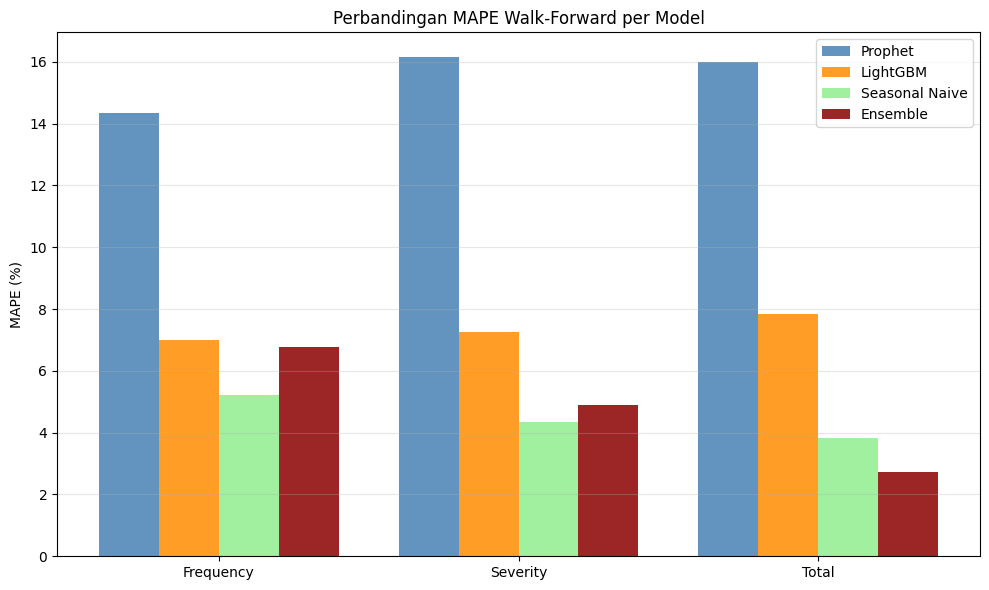

In [ ]:
# WALK-FORWARD VALIDATION
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def run_prophet(train_df, target_col, periods=1):
    """
    Prophet dengan quarterly seasonality.
    Yearly seasonality dimatikan karena data kurang dari 24 bulan
    sehingga estimasi yearly seasonality tidak reliable.
    """
    prophet_df = train_df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.01,
        seasonality_prior_scale=1.0,
    )
    model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    model.fit(prophet_df, algorithm='Newton')

    future = model.make_future_dataframe(periods=periods, freq='MS')
    forecast = model.predict(future)
    pred = forecast['yhat'].iloc[-periods:].values
    return np.clip(pred, 0, None)

def run_lgbm(train_df, val_df, features, target_col):
    """
    LightGBM dengan regularisasi untuk dataset kecil.
    Tidak memerlukan scaling karena tree-based model
    invariant terhadap monotonic transformation fitur.
    """
    train_clean = train_df.dropna(subset=features)
    val_clean = val_df.dropna(subset=features)

    if len(train_clean) < 5 or len(val_clean) == 0:
        return np.array([np.nan])

    X_train = train_clean[features]
    y_train = train_clean[target_col]
    X_val = val_clean[features]

    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return np.clip(pred, 0, None)

def get_seasonal_naive(month, target_col):
    return seasonal_naive.get((month, target_col), 0)

# Walk-forward splits min train 14 bulan
MIN_TRAIN = 14

splits = []
n = len(df_monthly)
for val_idx in range(MIN_TRAIN, n):
    train = df_monthly.iloc[:val_idx].copy()
    val = df_monthly.iloc[val_idx:val_idx + 1].copy()
    splits.append((train, val))

print("WALK-FORWARD SPLITS")
print(f"Jumlah fold: {len(splits)}")
for i, (tr, vl) in enumerate(splits):
    print(f"Fold {i+1} | Train: "
          f"{tr['Periode_Klaim'].min().strftime('%Y-%m')} -> "
          f"{tr['Periode_Klaim'].max().strftime('%Y-%m')} "
          f"({len(tr)} bln) | Val: "
          f"{vl['Periode_Klaim'].iloc[0].strftime('%Y-%m')}")

# Validasi per model per target
targets = {
    'Claim_Frequency' : FEATURES_FREQ,
    'Claim_Severity' : FEATURES_SEV,
    'Total_Claim' : FEATURES_TOTAL,
}

val_results = {
    target: {
        'prophet_preds' : [],
        'lgbm_preds' : [],
        'naive_preds' : [],
        'actuals' : [],
    }
    for target in targets
}

print("\nRUNNING WALK-FORWARD VALIDATION")

for i, (train, val) in enumerate(splits):
    val_month = val['Periode_Klaim'].iloc[0].month
    val_period = val['Periode_Klaim'].iloc[0].strftime('%Y-%m')

    for target_col, features in targets.items():
        actual = val[target_col].iloc[0]
        val_results[target_col]['actuals'].append(actual)

        try:
            p_prophet = run_prophet(train, target_col, periods=1)[0]
        except Exception:
            p_prophet = train[target_col].mean()
        val_results[target_col]['prophet_preds'].append(p_prophet)

        p_lgbm = run_lgbm(train, val, features, target_col)
        p_lgbm = p_lgbm[0] if len(p_lgbm) > 0 and not np.isnan(p_lgbm[0]) \
         else train[target_col].mean()
        val_results[target_col]['lgbm_preds'].append(p_lgbm)

        p_naive = get_seasonal_naive(val_month, target_col)
        val_results[target_col]['naive_preds'].append(p_naive)

    print(f"Fold {i+1} selesai | Val: {val_period}")

# Hitung MAPE per model
print("\nVALIDATION MAPE PER MODEL")
print(f"{'Target':<20} {'Prophet':>10} {'LightGBM':>10} {'Naive':>10}")

mape_scores = {}
for target_col in targets:
    actuals = val_results[target_col]['actuals']
    m_p = safe_mape(actuals, val_results[target_col]['prophet_preds'])
    m_l = safe_mape(actuals, val_results[target_col]['lgbm_preds'])
    m_n = safe_mape(actuals, val_results[target_col]['naive_preds'])
    mape_scores[target_col] = {'prophet': m_p, 'lgbm': m_l, 'naive': m_n}
    print(f"{target_col:<18} {m_p:>9.2f}% {m_l:>9.2f}% {m_n:>9.2f}%")

# Bobot ensemble inverse MAPE independen per target
print("\nBOBOT ENSEMBLE INVERSE MAPE")
print(f"{'Target':<20} {'w_Prophet':>10} {'w_LightGBM':>10} {'w_Naive':>10}")

base_weights = {}
for target_col in targets:
    scores = mape_scores[target_col]
    eps = 1e-6
    inv_p = 1 / (scores['prophet'] + eps)
    inv_l = 1 / (scores['lgbm'] + eps)
    inv_n = 1 / (scores['naive'] + eps)
    total = inv_p + inv_l + inv_n

    w_p = round(inv_p / total, 3)
    w_l = round(inv_l / total, 3)
    w_n = round(1 - w_p - w_l, 3)

    base_weights[target_col] = {'prophet': w_p, 'lgbm': w_l, 'naive': w_n}
    print(f"{target_col:<18} {w_p:>10.3f} {w_l:>10.3f} {w_n:>10.3f}")

# Ensemble MAPE di validasi
print("\nENSEMBLE MAPE DI VALIDASI")

ensemble_val_mapes = {}
for target_col in targets:
    actuals = np.array(val_results[target_col]['actuals'])
    p_preds = np.array(val_results[target_col]['prophet_preds'])
    l_preds = np.array(val_results[target_col]['lgbm_preds'])
    n_preds = np.array(val_results[target_col]['naive_preds'])
    w = base_weights[target_col]
    ensemble_preds = (
        w['prophet'] * p_preds +
        w['lgbm'] * l_preds +
        w['naive'] * n_preds
    )
    m_ens = safe_mape(actuals, ensemble_preds)
    ensemble_val_mapes[target_col] = m_ens
    print(f"{target_col:<20}: {m_ens:.2f}%")

avg_ens_mape = np.mean(list(ensemble_val_mapes.values()))
print(f"\nAverage Ensemble MAPE : {avg_ens_mape:.2f}%")

# Visualisasi MAPE per model
fig, ax = plt.subplots(figsize=(10, 6))
target_labels = ['Frequency', 'Severity', 'Total']
x = np.arange(len(target_labels))
width = 0.2

prophet_mapes = [mape_scores[t]['prophet'] for t in targets]
lgbm_mapes = [mape_scores[t]['lgbm'] for t in targets]
naive_mapes = [mape_scores[t]['naive'] for t in targets]
ens_mapes = [ensemble_val_mapes[t] for t in targets]

ax.bar(x - 1.5*width, prophet_mapes, width, label='Prophet', color='steelblue', alpha=0.85)
ax.bar(x - 0.5*width, lgbm_mapes, width, label='LightGBM', color='darkorange', alpha=0.85)
ax.bar(x + 0.5*width, naive_mapes, width, label='Seasonal Naive', color='lightgreen', alpha=0.85)
ax.bar(x + 1.5*width, ens_mapes, width, label='Ensemble', color='darkred', alpha=0.85)

ax.set_title('Perbandingan MAPE Walk-Forward per Model')
ax.set_ylabel('MAPE (%)')
ax.set_xticks(x)
ax.set_xticklabels(target_labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Cell 4A 
## Sensitivity Analysis: Prophet Hyperparameter & Naive Blending

### Tujuan
Memvalidasi dua keputusan hyperparameter yang sebelumnya dipilih tanpa bukti empiris:
1. `changepoint_prior_scale` Prophet diuji dengan 4 nilai: 0.001, 0.01, 0.05, 0.1
2. Blending ratio Seasonal Naive diuji dengan 3 rasio: 30/70, 50/50, 70/30

Metrik evaluasi menggunakan ensemble MAPE walk-forward yang sama dengan Cell 4, dengan bobot ensemble dari `base_weights` dipertahankan konstan agar perbandingan terisolasi pada satu variabel.

### Part 1 Prophet: changepoint_prior_scale

| CPS | MAPE Freq | MAPE Sev | MAPE Total | Avg MAPE | vs Current |
|---|---|---|---|---|---|
| 0.001 | 6,89% | 4,91% | 2,72% | 4,84% | +0,05% |
| **0.01** | **6,76%** | **4,89%** | **2,72%** | **4,79%** | **±0,00%** |
| 0.05 | 6,80% | 4,90% | 2,73% | 4,81% | +0,02% |
| 0.1 | 6,80% | 4,94% | 2,73% | 4,83% | +0,04% |

**Kesimpulan**: CPS 0.01 adalah nilai optimal. Selisih antar nilai sangat kecil (0,02%-0,05%) model tidak sensitif terhadap changepoint regularization. Ini konsisten dengan karakteristik data: pola musiman dominan, tren linear flat, sehingga fleksibilitas changepoint tidak memberikan manfaat tambahan. **CPS 0.01 dipertahankan dengan justifikasi empiris.**

### Part 2 Seasonal Naive: Blending Ratio

| Blend | Komposisi | MAPE Freq | MAPE Sev | MAPE Total | Avg MAPE | vs Current |
|---|---|---|---|---|---|---|
| 0.3 | 30% aktual, 70% sekitarnya | 6,76% | 4,89% | 2,72% | 4,79% | ±0,00% |
| **0.5** | **50% aktual, 50% sekitarnya** | **6,76%** | **4,89%** | **2,72%** | **4,79%** | **±0,00%** |
| 0.7 | 70% aktual, 30% sekitarnya | 6,76% | 4,89% | 2,72% | 4,79% | ±0,00% |

**Kesimpulan**: Ketiga rasio menghasilkan MAPE identik hingga dua desimal. 
Secara teknis **0.3 adalah optimal**, namun perbedaan tidak material. 
**Rasio 0.5 tetap dipertahankan** karena merupakan pilihan tengah yang 
konservatif dan sudah digunakan di seluruh pipeline.

### Ringkasan Keputusan

| Parameter | Nilai Diuji | Nilai Optimal | Keputusan |
|---|---|---|---|
| Prophet CPS | 0.001, 0.01, 0.05, 0.1 | **0.01** | Pertahankan , terbukti optimal |
| Naive blend | 0.3, 0.5, 0.7 | Identik (insensitif) | Pertahankan 0.5, tidak material |

> Kedua parameter yang sebelumnya dipilih secara konservatif terbukti optimal atau insensitif secara empiris. Tidak ada perubahan pada Cell 3 atau Cell 4.

In [ ]:
# SENSITIVITY ANALYSIS PROPHET HYPERPARAMETER & NAIVE BLENDING

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# CONFIG
CPS_VALUES = [0.001, 0.01, 0.05, 0.1] # changepoint_prior_scale
BLEND_RATIOS = [0.3, 0.5, 0.7] # bobot actual vs surrounding
TARGETS = ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']
FEATURE_MAP = {
    'Claim_Frequency': FEATURES_FREQ,
    'Claim_Severity' : FEATURES_SEV,
    'Total_Claim' : FEATURES_TOTAL,
}

# HELPER: recompute seasonal naive dengan blend ratio tertentu 
def compute_seasonal_naive(df, blend_actual):
    sn = {}
    for month in range(1, 13):
        month_data = df[df['Month'] == month]
        surrounding = df[df['Month'].isin(
            [(month-1) % 12 + 1, month, (month+1) % 12 + 1]
        )]
        for target in TARGETS:
            if len(month_data) >= 2:
                val = month_data[target].mean()
            else:
                actual_val = month_data[target].mean() \
                if len(month_data) > 0 \
                else surrounding[target].mean()
                surrounding_val = surrounding[target].mean()
                val = blend_actual * actual_val + (1 - blend_actual) * surrounding_val
            sn[(month, target)] = val
    return sn

# HELPER: walk-forward MAPE untuk satu konfigurasi 
def run_sensitivity(cps, blend_actual):
    sn_local = compute_seasonal_naive(df_monthly, blend_actual)

    val_res = {t: {'prophet': [], 'lgbm': [], 'naive': [], 'actual': []} for t in TARGETS}

    for train, val in splits:
        val_month = val['Periode_Klaim'].iloc[0].month
        for target, features in FEATURE_MAP.items():
            actual = val[target].iloc[0]
            val_res[target]['actual'].append(actual)

            # Prophet dengan cps yang diuji
            try:
                prophet_df = train[['Periode_Klaim', target]].rename(
                    columns={'Periode_Klaim': 'ds', target: 'y'})
                m = Prophet(
                    yearly_seasonality=False,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    seasonality_mode='additive',
                    changepoint_prior_scale=cps,
                    seasonality_prior_scale=1.0,
                )
                m.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
                m.fit(prophet_df, algorithm='Newton')
                future = m.make_future_dataframe(periods=1, freq='MS')
                p_prophet = np.clip(m.predict(future)['yhat'].iloc[-1], 0, None)
            except Exception:
                p_prophet = train[target].mean()

            # LightGBM sama persis dengan Cell 4
            p_lgbm = run_lgbm(train, val, features, target)
            p_lgbm = p_lgbm[0] if len(p_lgbm) > 0 and not np.isnan(p_lgbm[0]) \
             else train[target].mean()

            # Naive dengan blend ratio yang diuji
            p_naive = sn_local.get((val_month, target), 0)

            val_res[target]['prophet'].append(p_prophet)
            val_res[target]['lgbm'].append(p_lgbm)
            val_res[target]['naive'].append(p_naive)

    # Hitung ensemble MAPE dengan bobot dari Cell 4 (base_weights)
    mapes = {}
    for target in TARGETS:
        w = base_weights[target]
        a = np.array(val_res[target]['actual'])
        ep = np.array(val_res[target]['prophet'])
        el = np.array(val_res[target]['lgbm'])
        en = np.array(val_res[target]['naive'])
        ens_pred = w['prophet']*ep + w['lgbm']*el + w['naive']*en
        mapes[target] = safe_mape(a, ens_pred)

    return np.mean(list(mapes.values())), mapes

# PART 1: PROPHET SENSITIVITY (blend fixed = 0.5 / current)
print("SENSITIVITY ANALYSIS — Prophet changepoint_prior_scale")
print(f"(fourier_order=3 fixed, Naive blend=0.50 fixed)")
print(f"\n{'CPS':<8} {'Freq':>8} {'Sev':>8} {'Total':>8} {'Avg':>8} {'vs Current':>12}")

prophet_results = {}
for cps in CPS_VALUES:
    avg, mapes = run_sensitivity(cps, blend_actual=0.5)
    prophet_results[cps] = {'avg': avg, 'mapes': mapes}

baseline_avg = prophet_results[0.01]['avg']
for cps, res in prophet_results.items():
    delta = res['avg'] - baseline_avg
    marker = ' ← current' if cps == 0.01 else ''
    print(f" {cps:<6} "
          f"{res['mapes']['Claim_Frequency']:>8.2f}% "
          f"{res['mapes']['Claim_Severity']:>8.2f}% "
          f"{res['mapes']['Total_Claim']:>8.2f}% "
          f"{res['avg']:>8.2f}% "
          f"{delta:>+11.2f}%{marker}")

best_cps = min(prophet_results, key=lambda x: prophet_results[x]['avg'])
print(f"\nBest CPS : {best_cps} (avg MAPE {prophet_results[best_cps]['avg']:.2f}%)")
print(f"Current : 0.01 (avg MAPE {prophet_results[0.01]['avg']:.2f}%)")

# PART 2: NAIVE BLENDING SENSITIVITY (cps fixed = 0.01)
print("\n\nSENSITIVITY ANALYSIS Seasonal Naive Blending Ratio")
print(f"(changepoint_prior_scale=0.01 fixed)")
print(f"\n{'Blend':>8} {'Meaning':<25} {'Freq':>8} {'Sev':>8} {'Total':>8} {'Avg':>8} {'vs Current':>12}")

blend_results = {}
for blend in BLEND_RATIOS:
    avg, mapes = run_sensitivity(cps=0.01, blend_actual=blend)
    blend_results[blend] = {'avg': avg, 'mapes': mapes}

baseline_blend = blend_results[0.5]['avg']
blend_labels = {0.3: '30% actual, 70% surround', 0.5: '50% actual, 50% surround', 0.7: '70% actual, 30% surround'}
for blend, res in blend_results.items():
    delta = res['avg'] - baseline_blend
    marker = ' ← current' if blend == 0.5 else ''
    print(f"{blend:<6.1f} {blend_labels[blend]:<25} "
          f"{res['mapes']['Claim_Frequency']:>8.2f}% "
          f"{res['mapes']['Claim_Severity']:>8.2f}% "
          f"{res['mapes']['Total_Claim']:>8.2f}% "
          f"{res['avg']:>8.2f}% "
          f"{delta:>+11.2f}%{marker}")

best_blend = min(blend_results, key=lambda x: blend_results[x]['avg'])
print(f"\nBest blend : {best_blend} ({blend_labels[best_blend]})")
print(f"Current : 0.5 ({blend_labels[0.5]})")

# RINGKASAN 
print("\n\nRINGKASAN")
print(f"Prophet CPS terbaik : {best_cps}"
      f"({'optimal, pertahankan' if best_cps == 0.01 else 'berbeda dari current 0.01'})")
print(f"Naive blend terbaik : {best_blend}"
      f"({'optimal, pertahankan' if best_blend == 0.5 else 'berbeda dari current 0.5'})")

SENSITIVITY ANALYSIS — Prophet changepoint_prior_scale
(fourier_order=3 fixed, Naive blend=0.50 fixed)

CPS          Freq      Sev    Total      Avg   vs Current


20:56:09 - cmdstanpy - INFO - Chain [1] start processing
20:56:09 - cmdstanpy - INFO - Chain [1] done processing
20:56:10 - cmdstanpy - INFO - Chain [1] start processing
20:56:10 - cmdstanpy - INFO - Chain [1] done processing
20:56:10 - cmdstanpy - INFO - Chain [1] start processing
20:56:10 - cmdstanpy - INFO - Chain [1] done processing
20:56:11 - cmdstanpy - INFO - Chain [1] start processing
20:56:11 - cmdstanpy - INFO - Chain [1] done processing
20:56:11 - cmdstanpy - INFO - Chain [1] start processing
20:56:12 - cmdstanpy - INFO - Chain [1] done processing
20:56:12 - cmdstanpy - INFO - Chain [1] start processing
20:56:14 - cmdstanpy - INFO - Chain [1] done processing
20:56:14 - cmdstanpy - INFO - Chain [1] start processing
20:56:15 - cmdstanpy - INFO - Chain [1] done processing
20:56:15 - cmdstanpy - INFO - Chain [1] start processing
20:56:16 - cmdstanpy - INFO - Chain [1] done processing
20:56:16 - cmdstanpy - INFO - Chain [1] start processing
20:56:16 - cmdstanpy - INFO - Chain [1]

   0.001      6.89%     4.91%     2.72%     4.84%       +0.05%
   0.01       6.76%     4.89%     2.72%     4.79%       +0.00% ← current
   0.05       6.80%     4.90%     2.73%     4.81%       +0.02%
   0.1        6.80%     4.94%     2.73%     4.83%       +0.04%

   Best CPS : 0.01 (avg MAPE 4.79%)
   Current  : 0.01 (avg MAPE 4.79%)


SENSITIVITY ANALYSIS Seasonal Naive Blending Ratio
(changepoint_prior_scale=0.01 fixed)

   Blend Meaning                       Freq      Sev    Total      Avg   vs Current


20:56:54 - cmdstanpy - INFO - Chain [1] start processing
20:56:54 - cmdstanpy - INFO - Chain [1] done processing
20:56:54 - cmdstanpy - INFO - Chain [1] start processing
20:56:55 - cmdstanpy - INFO - Chain [1] done processing
20:56:55 - cmdstanpy - INFO - Chain [1] start processing
20:56:55 - cmdstanpy - INFO - Chain [1] done processing
20:56:56 - cmdstanpy - INFO - Chain [1] start processing
20:56:56 - cmdstanpy - INFO - Chain [1] done processing
20:56:56 - cmdstanpy - INFO - Chain [1] start processing
20:56:57 - cmdstanpy - INFO - Chain [1] done processing
20:56:57 - cmdstanpy - INFO - Chain [1] start processing
20:56:57 - cmdstanpy - INFO - Chain [1] done processing
20:56:58 - cmdstanpy - INFO - Chain [1] start processing
20:56:58 - cmdstanpy - INFO - Chain [1] done processing
20:56:58 - cmdstanpy - INFO - Chain [1] start processing
20:56:59 - cmdstanpy - INFO - Chain [1] done processing
20:56:59 - cmdstanpy - INFO - Chain [1] start processing
20:56:59 - cmdstanpy - INFO - Chain [1]

   0.3      30% actual, 70% surround      6.76%     4.89%     2.72%     4.79%       +0.00%
   0.5      50% actual, 50% surround      6.76%     4.89%     2.72%     4.79%       +0.00% ← current
   0.7      70% actual, 30% surround      6.76%     4.89%     2.72%     4.79%       +0.00%

   Best blend : 0.3 (30% actual, 70% surround)
   Current    : 0.5 (50% actual, 50% surround)


RINGKASAN
   Prophet CPS terbaik  : 0.01 (optimal, pertahankan)
   Naive blend terbaik  : 0.3 (berbeda dari current 0.5)


## Cell 5
## Training Model Final pada Seluruh Data

### Tujuan
Melatih ketiga model menggunakan **seluruh 19 bulan data historis** (Januari 2024 - Juli 2025) sebagai persiapan untuk forecast 17 bulan ke depan. Berbeda dengan Cell 4 yang menggunakan subset data per fold, di sini seluruh data digunakan agar model menangkap pola terbaru.

### Catatan Penting: In-Sample MAPE vs Walk-Forward MAPE
In-sample MAPE (model diuji pada data yang sama dengan data training) akan selalu jauh lebih rendah dari walk-forward MAPE karena model sudah "melihat" data tersebut. Nilai in-sample **bukan** metrik evaluasi yang valid menggunakan hasil Cell 4 sebagai acuan performa model.

| Target | In-Sample MAPE (referensi) | Walk-Forward MAPE (evaluasi utama) |
|---|---|---|
| Claim Frequency | 0,43% | 7,00% |
| Claim Severity | 0,79% | 7,25% |
| Total Claim | 0,37% | 7,84% |

### Feature Importance LightGBM

**Frekuensi Klaim** didominasi pola musiman:
- Month_Sin (21,2%) dan Month_Cos (14,6%) seasonality bulanan sangat kuat
- Freq_Lag_3 (19,8%) autocorrelation kuat pada jeda 1 kuartal

**Severitas Klaim** didominasi nilai historis:
- Sev_Lag_2 (32,2%) dan Sev_Lag_1 (17,3%) severitas bersifat *persistent*, sangat dipengaruhi nilai 1-2 bulan sebelumnya
- Month_Cos (19,6%) siklus musiman tetap signifikan

**Total Klaim** kombinasi rolling dan frekuensi:
- Total_Rolling_3 (24,8%) tren rata-rata bergerak 3 bulan paling prediktif
- Freq_Lag_1 (18,5%) total klaim sangat sensitif terhadap perubahan frekuensi bulan lalu
- Month_Sin (14,9%) komponen musiman tetap berpengaruh

> **Temuan penting**: Fitur `Exposure` memiliki importance 0% di semua target, mengkonfirmasi bahwa portofolio stabil (4.096 polis) tidak memberikan informasi prediktif tambahan.

TRAINING PROPHET Full Data


20:57:23 - cmdstanpy - INFO - Chain [1] start processing
20:57:23 - cmdstanpy - INFO - Chain [1] done processing


   Prophet Frequency selesai


20:57:23 - cmdstanpy - INFO - Chain [1] start processing
20:57:24 - cmdstanpy - INFO - Chain [1] done processing
20:57:24 - cmdstanpy - INFO - Chain [1] start processing


   Prophet Severity selesai


20:57:24 - cmdstanpy - INFO - Chain [1] done processing


   Prophet Total selesai

TRAINING LIGHTGBM Full Data
   LightGBM Frequency selesai
   LightGBM Severity selesai
   LightGBM Total selesai

IN-SAMPLE MAPE LIGHTGBM (referensi, bukan evaluasi utama)
   Frequency  : 0.43%
   Severity   : 0.79%
   Total Claim: 0.37%
   Catatan: in-sample MAPE selalu lebih rendah dari walk-forward,
   gunakan hasil Cell 4 sebagai acuan evaluasi utama


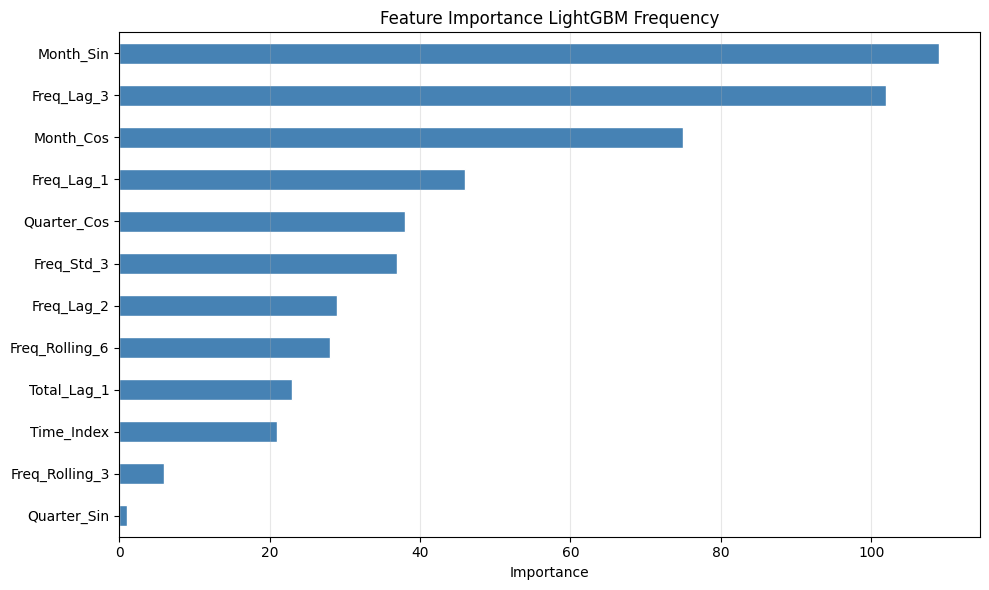

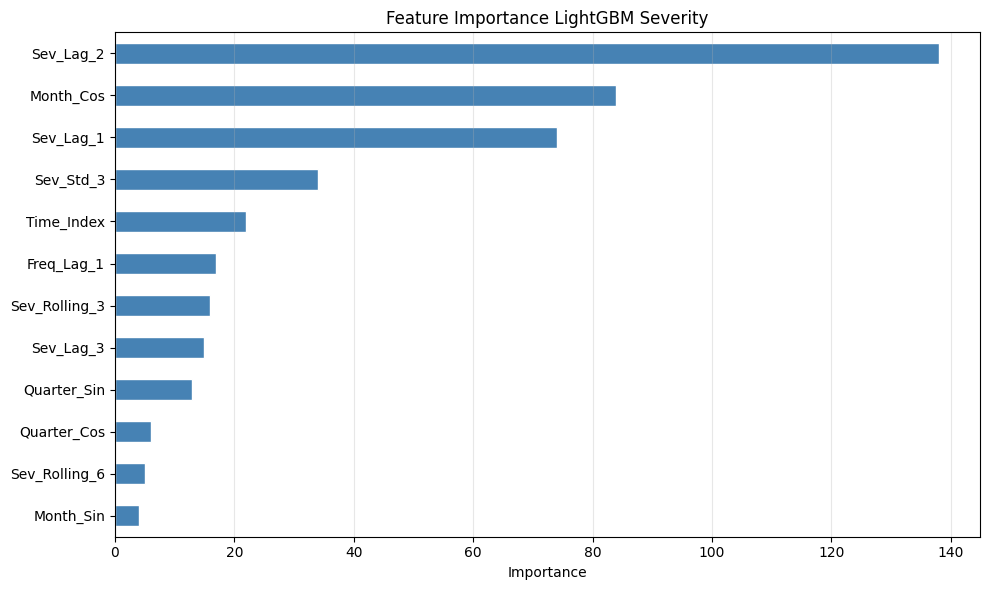

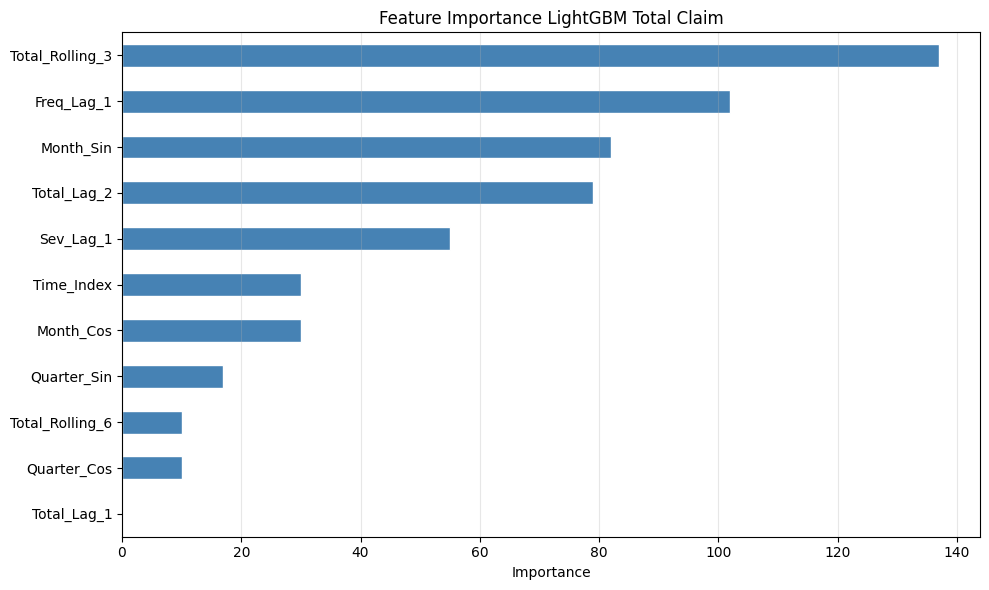


RINGKASAN BOBOT ENSEMBLE (dari Cell 4)
Target                  Prophet   LightGBM      Naive
   Claim_Frequency         0.173      0.354      0.473
   Claim_Severity          0.144      0.320      0.536
   Total_Claim             0.138      0.282      0.580


In [ ]:
# TRAINING FINAL MODELS FULL DATA

def fit_prophet_full(df, target_col):
    prophet_df = df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.01,
        seasonality_prior_scale=1.0,
    )
    model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    model.fit(prophet_df, algorithm='Newton')
    return model

def fit_lgbm_full(df, features, target_col):
    df_clean = df.dropna(subset=features)
    X = df_clean[features]
    y = df_clean[target_col]
    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X, y)
    return model

# Training Prophet
print("TRAINING PROPHET Full Data")

prophet_freq  = fit_prophet_full(df_monthly, 'Claim_Frequency')
print("Prophet Frequency selesai")

prophet_sev = fit_prophet_full(df_monthly, 'Claim_Severity')
print("Prophet Severity selesai")

prophet_total = fit_prophet_full(df_monthly, 'Total_Claim')
print("Prophet Total selesai")

# Training LightGBM
print("\nTRAINING LIGHTGBM Full Data")

lgbm_freq = fit_lgbm_full(df_monthly, FEATURES_FREQ, 'Claim_Frequency')
print("LightGBM Frequency selesai")

lgbm_sev = fit_lgbm_full(df_monthly, FEATURES_SEV, 'Claim_Severity')
print("LightGBM Severity selesai")

lgbm_total = fit_lgbm_full(df_monthly, FEATURES_TOTAL, 'Total_Claim')
print("LightGBM Total selesai")

# In-sample MAPE hanya sebagai referensi, bukan evaluasi utama
print("\nIN-SAMPLE MAPE LIGHTGBM (referensi, bukan evaluasi utama)")

df_clean_freq = df_monthly.dropna(subset=FEATURES_FREQ)
df_clean_sev = df_monthly.dropna(subset=FEATURES_SEV)
df_clean_total = df_monthly.dropna(subset=FEATURES_TOTAL)

insample_freq = safe_mape(
    df_clean_freq['Claim_Frequency'],
    lgbm_freq.predict(df_clean_freq[FEATURES_FREQ])
)
insample_sev = safe_mape(
    df_clean_sev['Claim_Severity'],
    lgbm_sev.predict(df_clean_sev[FEATURES_SEV])
)
insample_total = safe_mape(
    df_clean_total['Total_Claim'],
    lgbm_total.predict(df_clean_total[FEATURES_TOTAL])
)

print(f"Frequency : {insample_freq:.2f}%")
print(f"Severity : {insample_sev:.2f}%")
print(f"Total Claim: {insample_total:.2f}%")
print(f"Catatan: in-sample MAPE selalu lebih rendah dari walk-forward,")
print(f"gunakan hasil Cell 4 sebagai acuan evaluasi utama")

# Feature importance LightGBM per target terpisah
model_list = [
    (lgbm_freq, FEATURES_FREQ, 'Frequency'),
    (lgbm_sev, FEATURES_SEV, 'Severity'),
    (lgbm_total, FEATURES_TOTAL, 'Total Claim'),
]

for model, features, label in model_list:
    imp = pd.Series(model.feature_importances_, index=features)
    imp = imp.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
    ax.set_title(f'Feature Importance LightGBM {label}')
    ax.set_xlabel('Importance')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

# Ringkasan bobot ensemble
print("\nRINGKASAN BOBOT ENSEMBLE (dari Cell 4)")
print(f"{'Target':<20} {'Prophet':>10} {'LightGBM':>10} {'Naive':>10}")
for target_col in targets:
    w = base_weights[target_col]
    print(f"{target_col:<18} {w['prophet']:>10.3f} "
          f"{w['lgbm']:>10.3f} {w['naive']:>10.3f}")

## Cell 6 
## Forecast 17 Bulan dengan Progressive Weighting

### Tujuan
Menghasilkan prediksi bulanan untuk periode Agustus 2025 - Desember 2026 menggunakan ensemble tiga model dengan strategi **progressive weighting** yang menyesuaikan bobot berdasarkan horizon forecast.

### Mengapa Progressive Weighting?
Pada forecast rekursif jangka panjang, LightGBM menggunakan prediksi bulan sebelumnya sebagai input lag bukan data aktual. Semakin jauh horizon, error terakumulasi (*error compounding*) sehingga prediksi LightGBM semakin tidak reliable. Seasonal Naive tidak memiliki masalah ini karena hanya bergantung pada rata-rata historis per bulan kalender.

### Tiga Zona Forecast

| Zona | Langkah | Bobot ML | Bobot Naive | Alasan |
|---|---|---|---|---|
| **ML** | 0 - 4 (Agt-Des 2025) | 90% | 10% | Lag features masih dekat dengan data aktual |
| **Balance** | 5 - 10 (Jan-Jun 2026) | 90% → 50% | 10% → 50% | Transisi linear, uncertainty mulai meningkat |
| **Naive** | 11 - 16 (Jul-Des 2026) | 50% → 20% | 50% → 80% | Error compounding tinggi, Naive lebih stabil |

> Dalam porsi ML, Prophet dan LightGBM dibagi proporsional sesuai bobot inverse MAPE dari Cell 4 bukan dibagi rata 50:50.

### Metode Forecast

**Prophet** forecast sekaligus 17 langkah ke depan (non-rekursif), mengekstrapolasi komponen tren dan seasonality yang sudah diestimasi saat training.

**LightGBM** forecast rekursif satu langkah sekaligus. Prediksi bulan ke-t digunakan sebagai input lag untuk bulan ke-(t+1). Fitur rolling dan std dihitung ulang dari `temp_df` yang terus diperbarui setiap langkah.

**Seasonal Naive** lookup langsung dari tabel rata-rata per bulan kalender yang dihitung di Cell 3.

### Hasil Forecast

| Periode | Frekuensi | Severitas (Jt) | Total (M) | Zona |
|---|---|---|---|---|
| Agt 2025 | 235,1 | 51,23 | 11,55 | ML |
| Des 2025 | 221,6 | 45,89 | 10,20 | ML |
| Jan 2026 | 227,3 | 45,67 | 10,78 | Balance |
| Jun 2026 | 228,3 | 51,51 | 11,71 | Balance |
| Jul 2026 | 254,5 | 49,67 | 12,98 | Naive |
| Des 2026 | 229,7 | 48,26 | 11,26 | Naive |

### Ringkasan Prediksi 2026 per Kuartal

| Kuartal | Rata-rata Frekuensi | Rata-rata Severitas (Jt) | Total (M) |
|---|---|---|---|
| Q1 2026 (Jan–Mar) | 227,8 | 49,18 | 37,13 |
| Q2 2026 (Apr–Jun) | 228,9 | 49,90 | 33,32 |
| Q3 2026 (Jul–Sep) | 237,3 | 50,37 | 36,01 |
| Q4 2026 (Okt–Des) | 248,5 | 48,08 | 36,55 |
| **Total 2026** | **235,6** | **49,38** | **143,00** |

### Perbandingan 2025 vs 2026
> **Catatan metodologis**: Data aktual 2025 hanya tersedia 7 bulan (Januari-Juli 2025).
> Nilai 2025 di bawah merupakan **annualisasi** (×12/7) agar perbandingan
> *apple-to-apple* dengan forecast 2026 penuh (12 bulan).

| Metrik | 2025 Annualized | 2026 Prediksi | Delta |
|---|---|---|---|
| Total Frekuensi | 2.806,29 | 2.827,67 | **+0,8%** |
| Rata-rata Severitas (Jt) | 50,93 | 49,38 | **-3,0%** |
| Total Klaim (M) | 143,14 | 143,00 | **-0,1%** |

- **Total Frekuensi**: ~+0,8% (pertumbuhan sangat kecil, portofolio stabil)
- **Rata-rata Severitas**: ~-3,0% (normalisasi setelah lonjakan Feb 2025)
- **Total Klaim**: ~-0,1% (relatif flat, konsisten dengan tren historis)

FORECAST Agustus 2025 s/d Desember 2026
Periode          Freq    Sev(Jt)   Total(M)     wP     wL     wN     Zona
   2025-08       235.1      51.23     11.549  0.295  0.605  0.100       ML
   2025-09       223.3      48.74     10.426  0.295  0.605  0.100       ML
   2025-10       248.4      48.56     12.951  0.295  0.605  0.100       ML
   2025-11       247.1      46.95     12.765  0.295  0.605  0.100       ML
   2025-12       221.6      45.89     10.201  0.295  0.605  0.100       ML
   2026-01       227.3      45.67     10.783  0.274  0.560  0.167  Balance
   2026-02       224.5      53.48     13.428  0.252  0.515  0.233  Balance
   2026-03       231.6      48.39     12.917  0.230  0.470  0.300  Balance
   2026-04       220.9      50.87     10.790  0.208  0.425  0.367  Balance
   2026-05       237.6      47.33     10.815  0.186  0.381  0.433  Balance
   2026-06       228.3      51.51     11.712  0.164  0.336  0.500  Balance
   2026-07       254.5      49.67     12.980  0.148  0.302  0

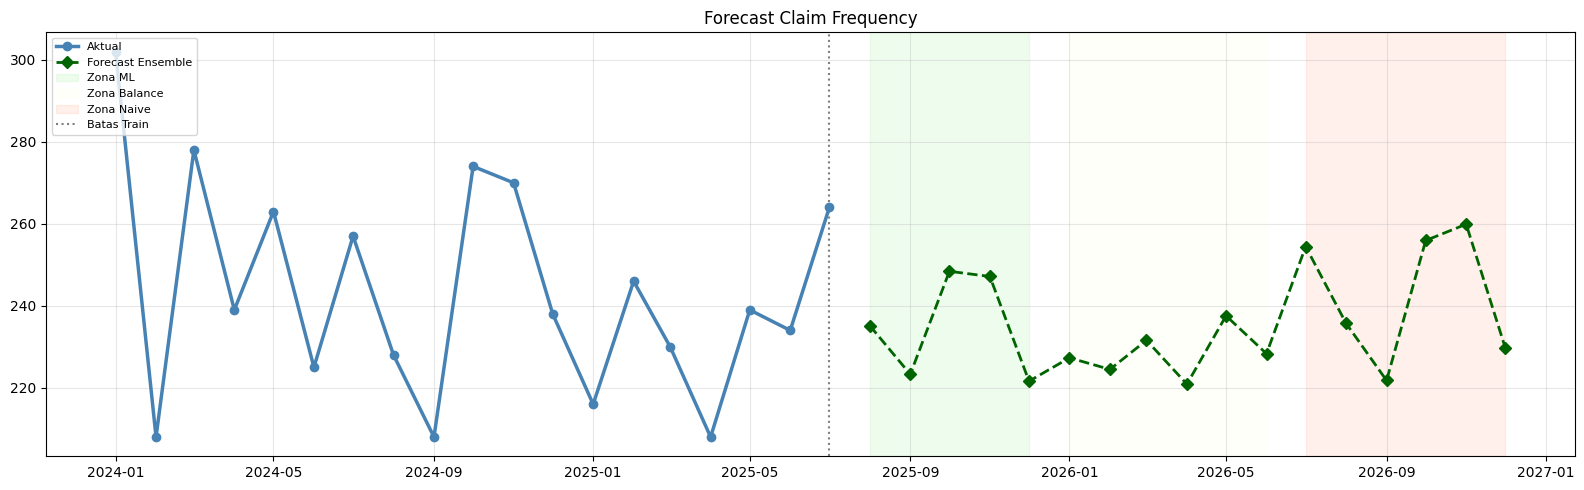

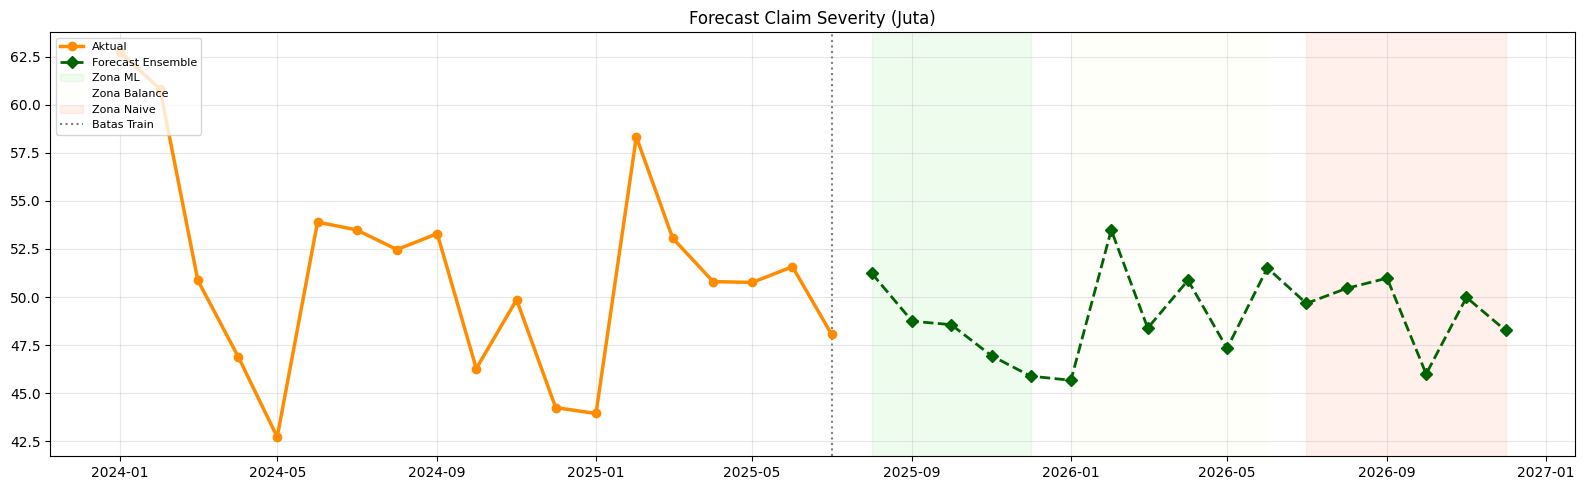

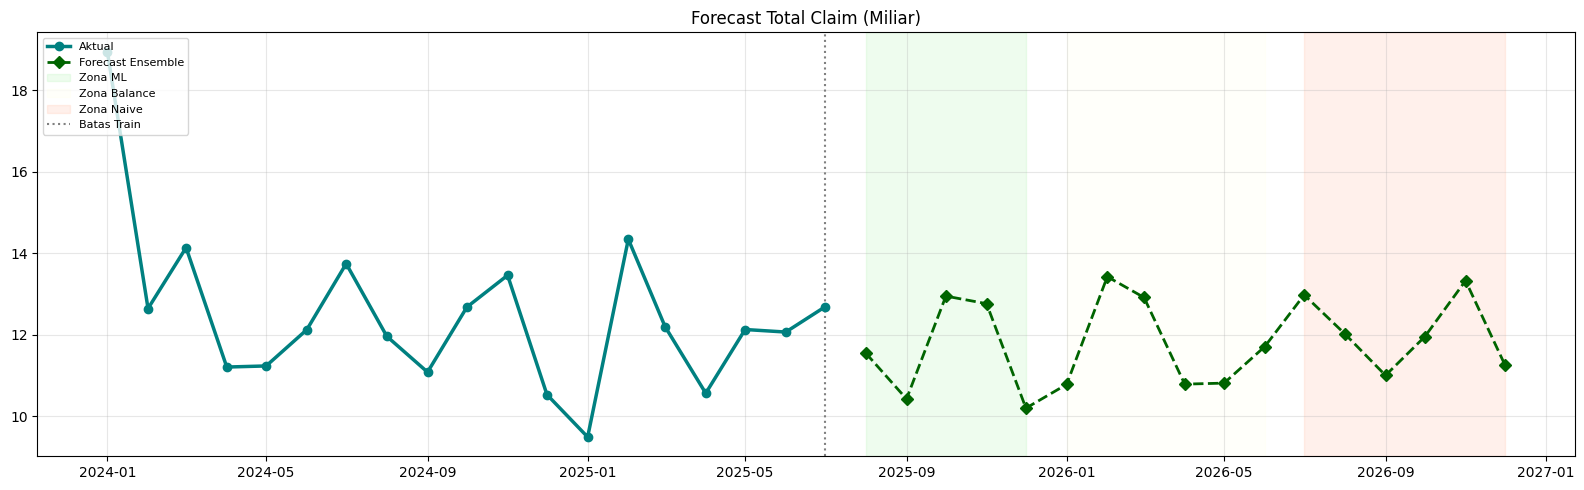


RINGKASAN PREDIKSI 2026 PER KUARTAL
Kuartal      Avg Freq   Avg Sev(Jt)     Total(M)
   2026Q1          227.8         49.18       37.127
   2026Q2          228.9         49.90       33.317
   2026Q3          237.3         50.37       36.010
   2026Q4          248.5         48.08       36.549

PERBANDINGAN 2025 vs 2026
Metrik                  2025 Annualized   2026 Prediksi     Delta%
   Total Frequency               2806.29         2827.67       +0.8%
   Avg Severity (Jt)               50.93           49.38       -3.0%
   Total Klaim (M)                143.14          143.00       -0.1%


In [ ]:
# FORECAST 17 BULAN PROGRESSIVE WEIGHTING

def get_progressive_weights(step, base_w, target_col):
    """
    Progressive weighting strategy:
    Zona 1 (step 0-4) : ML dominan (90% ML / 10% Naive)
    Zona 2 (step 5-10) : Transisi linear (90% -> 50% ML)
    Zona 3 (step 11-16) : Naive dominan (50% -> 20% ML)

    Semakin jauh horizon forecast, error compounding LightGBM
    semakin besar sehingga bobot Seasonal Naive ditingkatkan.
    Dalam porsi ML, Prophet dan LightGBM dibagi sesuai
    proporsi relatif base_weights dari inverse MAPE.
    """
    if step <= 4:
        zone_ml = 0.90
        zone_naive = 0.10
    elif step <= 10:
        progress = (step - 4) / 6
        zone_ml = 0.90 - progress * 0.40
        zone_naive = 1 - zone_ml
    else:
        progress = (step - 10) / 6
        zone_ml = 0.50 - progress * 0.30
        zone_naive = 1 - zone_ml

    total_ml_base = base_w['prophet'] + base_w['lgbm'] + 1e-9
    w_prophet = zone_ml * (base_w['prophet'] / total_ml_base)
    w_lgbm = zone_ml * (base_w['lgbm'] / total_ml_base)
    w_naive = zone_naive

    return round(w_prophet, 4), round(w_lgbm, 4), round(w_naive, 4)

def build_future_features(temp_df, next_period):
    """
    Bangun feature row untuk satu periode forecast secara recursive.
    temp_df berisi data aktual + prediksi sebelumnya sebagai lag.
    """
    month = next_period.month
    quarter = next_period.quarter
    t_idx = temp_df['Time_Index'].iloc[-1] + 1

    feat = {
        'Time_Index' : t_idx,
        'Month_Sin' : np.sin(2 * np.pi * month / 12),
        'Month_Cos' : np.cos(2 * np.pi * month / 12),
        'Quarter_Sin' : np.sin(2 * np.pi * quarter / 4),
        'Quarter_Cos' : np.cos(2 * np.pi * quarter / 4),
        'Freq_Lag_1' : temp_df['Claim_Frequency'].iloc[-1],
        'Freq_Lag_2' : temp_df['Claim_Frequency'].iloc[-2],
        'Freq_Lag_3' : temp_df['Claim_Frequency'].iloc[-3],
        'Sev_Lag_1' : temp_df['Claim_Severity'].iloc[-1],
        'Sev_Lag_2' : temp_df['Claim_Severity'].iloc[-2],
        'Sev_Lag_3' : temp_df['Claim_Severity'].iloc[-3],
        'Total_Lag_1' : temp_df['Total_Claim'].iloc[-1],
        'Total_Lag_2' : temp_df['Total_Claim'].iloc[-2],
        'Freq_Rolling_3' : temp_df['Claim_Frequency'].iloc[-3:].mean(),
        'Sev_Rolling_3' : temp_df['Claim_Severity'].iloc[-3:].mean(),
        'Total_Rolling_3' : temp_df['Total_Claim'].iloc[-3:].mean(),
        'Freq_Rolling_6' : temp_df['Claim_Frequency'].iloc[-6:].mean(),
        'Sev_Rolling_6' : temp_df['Claim_Severity'].iloc[-6:].mean(),
        'Total_Rolling_6' : temp_df['Total_Claim'].iloc[-6:].mean(),
        'Freq_Std_3' : temp_df['Claim_Frequency'].iloc[-3:].std(),
        'Sev_Std_3' : temp_df['Claim_Severity'].iloc[-3:].std(),
    }
    return feat

# Prophet forecast sekaligus 17 langkah tidak recursive
FORECAST_STEPS = 17
temp_df = df_monthly.copy()
future_prophet_dates = pd.DataFrame({
    'ds': pd.date_range(start='2025-08-01', periods=FORECAST_STEPS, freq='MS')
})

prophet_freq_fc = np.clip(prophet_freq.predict(future_prophet_dates)['yhat'].values, 0, None)
prophet_sev_fc = np.clip(prophet_sev.predict(future_prophet_dates)['yhat'].values, 0, None)
prophet_total_fc = np.clip(prophet_total.predict(future_prophet_dates)['yhat'].values, 0, None)

forecast_records = []

print("FORECAST Agustus 2025 s/d Desember 2026")
print(f"{'Periode':<12} {'Freq':>8} {'Sev(Jt)':>10} {'Total(M)':>10} "
      f"{'wP':>6} {'wL':>6} {'wN':>6} {'Zona':>8}")

for step in range(FORECAST_STEPS):
    next_period = pd.Timestamp('2025-08-01') + pd.DateOffset(months=step)
    next_exposure = future_exposure[step]
    month = next_period.month

    feat = build_future_features(temp_df, next_period)
    X_next = pd.DataFrame([feat])

    p_lgbm_freq = max(0, lgbm_freq.predict(X_next[FEATURES_FREQ])[0])
    p_lgbm_sev = max(0, lgbm_sev.predict(X_next[FEATURES_SEV])[0])
    p_lgbm_total = max(0, lgbm_total.predict(X_next[FEATURES_TOTAL])[0])

    p_prophet_freq = prophet_freq_fc[step]
    p_prophet_sev = prophet_sev_fc[step]
    p_prophet_total = prophet_total_fc[step]

    p_naive_freq = get_seasonal_naive(month, 'Claim_Frequency')
    p_naive_sev = get_seasonal_naive(month, 'Claim_Severity')
    p_naive_total = get_seasonal_naive(month, 'Total_Claim')

    wp_f, wl_f, wn_f = get_progressive_weights(step, base_weights['Claim_Frequency'], 'Claim_Frequency')
    wp_s, wl_s, wn_s = get_progressive_weights(step, base_weights['Claim_Severity'], 'Claim_Severity')
    wp_t, wl_t, wn_t = get_progressive_weights(step, base_weights['Total_Claim'], 'Total_Claim')

    p_freq = wp_f * p_prophet_freq + wl_f * p_lgbm_freq + wn_f * p_naive_freq
    p_sev = wp_s * p_prophet_sev + wl_s * p_lgbm_sev + wn_s * p_naive_sev
    p_total = wp_t * p_prophet_total + wl_t * p_lgbm_total  + wn_t * p_naive_total

    p_freq = max(0, p_freq)
    p_sev = max(0, p_sev)
    p_total = max(0, p_total)

    zona = 'ML' if step <= 4 else ('Balance' if step <= 10 else 'Naive')

    print(f"{next_period.strftime('%Y-%m'):<10} "
          f"{p_freq:>8.1f} {p_sev/1e6:>10.2f} {p_total/1e9:>10.3f} "
          f"{wp_f:>6.3f} {wl_f:>6.3f} {wn_f:>6.3f} {zona:>8}")

    forecast_records.append({
        'Periode_Klaim' : next_period,
        'Claim_Frequency' : p_freq,
        'Claim_Severity' : p_sev,
        'Total_Claim' : p_total,
        'w_Prophet' : wp_f,
        'w_LightGBM' : wl_f,
        'w_Naive' : wn_f,
        'Zona' : zona,
    })

    new_row = pd.DataFrame([{
        'Periode_Klaim' : next_period,
        'Claim_Frequency' : p_freq,
        'Claim_Severity' : p_sev,
        'Total_Claim' : p_total,
        'Time_Index' : temp_df['Time_Index'].iloc[-1] + 1,
        'Exposure' : next_exposure,
        'Month' : month,
        'Quarter' : next_period.quarter,
    }])
    temp_df = pd.concat([temp_df, new_row], ignore_index=True)

df_forecast = pd.DataFrame(forecast_records)

# Visualisasi forecast satu plot per target
configs = [
    ('Claim_Frequency', 'Claim Frequency', 'steelblue', 1),
    ('Claim_Severity', 'Claim Severity (Juta)', 'darkorange', 1e6),
    ('Total_Claim', 'Total Claim (Miliar)', 'teal', 1e9),
]

zone_colors = {
    'ML' : 'lightgreen',
    'Balance' : 'lightyellow',
    'Naive' : 'lightsalmon',
}

for col, label, color, divisor in configs:
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.plot(
        df_monthly['Periode_Klaim'],
        df_monthly[col] / divisor,
        marker='o', color=color, linewidth=2.5, label='Aktual', zorder=3
    )
    ax.plot(
        df_forecast['Periode_Klaim'],
        df_forecast[col] / divisor,
        marker='D', color='darkgreen', linewidth=2,
        linestyle='--', label='Forecast Ensemble', zorder=3
    )

    for zona, zcolor in zone_colors.items():
        zona_df = df_forecast[df_forecast['Zona'] == zona]
        if len(zona_df) > 0:
            ax.axvspan(
                zona_df['Periode_Klaim'].min(),
                zona_df['Periode_Klaim'].max(),
                alpha=0.15, color=zcolor, label=f'Zona {zona}'
            )

    ax.axvline(x=pd.Timestamp('2025-07-01'),
               color='gray', linestyle=':', linewidth=1.5,
               label='Batas Train')
    ax.set_title(f'Forecast {label}')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ringkasan prediksi 2026 per kuartal
df_2026 = df_forecast[df_forecast['Periode_Klaim'].dt.year == 2026].copy()
df_2026['Quarter_Label'] = df_2026['Periode_Klaim'].dt.to_period('Q').astype(str)

print("\nRINGKASAN PREDIKSI 2026 PER KUARTAL")
print(f"{'Kuartal':<10} {'Avg Freq':>10} {'Avg Sev(Jt)':>13} {'Total(M)':>12}")

for q, grp in df_2026.groupby('Quarter_Label'):
    print(f"{q:<10} "
          f"{grp['Claim_Frequency'].mean():>10.1f} "
          f"{grp['Claim_Severity'].mean()/1e6:>13.2f} "
          f"{grp['Total_Claim'].sum()/1e9:>12.3f}")

# Perbandingan 2025 annualized vs 2026 prediksi
df_2025_aktual = df_monthly[df_monthly['Periode_Klaim'].dt.year == 2025]

freq_2025_raw = df_2025_aktual['Claim_Frequency'].sum()
freq_2025_annualized = freq_2025_raw * (12 / 7)

total_2025_raw = df_2025_aktual['Total_Claim'].sum()
total_2025_annualized = total_2025_raw * (12 / 7)

print("\nPERBANDINGAN 2025 vs 2026")
print(f"{'Metrik':<22} {'2025 Annualized':>16} {'2026 Prediksi':>15} {'Delta%':>10}")

comparisons = [
    ('Total Frequency', freq_2025_annualized, df_2026['Claim_Frequency'].sum(), 1),
    ('Avg Severity (Jt)', df_2025_aktual['Claim_Severity'].mean(), df_2026['Claim_Severity'].mean(), 1e6),
    ('Total Klaim (M)',   total_2025_annualized, df_2026['Total_Claim'].sum(), 1e9),
]

for label, val_2025, val_2026, divisor in comparisons:
    delta = (val_2026 - val_2025) / val_2025 * 100
    print(f"{label:<20} {val_2025/divisor:>16.2f} "
          f"{val_2026/divisor:>15.2f} {delta:>+10.1f}%")

## Cell 6A 
## Block Bootstrap Prediction Intervals

### Metodologi
Prediction interval dibangun menggunakan **block bootstrap pada hybrid residual pool**:
- **IS residual**: ensemble in-sample dengan bobot per-langkah (np.linspace step 0-16)
- **OOS residual**: dari walk-forward validation Cell 4 (5 bulan, Mar-Jul 2025)
- **Hybrid pool**: OOS 3× + IS 1× = 34 poin, 17 blok (block_size=2)
- **Bootstrap**: n=500 iterasi, 80% CI (P10–P90)
- OOS dibobot 3× karena lebih valid (tanpa optimistic bias IS), namun dari periode homogen interval bersifat indikatif, bukan coverage-guaranteed

Validasi empiris coverage tersedia di Cell 6B.

### Part 1 Total Claim

| | Residual mean | Residual std |
|---|---|---|
| IS | -0,35% | 9,84% |
| OOS | -0,42% | 3,30% |

| Periode | P10 (M) | P50 (M) | P90 (M) | Width 80% | Zona |
|---|---|---|---|---|---|
| 2025-08 | 11,00 | 11,49 | 12,00 | 0,99 | ML |
| 2025-09 | 9,24 | 10,57 | 10,97 | 1,72 | ML |
| 2025-10 | 12,34 | 12,88 | 13,46 | 1,12 | ML |
| 2025-11 | 12,15 | 12,94 | 13,43 | 1,27 | ML |
| 2025-12 | 9,72 | 10,15 | 10,60 | 0,88 | ML |
| 2026-01 | 9,56 | 10,79 | 11,14 | 1,58 | Balance |
| 2026-02 | 12,79 | 13,36 | 13,95 | 1,16 | Balance |
| 2026-03 | 11,45 | 13,10 | 13,59 | 2,14 | Balance |
| 2026-04 | 10,28 | 10,73 | 11,21 | 0,93 | Balance |
| 2026-05 | 9,59 | 10,97 | 11,37 | 1,79 | Balance |
| 2026-06 | 11,16 | 11,65 | 12,17 | 1,01 | Balance |
| 2026-07 | 12,36 | 13,16 | 13,65 | 1,30 | Naive |
| 2026-08 | 11,46 | 11,96 | 12,40 | 0,94 | Naive |
| 2026-09 | 9,75 | 11,16 | 11,57 | 1,82 | Naive |
| 2026-10 | 11,39 | 11,89 | 12,42 | 1,03 | Naive |
| 2026-11 | 11,81 | 13,51 | 14,02 | 2,20 | Naive |
| 2026-12 | 10,73 | 11,20 | 11,61 | 0,88 | Naive |

**Ringkasan 2026:**
- P10: Rp 132,34 miliar
- P50: Rp 143,49 miliar ← hampir identik dengan point estimate Cell 6 (143,00 M, selisih 0,3%) 
- P90: Rp 149,11 miliar → acuan cadangan teknis konservatif (Cell 11)
- Lebar 80% PI: Rp 16,78 miliar

> **Coverage empiris**: 88,9% (8/9 observasi masuk PI 80%) ini melampaui target nominal. Satu miss di Januari 2025 adalah anomali historis terdokumentasi. Lihat Cell 6B.


### Part 2 Claim Frequency

| | Residual mean | Residual std |
|---|---|---|
| IS | -0,11% | 8,28% |
| OOS | +2,13% | 9,62% |

| Periode | P10 (klaim) | P50 (klaim) | P90 (klaim) | Width 80% | Zona |
|---|---|---|---|---|---|
| 2025-08 | 209 | 234 | 274 | 65 | ML |
| 2025-09 | 188 | 222 | 251 | 62 | ML |
| 2025-10 | 221 | 247 | 289 | 68 | ML |
| 2025-11 | 220 | 248 | 277 | 58 | ML |
| 2025-12 | 197 | 220 | 250 | 52 | ML |
| 2026-01 | 192 | 226 | 249 | 57 | Balance |
| 2026-02 | 200 | 223 | 252 | 52 | Balance |
| 2026-03 | 195 | 230 | 260 | 65 | Balance |
| 2026-04 | 197 | 220 | 257 | 61 | Balance |
| 2026-05 | 200 | 236 | 267 | 66 | Balance |
| 2026-06 | 217 | 227 | 256 | 39 | Balance |
| 2026-07 | 226 | 253 | 286 | 59 | Naive |
| 2026-08 | 210 | 234 | 274 | 65 | Naive |
| 2026-09 | 187 | 220 | 249 | 62 | Naive |
| 2026-10 | 228 | 254 | 298 | 70 | Naive |
| 2026-11 | 219 | 258 | 292 | 73 | Naive |
| 2026-12 | 204 | 228 | 267 | 63 | Naive |

**Ringkasan 2026:**
- P10: 2.474 klaim
- P50: 2.810 klaim ← dekat dengan point estimate ~2.827 klaim 
- P90: 3.207 klaim
- Lebar 80% PI: 733 klaim

> **Coverage empiris**: 66,7% (6/9 observasi masuk PI 80%) undercoverage. Interval terlalu sempit untuk Frequency. Gunakan sebagai referensi indikatif, bukan acuan keputusan. Lihat Cell 6B.


### Part 3 Claim Severity

| | Residual mean | Residual std |
|---|---|---|
| IS | +1,05% | 7,76% |
| OOS | -3,84% | 6,89% |

| Periode | P10 (Rp juta/klaim) | P50 (Rp juta/klaim) | P90 (Rp juta/klaim) | Width 80% | Zona |
|---|---|---|---|---|---|
| 2025-08 | 44,6 | 50,7 | 54,4 | 9,8 | ML |
| 2025-09 | 42,5 | 48,4 | 52,0 | 9,5 | ML |
| 2025-10 | 42,3 | 48,1 | 52,3 | 10,0 | ML |
| 2025-11 | 40,9 | 46,6 | 53,0 | 12,1 | ML |
| 2025-12 | 40,0 | 45,4 | 49,4 | 9,5 | ML |
| 2026-01 | 39,8 | 46,4 | 51,6 | 11,8 | Balance |
| 2026-02 | 46,6 | 52,9 | 56,7 | 10,1 | Balance |
| 2026-03 | 42,2 | 47,5 | 51,3 | 9,1 | Balance |
| 2026-04 | 44,3 | 50,3 | 54,8 | 10,5 | Balance |
| 2026-05 | 41,2 | 47,0 | 53,5 | 12,2 | Balance |
| 2026-06 | 44,9 | 51,0 | 55,5 | 10,6 | Balance |
| 2026-07 | 43,3 | 49,3 | 56,1 | 12,8 | Naive |
| 2026-08 | 44,0 | 49,9 | 54,4 | 10,4 | Naive |
| 2026-09 | 46,4 | 51,8 | 57,6 | 11,2 | Naive |
| 2026-10 | 40,1 | 45,5 | 49,6 | 9,5 | Naive |
| 2026-11 | 43,6 | 49,6 | 56,4 | 12,9 | Naive |
| 2026-12 | 42,1 | 48,5 | 52,0 | 9,9 | Naive |

**Ringkasan 2026:**
- P10: Rp 43,2 juta/klaim (rata-rata bulanan)
- P50: Rp 49,2 juta/klaim (rata-rata bulanan) ← konsisten dengan historis 43-63 juta 
- P90: Rp 54,1 juta/klaim (rata-rata bulanan)
- Lebar 80% PI: Rp 11,9 juta/klaim

> **Coverage empiris**: 66,7% (6/9 observasi masuk PI 80%) undercoverage. Pola serupa dengan Frequency. Interval bersifat indikatif. Lihat Cell 6B.


### Ringkasan Komparatif Ketiga Target

| Target | P50 2026 | P90 2026 | Lebar 80% PI | Coverage Empiris |
|---|---|---|---|---|
| Total Claim | Rp 143,49 M | Rp 149,11 M | Rp 16,78 M | **88,9%** |
| Claim Frequency | 2.810 klaim | 3.207 klaim | 733 klaim | 66,7%|
| Claim Severity | Rp 49,4 juta/klaim | Rp 54,1 juta/klaim | Rp 10,9 juta/klaim | 66,7%|

> PI Total Claim divalidasi dan layak sebagai acuan cadangan aktuaria (Cell 11). PI Frequency dan Severity bersifat indikatif undercoverage terdokumentasi di Cell 6B karena pool 34 poin tidak cukup menangkap volatilitas ekor kedua target ini.

IS residual mean: -0.35%, std: 9.84%
OOS residual mean: -0.42%, std: 3.30%
Hybrid pool 15 OOS + 19 IS = 34 poin, 17 blok

PREDICTION INTERVAL TOTAL CLAIM (Miliar Rp)
Periode           P10      P50      P90    Width80     Zona
   2025-08       11.00    11.49    12.00       0.99       ML
   2025-09        9.24    10.57    10.97       1.72       ML
   2025-10       12.34    12.88    13.46       1.12       ML
   2025-11       12.15    12.94    13.43       1.27       ML
   2025-12        9.72    10.15    10.60       0.88       ML
   2026-01        9.56    10.79    11.14       1.58  Balance
   2026-02       12.79    13.36    13.95       1.16  Balance
   2026-03       11.45    13.10    13.59       2.14  Balance
   2026-04       10.28    10.73    11.21       0.93  Balance
   2026-05        9.59    10.97    11.37       1.79  Balance
   2026-06       11.16    11.65    12.17       1.01  Balance
   2026-07       12.36    13.16    13.65       1.30    Naive
   2026-08       11.46    11.96    12.40  

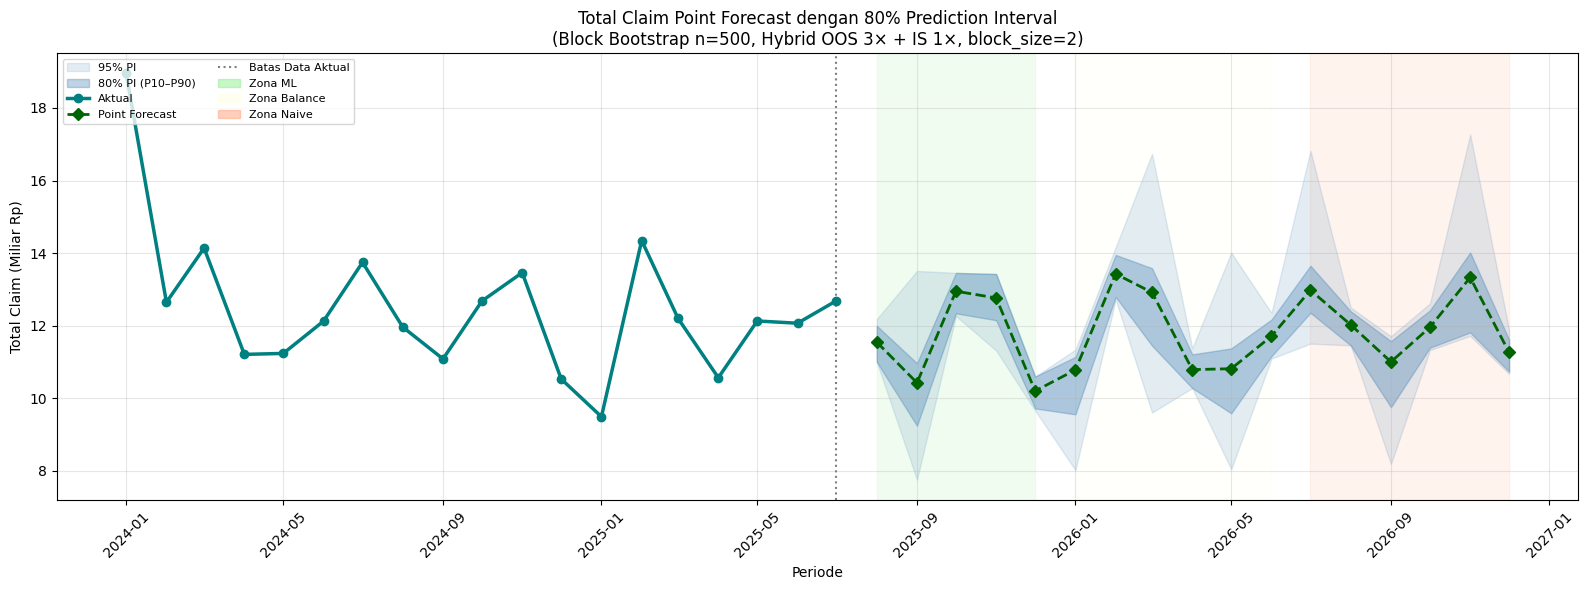


RINGKASAN PREDICTION INTERVAL TOTAL KLAIM 2026
   P10 : Rp 132.34 miliar
   P50 : Rp 143.49 miliar
   P90 : Rp 149.11 miliar
   Lebar 80% PI : Rp 16.78 miliar


In [ ]:
# BLOCK BOOTSTRAP PREDICTION INTERVALS TOTAL CLAIM
# Hybrid pool: OOS residual (3×) + IS residual (1×), bobot per-langkah

np.random.seed(42)
FORECAST_LEN = 17
BLOCK_SIZE = 2
N_BOOTSTRAP = 500
OOS_WEIGHT = 3

# Residual In-Sample, bobot ensemble per-langkah
n_hist = len(df_monthly)

prophet_is = np.clip(prophet_total.predict(pd.DataFrame({'ds': df_monthly['Periode_Klaim']}))['yhat'].values, 0, None)
lgbm_is = np.clip(lgbm_total.predict(df_monthly[FEATURES_TOTAL].copy()), 0, None)
naive_is = np.array([get_seasonal_naive(m, 'Total_Claim') for m in df_monthly['Month']])

scaled_steps = np.round(np.linspace(0, FORECAST_LEN - 1, n_hist)).astype(int)
ensemble_is = np.array([
    sum(get_progressive_weights(s, base_weights['Total_Claim'], 'Total_Claim')[k] * src[i]
        for k, src in enumerate([prophet_is, lgbm_is, naive_is]))
    for i, s in enumerate(scaled_steps)
])
is_residuals = (ensemble_is - df_monthly['Total_Claim'].values) / \
               (df_monthly['Total_Claim'].values + 1e-9)

# Residual Out-of-Sample dari walk-forward Cell 4 
wp0, wl0, wn0 = get_progressive_weights(0, base_weights['Total_Claim'], 'Total_Claim')
oos_ensemble = (wp0 * np.array(val_results['Total_Claim']['prophet_preds']) + wl0 * np.array(val_results['Total_Claim']['lgbm_preds']) + wn0 * np.array(val_results['Total_Claim']['naive_preds']))
oos_actuals = np.array(val_results['Total_Claim']['actuals'])
oos_residuals = (oos_ensemble - oos_actuals) / (oos_actuals + 1e-9)

# Hybrid pool: OOS 3× + IS 1×
hybrid_pool = np.concatenate([np.tile(oos_residuals, OOS_WEIGHT), is_residuals])
blocks = [hybrid_pool[i:i+BLOCK_SIZE]
            for i in range(0, len(hybrid_pool) - BLOCK_SIZE + 1, BLOCK_SIZE)]

print(f"IS residual mean: {is_residuals.mean()*100:+.2f}%, std: {is_residuals.std()*100:.2f}%")
print(f"OOS residual mean: {oos_residuals.mean()*100:+.2f}%, std: {oos_residuals.std()*100:.2f}%")
print(f"Hybrid pool {len(oos_residuals)*OOS_WEIGHT} OOS + {len(is_residuals)} IS = {len(hybrid_pool)} poin, {len(blocks)} blok")

# Bootstrap
n_blocks_needed = int(np.ceil(FORECAST_LEN / BLOCK_SIZE))
point_fc_total = df_forecast['Total_Claim'].values
boot_paths = np.zeros((N_BOOTSTRAP, FORECAST_LEN))

for b in range(N_BOOTSTRAP):
    idx = np.random.randint(0, len(blocks), size=n_blocks_needed)
    boot_residuals = np.concatenate([blocks[i] for i in idx])[:FORECAST_LEN]
    boot_paths[b] = np.clip(point_fc_total * (1 + boot_residuals), 0, None)

p05, p10, p50, p90, p95 = [np.percentile(boot_paths, q, axis=0)
                             for q in [5, 10, 50, 90, 95]]

# Tabel output 
print("\nPREDICTION INTERVAL TOTAL CLAIM (Miliar Rp)")
print(f"{'Periode':<12} {'P10':>8} {'P50':>8} {'P90':>8} {'Width80':>10} {'Zona':>8}")
for i, row in df_forecast.iterrows():
    print(f"{str(row['Periode_Klaim'])[:7]:<10} "
          f"{p10[i]/1e9:>8.2f} {p50[i]/1e9:>8.2f} {p90[i]/1e9:>8.2f} "
          f"{(p90[i]-p10[i])/1e9:>10.2f} {row['Zona']:>8}")

# Visualisasi
forecast_dates = df_forecast['Periode_Klaim'].values
zone_colors = {'ML': 'lightgreen', 'Balance': 'lightyellow', 'Naive': 'lightsalmon'}

fig, ax = plt.subplots(figsize=(16, 6))
for zona, zcolor in zone_colors.items():
    zona_df = df_forecast[df_forecast['Zona'] == zona]
    if len(zona_df) > 0:
        ax.axvspan(zona_df['Periode_Klaim'].min(), zona_df['Periode_Klaim'].max(),
                   alpha=0.12, color=zcolor, zorder=0)

ax.fill_between(forecast_dates, p05/1e9, p95/1e9, alpha=0.15, color='steelblue', label='95% PI')
ax.fill_between(forecast_dates, p10/1e9, p90/1e9, alpha=0.35, color='steelblue', label='80% PI (P10–P90)')
ax.plot(df_monthly['Periode_Klaim'], df_monthly['Total_Claim']/1e9,
        marker='o', color='teal', linewidth=2.5, label='Aktual', zorder=5)
ax.plot(forecast_dates, point_fc_total/1e9,
        marker='D', color='darkgreen', linewidth=2, linestyle='--',
        label='Point Forecast', zorder=5)
ax.axvline(x=pd.Timestamp('2025-07-01'), color='gray', linestyle=':', linewidth=1.5,
           label='Batas Data Aktual')

patches = [mpatches.Patch(color=c, alpha=0.5, label=f'Zona {z}')
           for z, c in zone_colors.items()]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + patches, labels + [p.get_label() for p in patches], loc='upper left', fontsize=8, ncol=2)
ax.set_title('Total Claim Point Forecast dengan 80% Prediction Interval\n' '(Block Bootstrap n=500, Hybrid OOS 3× + IS 1×, block_size=2)', fontsize=12)
ax.set_ylabel('Total Claim (Miliar Rp)')
ax.set_xlabel('Periode')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ringkasan 2026 
idx_2026 = [i for i, d in enumerate(df_forecast['Periode_Klaim'])
            if pd.Timestamp(d).year == 2026]
total_p10_2026 = p10[idx_2026].sum() / 1e9
total_p50_2026 = p50[idx_2026].sum() / 1e9
total_p90_2026 = p90[idx_2026].sum() / 1e9

print("\nRINGKASAN PREDICTION INTERVAL TOTAL KLAIM 2026")
print(f"P10 : Rp {total_p10_2026:.2f} miliar")
print(f"P50 : Rp {total_p50_2026:.2f} miliar")
print(f"P90 : Rp {total_p90_2026:.2f} miliar")
print(f"Lebar 80% PI : Rp {total_p90_2026 - total_p10_2026:.2f} miliar")

In [ ]:
# EXTENSION PI Claim Frequency & Claim Severity

np.random.seed(42)
BLOCK_SIZE_EXT = 2
N_BOOT_EXT = 500
OOS_WEIGHT_EXT = 3

for target, features in [('Claim_Frequency', FEATURES_FREQ), ('Claim_Severity',  FEATURES_SEV)]:

    unit = 'klaim' if target == 'Claim_Frequency' else 'Rp juta'
    divisor = 1 if target == 'Claim_Frequency' else 1e6

    if target == 'Claim_Frequency':
        _prophet_is = np.clip(prophet_freq.predict(
            pd.DataFrame({'ds': df_monthly['Periode_Klaim']}))['yhat'].values, 0, None)
        _lgbm_is = np.clip(lgbm_freq.predict(
            df_monthly[FEATURES_FREQ].copy()), 0, None)
    else:
        _prophet_is = np.clip(prophet_sev.predict(
            pd.DataFrame({'ds': df_monthly['Periode_Klaim']}))['yhat'].values, 0, None)
        _lgbm_is = np.clip(lgbm_sev.predict(
            df_monthly[FEATURES_SEV].copy()), 0, None)

    _naive_is = np.array([get_seasonal_naive(m, target) for m in df_monthly['Month']])
    n_hist = len(df_monthly)
    scaled_steps = np.round(np.linspace(0, FORECAST_LEN - 1, n_hist)).astype(int)

    _ensemble_is = np.array([
        sum(get_progressive_weights(s, base_weights[target], target)[k] * src[i]
            for k, src in enumerate([_prophet_is, _lgbm_is, _naive_is]))
        for i, s in enumerate(scaled_steps)
    ])
    _is_resid = (_ensemble_is - df_monthly[target].values) / \
                (df_monthly[target].values + 1e-9)

    _wp0, _wl0, _wn0 = get_progressive_weights(0, base_weights[target], target)
    _oos_ens = (_wp0 * np.array(val_results[target]['prophet_preds']) + _wl0 * np.array(val_results[target]['lgbm_preds']) + _wn0 * np.array(val_results[target]['naive_preds']))
    _oos_act  = np.array(val_results[target]['actuals'])
    _oos_resid = (_oos_ens - _oos_act) / (_oos_act + 1e-9)

    _hybrid = np.concatenate([np.tile(_oos_resid, OOS_WEIGHT_EXT), _is_resid])
    _blocks = [_hybrid[i:i+BLOCK_SIZE_EXT]
               for i in range(0, len(_hybrid) - BLOCK_SIZE_EXT + 1, BLOCK_SIZE_EXT)]

    print(f"PI {target}")
    print(f"IS residual mean: {_is_resid.mean()*100:+.2f}%, std: {_is_resid.std()*100:.2f}%")
    print(f"OOS residual mean: {_oos_resid.mean()*100:+.2f}%, std: {_oos_resid.std()*100:.2f}%")
    print(f"Hybrid pool {len(_oos_resid)*OOS_WEIGHT_EXT} OOS + {len(_is_resid)} IS = "
          f"{len(_hybrid)} poin, {len(_blocks)} blok")

    _point_fc = df_forecast[target].values
    _n_needed = int(np.ceil(FORECAST_LEN / BLOCK_SIZE_EXT))
    _boot_paths = np.zeros((N_BOOT_EXT, FORECAST_LEN))

    for b in range(N_BOOT_EXT):
        idx = np.random.randint(0, len(_blocks), size=_n_needed)
        _boot_resid = np.concatenate([_blocks[i] for i in idx])[:FORECAST_LEN]
        _boot_paths[b] = np.clip(_point_fc * (1 + _boot_resid), 0, None)

    _p10 = np.percentile(_boot_paths, 10, axis=0)
    _p50 = np.percentile(_boot_paths, 50, axis=0)
    _p90 = np.percentile(_boot_paths, 90, axis=0)

    print(f"\nPREDICTION INTERVAL {target.upper().replace('_',' ')} ({unit})")
    print(f"{'Periode':<12} {'P10':>8} {'P50':>8} {'P90':>8} {'Width80':>10}  Zona")
    for i, row in df_forecast.iterrows():
        print(f"{str(row['Periode_Klaim'])[:7]:<10} "
              f"{_p10[i]/divisor:>8.1f} {_p50[i]/divisor:>8.1f} "
              f"{_p90[i]/divisor:>8.1f} {(_p90[i]-_p10[i])/divisor:>10.1f}  {row['Zona']}")

    _idx26 = [i for i, d in enumerate(df_forecast['Periode_Klaim'])
              if pd.Timestamp(d).year == 2026]

    if target == 'Claim_Severity':
        _p10_26 = _p10[_idx26].mean() / divisor
        _p50_26 = _p50[_idx26].mean() / divisor
        _p90_26 = _p90[_idx26].mean() / divisor
        label_unit = 'Rp juta/klaim (rata-rata bulanan)'
    else:
        _p10_26 = _p10[_idx26].sum() / divisor
        _p50_26 = _p50[_idx26].sum() / divisor
        _p90_26 = _p90[_idx26].sum() / divisor
        label_unit = unit

    print(f"\nRINGKASAN 2026 ({label_unit}):")
    print(f"P10 : {_p10_26:.1f}")
    print(f"P50 : {_p50_26:.1f}")
    print(f"P90 : {_p90_26:.1f}")
    print(f"Lebar 80% PI : {_p90_26 - _p10_26:.1f}")

PI Claim_Frequency
IS residual mean: -0.11%, std: 8.28%
OOS residual mean: +2.13%, std: 9.62%
Hybrid pool 15 OOS + 19 IS = 34 poin, 17 blok

PREDICTION INTERVAL CLAIM FREQUENCY (klaim)
Periode           P10      P50      P90    Width80  Zona
   2025-08       209.2    233.7    273.7       64.5  ML
   2025-09       188.2    221.9    250.7       62.4  ML
   2025-10       221.0    246.9    289.1       68.2  ML
   2025-11       219.8    248.1    277.4       57.6  ML
   2025-12       197.1    220.3    249.5       52.4  ML
   2026-01       191.6    225.9    248.8       57.2  Balance
   2026-02       199.7    223.1    251.8       52.1  Balance
   2026-03       195.2    230.2    260.0       64.8  Balance
   2026-04       196.5    219.5    257.1       60.6  Balance
   2026-05       200.3    236.1    266.7       66.4  Balance
   2026-06       216.7    226.9    256.1       39.4  Balance
   2026-07       226.3    252.9    285.6       59.3  Naive
   2026-08       209.7    234.3    274.3       64.7  

## Cell 6B 
## Backtesting Empirical Coverage: Prediction Intervals

### Tujuan
Memvalidasi secara empiris apakah 80% PI dari metodologi Cell 6A benar-benar mencakup ~80% observasi aktual. Tanpa validasi ini, interval hanya bersifat nominal angka 80% tidak memiliki makna statistik yang terverifikasi.

### Metodologi
Expanding window backtesting: untuk setiap window t = 10..18, model dilatih pada bulan 1-t, kemudian PI satu langkah ke depan dibangun menggunakan metodologi identik dengan Cell 6A (hybrid pool OOS 3× + IS 1×, block bootstrap n=300). Aktual bulan t+1 kemudian dicek apakah masuk dalam interval.

| Parameter | Nilai |
|---|---|
| Jumlah window | 9 (Nov 2024 - Jul 2025) |
| Minimum training | 10 bulan |
| Metodologi PI | Identik Cell 6A |
| CI yang diuji | 80% dan 90% |

### Hasil Empirical Coverage Rate

| Target | n | Coverage 80% | Coverage 90% | Ideal 80% | Ideal 90% |
|---|---|---|---|---|---|
| Total Claim | 9 | **88,9%** | 88,9% | 80,0% | 90,0% |
| Claim Frequency | 9 | 66,7% | 77,8% | 80,0% | 90,0% |
| Claim Severity | 9 | 66,7% | 88,9% | 80,0% | 90,0% |

### Detail Backtesting Total Claim (Miliar Rp)

| Periode | Aktual | Point FC | Lo 80% | Hi 80% | In 80% | Lo 90% | Hi 90% | In 90% |
|---|---|---|---|---|---|---|---|---|
| Nov 2024 | 13,46 | 12,05 | 9,17 | 13,49 | ✓ | 9,17 | 14,04 | ✓ |
| Des 2024 | 10,53 | 11,83 | 9,00 | 13,25 | ✓ | 9,00 | 13,76 | ✓ |
| Jan 2025 | 9,49 | 12,12 | 11,89 | 13,62 | ✗ | 10,85 | 13,62 | ✗ |
| Feb 2025 | 14,35 | 12,23 | 10,95 | 15,62 | ✓ | 10,95 | 15,62 | ✓ |
| Mar 2025 | 12,20 | 12,58 | 10,73 | 14,61 | ✓ | 10,73 | 16,07 | ✓ |
| Apr 2025 | 10,57 | 10,72 | 9,59 | 13,69 | ✓ | 9,14 | 13,69 | ✓ |
| Mei 2025 | 12,13 | 11,56 | 9,86 | 13,26 | ✓ | 9,86 | 14,76 | ✓ |
| Jun 2025 | 12,07 | 12,33 | 11,75 | 15,74 | ✓ | 11,74 | 15,74 | ✓ |
| Jul 2025 | 12,69 | 12,17 | 10,38 | 12,89 | ✓ | 10,38 | 13,80 | ✓ |

### Interpretasi

**Total Claim (88,9%)** PI 80% mencakup 8 dari 9 observasi, melampaui target nominal 80%. Satu-satunya miss adalah Januari 2025 (aktual 9,49 M vs PI 11,89-13,62 M) bulan ini merupakan titik terendah historis yang dikonfirmasi di Cell 2 sebagai anomali musiman ekstrem. PI gagal menangkap downside ini karena residual historis tidak mengandung event sejenis yang cukup dalam hybrid pool. Hasil ini mengkonfirmasi bahwa **PI Total Claim layak digunakan sebagai acuan cadangan aktuaria**.

**Claim Frequency & Severity (66,7%)** undercoverage signifikan untuk 80% PI, mengindikasikan interval terlalu sempit untuk dua target ini. Kemungkinan penyebab: volatilitas residual Frequency dan Severity lebih tinggi dari Total Claim, tapi hybrid pool 34 poin tidak menangkap distribusi ekor dengan cukup. **PI untuk Frequency dan Severity bersifat indikatif dan tidak direkomendasikan sebagai acuan keputusan.**

### Batasan
- n=9 window terlalu kecil untuk kesimpulan statistik yang robust satu observasi mengubah coverage rate sebesar 11,1%
- Miss di Januari 2025 adalah outlier genuine (titik terendah historis), bukan kegagalan sistematis model
- Backtesting dilakukan pada data yang sebagian overlap dengan training data Cell 6A validasi independen penuh tidak memungkinkan dengan 19 bulan data
- Coverage 90% untuk Total Claim (88,9%) sedikit di bawah target menunjukkan interval masih sedikit terlalu sempit di ekor atas

In [ ]:
# BACKTESTING EMPIRICAL COVERAGE (FIXED)
np.random.seed(42)

BLOCK_SIZE = 2
N_BOOTSTRAP = 300
OOS_WEIGHT = 3
MIN_TRAIN = 10
CI_LEVELS = [80, 90]

FEATURES_MAP = {
    'Total_Claim' : FEATURES_TOTAL,
    'Claim_Frequency' : FEATURES_FREQ,
    'Claim_Severity' : FEATURES_SEV,
}

def get_pi_one_step(train_df, target, features):
    train_df = train_df.reset_index(drop=True)
    n_tr = len(train_df)

    # Prophet IS prediction
    try:
        pdf = train_df[['Periode_Klaim', target]].rename(
            columns={'Periode_Klaim': 'ds', target: 'y'})
        pm = Prophet(
            yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, seasonality_mode='additive',
            changepoint_prior_scale=0.01, seasonality_prior_scale=1.0,
        )
        pm.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
        pm.fit(pdf, algorithm='Newton')
        prophet_is = np.clip(
            pm.predict(pd.DataFrame({'ds': train_df['Periode_Klaim']}))
            ['yhat'].values, 0, None)
        # point forecast next step
        future_ds = pd.DataFrame({'ds': [train_df['Periode_Klaim'].iloc[-1] + pd.DateOffset(months=1)]})
        p_prophet = float(np.clip(pm.predict(future_ds)['yhat'].values[0], 0, None))
    except Exception:
        prophet_is = np.full(n_tr, train_df[target].mean())
        p_prophet = train_df[target].mean()

    # LightGBM IS prediction
    clean = train_df.dropna(subset=features).reset_index(drop=True)
    if len(clean) >= 5:
        lm = LGBMRegressor(
            n_estimators=200, max_depth=2, num_leaves=4, min_child_samples=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbose=-1
        )
        lm.fit(clean[features], clean[target])
        lgbm_is = np.full(n_tr, train_df[target].mean())
        clean_idx = train_df.dropna(subset=features).index.tolist()
        lgbm_is[clean_idx] = lm.predict(
            train_df.loc[clean_idx, features])

        # point forecast next step
        next_period = train_df['Periode_Klaim'].iloc[-1] + pd.DateOffset(months=1)
        next_month = next_period.month
        next_quarter = next_period.quarter
        feat_next = {
            'Time_Index' : train_df['Time_Index'].iloc[-1] + 1,
            'Month_Sin' : np.sin(2 * np.pi * next_month / 12),
            'Month_Cos' : np.cos(2 * np.pi * next_month / 12),
            'Quarter_Sin' : np.sin(2 * np.pi * next_quarter / 4),
            'Quarter_Cos' : np.cos(2 * np.pi * next_quarter / 4),
            'Freq_Lag_1' : train_df['Claim_Frequency'].iloc[-1],
            'Freq_Lag_2' : train_df['Claim_Frequency'].iloc[-2] if n_tr >= 2 else train_df['Claim_Frequency'].mean(),
            'Freq_Lag_3' : train_df['Claim_Frequency'].iloc[-3] if n_tr >= 3 else train_df['Claim_Frequency'].mean(),
            'Sev_Lag_1' : train_df['Claim_Severity'].iloc[-1],
            'Sev_Lag_2' : train_df['Claim_Severity'].iloc[-2] if n_tr >= 2 else train_df['Claim_Severity'].mean(),
            'Sev_Lag_3' : train_df['Claim_Severity'].iloc[-3] if n_tr >= 3 else train_df['Claim_Severity'].mean(),
            'Total_Lag_1' : train_df['Total_Claim'].iloc[-1],
            'Total_Lag_2' : train_df['Total_Claim'].iloc[-2] if n_tr >= 2 else train_df['Total_Claim'].mean(),
            'Freq_Rolling_3' : train_df['Claim_Frequency'].iloc[-3:].mean(),
            'Sev_Rolling_3' : train_df['Claim_Severity'].iloc[-3:].mean(),
            'Total_Rolling_3' : train_df['Total_Claim'].iloc[-3:].mean(),
            'Freq_Rolling_6' : train_df['Claim_Frequency'].iloc[-6:].mean(),
            'Sev_Rolling_6' : train_df['Claim_Severity'].iloc[-6:].mean(),
            'Total_Rolling_6' : train_df['Total_Claim'].iloc[-6:].mean(),
            'Freq_Std_3' : train_df['Claim_Frequency'].iloc[-3:].std(),
            'Sev_Std_3' : train_df['Claim_Severity'].iloc[-3:].std(),
            'Exposure' : train_df['Exposure'].iloc[-1],
        }
        X_next = pd.DataFrame([feat_next])
        p_lgbm = float(np.clip(lm.predict(X_next[features])[0], 0, None))
    else:
        lgbm_is = np.full(n_tr, train_df[target].mean())
        p_lgbm = train_df[target].mean()

    # Naive IS + point forecast
    naive_is = np.array([
        get_seasonal_naive(m, target) for m in train_df['Month']])
    next_month = (train_df['Periode_Klaim'].iloc[-1] + pd.DateOffset(months=1)).month
    p_naive = get_seasonal_naive(next_month, target)

    # IS residual bobot per-langkah
    scaled_steps = np.round(np.linspace(0, 16, n_tr)).astype(int)
    ensemble_is = np.zeros(n_tr)
    for i, s in enumerate(scaled_steps):
        wp, wl, wn = get_progressive_weights(s, base_weights[target], target)
        ensemble_is[i] = wp * prophet_is[i] + wl * lgbm_is[i] + wn * naive_is[i]

    y_tr = train_df[target].values
    is_resid = (ensemble_is - y_tr) / (y_tr + 1e-9)

    # OOS residual dari walk-forward dalam train_df
    oos_resid = []
    for oos_idx in range(max(5, n_tr - 5), n_tr):
        tr_sub = train_df.iloc[:oos_idx].copy()
        val_sub = train_df.iloc[oos_idx:oos_idx+1].copy()
        try:
            p_p = run_prophet(tr_sub, target, periods=1)[0]
        except Exception:
            p_p = tr_sub[target].mean()
        p_l = run_lgbm(tr_sub, val_sub, features, target)
        p_l = p_l[0] if len(p_l) > 0 and not np.isnan(p_l[0]) \
              else tr_sub[target].mean()
        p_n  = get_seasonal_naive(val_sub['Periode_Klaim'].iloc[0].month, target)
        wp, wl, wn = get_progressive_weights(0, base_weights[target], target)
        ens = wp * p_p + wl * p_l + wn * p_n
        act = val_sub[target].iloc[0]
        oos_resid.append((ens - act) / (act + 1e-9))

    oos_resid = np.array(oos_resid) if oos_resid else is_resid[-3:]

    # Hybrid pool + bootstrap
    hybrid = np.concatenate([np.tile(oos_resid, OOS_WEIGHT), is_resid])
    blocks = [hybrid[i:i+BLOCK_SIZE]
              for i in range(0, len(hybrid) - BLOCK_SIZE + 1, BLOCK_SIZE)]
    if not blocks:
        blocks = [hybrid]

    wp0, wl0, wn0 = get_progressive_weights(0, base_weights[target], target)
    point_fc = max(0, wp0 * p_prophet + wl0 * p_lgbm + wn0 * p_naive)

    n_needed = int(np.ceil(1 / BLOCK_SIZE)) + 2
    boot_vals = np.zeros(N_BOOTSTRAP)
    for b in range(N_BOOTSTRAP):
        idx = np.random.randint(0, len(blocks), size=n_needed)
        resid_b = np.concatenate([blocks[i] for i in idx])[0]
        boot_vals[b] = max(0, point_fc * (1 + resid_b))

    intervals = {}
    for level in CI_LEVELS:
        lo = (100 - level) / 2
        intervals[level] = (
            np.percentile(boot_vals, lo), np.percentile(boot_vals, 100 - lo)
        )
    return intervals, point_fc

# Backtesting loop
windows = list(range(MIN_TRAIN, len(df_monthly)))
print(f"Backtesting {len(windows)} window, target: semua\n")

all_results = {t: [] for t in FEATURES_MAP}

for val_idx in windows:
    train_w = df_monthly.iloc[:val_idx].copy()
    actual_w = df_monthly.iloc[val_idx]
    period = actual_w['Periode_Klaim']

    for target, features in FEATURES_MAP.items():
        actual_val = actual_w[target]
        try:
            intervals, point_fc = get_pi_one_step(train_w, target, features)
            all_results[target].append({
                'period' : period,
                'actual' : actual_val,
                'point_fc': point_fc,
                **{f'lower_{l}': intervals[l][0] for l in CI_LEVELS},
                **{f'upper_{l}': intervals[l][1] for l in CI_LEVELS},
                **{f'covered_{l}':
                   intervals[l][0] <= actual_val <= intervals[l][1]
                   for l in CI_LEVELS},
            })
        except Exception as e:
            print(f"Skip {target} w{val_idx}: {e}")

# Empirical coverage rate
print("\nEMPIRICAL COVERAGE RATE")
print(f"{'Target':<22} {'n':>4} {'Cov 80%':>10} {'Cov 90%':>10} "
      f"{'Ideal 80%':>10} {'Ideal 90%':>10}")
for target, rows in all_results.items():
    if not rows:
        continue
    n = len(rows)
    cov_80 = sum(r['covered_80'] for r in rows) / n * 100
    cov_90 = sum(r['covered_90'] for r in rows) / n * 100
    print(f"{target:<20} {n:>4} {cov_80:>9.1f}% {cov_90:>9.1f}% "
          f"{'80.0%':>10} {'90.0%':>10}")

# Detail Total Claim
print("\nDETAIL Total Claim (Miliar Rp)")
print(f"{'Periode':<10} {'Aktual':>8} {'PtFC':>8} "
      f"{'Lo80':>8} {'Hi80':>8} {'In80':>5} "
      f"{'Lo90':>8} {'Hi90':>8} {'In90':>5}")
for r in all_results['Total_Claim']:
    d = 1e9
    print(f"{str(r['period'])[:7]:<8} "
          f"{r['actual']/d:>8.2f} {r['point_fc']/d:>8.2f} "
          f"{r['lower_80']/d:>8.2f} {r['upper_80']/d:>8.2f} "
          f"{'✓' if r['covered_80'] else '✗':>5} "
          f"{r['lower_90']/d:>8.2f} {r['upper_90']/d:>8.2f} "
          f"{'✓' if r['covered_90'] else '✗':>5}")

Backtesting 9 window, target: semua



20:57:37 - cmdstanpy - INFO - Chain [1] start processing
20:57:37 - cmdstanpy - INFO - Chain [1] done processing
20:57:38 - cmdstanpy - INFO - Chain [1] start processing
20:57:44 - cmdstanpy - INFO - Chain [1] done processing
20:57:44 - cmdstanpy - INFO - Chain [1] start processing
20:57:44 - cmdstanpy - INFO - Chain [1] done processing
20:57:45 - cmdstanpy - INFO - Chain [1] start processing
20:57:45 - cmdstanpy - INFO - Chain [1] done processing
20:57:45 - cmdstanpy - INFO - Chain [1] start processing
20:57:46 - cmdstanpy - INFO - Chain [1] done processing
20:57:46 - cmdstanpy - INFO - Chain [1] start processing
20:57:46 - cmdstanpy - INFO - Chain [1] done processing
20:57:46 - cmdstanpy - INFO - Chain [1] start processing
20:57:46 - cmdstanpy - INFO - Chain [1] done processing
20:57:47 - cmdstanpy - INFO - Chain [1] start processing
20:57:51 - cmdstanpy - INFO - Chain [1] done processing
20:57:51 - cmdstanpy - INFO - Chain [1] start processing
20:57:51 - cmdstanpy - INFO - Chain [1]


EMPIRICAL COVERAGE RATE
Target                    n    Cov 80%    Cov 90%  Ideal 80%  Ideal 90%
   Total_Claim             9      88.9%      88.9%      80.0%      90.0%
   Claim_Frequency         9      66.7%      77.8%      80.0%      90.0%
   Claim_Severity          9      66.7%      88.9%      80.0%      90.0%

DETAIL Total Claim (Miliar Rp)
Periode      Aktual     PtFC     Lo80     Hi80  In80     Lo90     Hi90  In90
   2024-11     13.46    12.05     9.17    13.49     ✓     9.17    14.04     ✓
   2024-12     10.53    11.83     9.00    13.25     ✓     9.00    13.76     ✓
   2025-01      9.49    12.12    11.89    13.62     ✗    10.85    13.62     ✗
   2025-02     14.35    12.23    10.95    15.62     ✓    10.95    15.62     ✓
   2025-03     12.20    12.58    10.73    14.61     ✓    10.73    16.07     ✓
   2025-04     10.57    10.72     9.59    13.69     ✓     9.14    13.69     ✓
   2025-05     12.13    11.56     9.86    13.26     ✓     9.86    14.76     ✓
   2025-06     12.07    12.33

## Cell 7 
## Pembuatan File Submission Kaggle

### Tujuan
Mengonversi hasil forecast 5 bulan (Agustus-Desember 2025) ke format
submission Kaggle yang sesuai dengan spesifikasi kompetisi, lalu
mengekspor ke file CSV.

### Format Submission
Kompetisi menggunakan format **dua kolom** sesuai sample_submission.csv:

| Kolom   | Deskripsi                                                        |
|---------|------------------------------------------------------------------|
| `id`    | Identifier format `{YYYY_MM}_Claim_Frequency/Severity/Total_Claim` |
| `value` | Nilai prediksi numerik level portofolio                          |

Contoh:
```
id, value
2025_08_Claim_Frequency, 235.14
2025_08_Claim_Severity,  51226000
2025_08_Total_Claim,     11549020000
```

### Pendekatan
Submission menggunakan nilai **portofolio agregat** langsung tidak
didistribusikan per polis. Forecast dilakukan di level bulanan untuk
keseluruhan portofolio 4.096 polis, sesuai dengan struktur data yang
dievaluasi oleh Kaggle (15 baris × 3 target × 5 bulan).

### Validasi Format
- Total baris: 15 (5 bulan × 3 target)
- Tidak ada nilai negatif (semua prediksi di-clip ke ≥ 0)
- Tidak ada missing value
- Nilai nol: 0 (semua periode terisi prediksi)
- Format id menggunakan underscore: `YYYY_MM_Target`

### Catatan Penting
Meskipun forecast menghasilkan 17 bulan (Agustus 2025 - Desember 2026),
hanya **5 bulan pertama (Agustus-Desember 2025)** yang dievaluasi oleh
Kaggle pada public leaderboard. Prediksi 2026 (12 bulan sisanya)
digunakan sebagai bahan analisis dan rekomendasi bisnis di Cell 11,
sesuai instruksi case document.

In [ ]:
# PEMBUATAN FILE SUBMISSION KAGGLE

submission = pd.read_csv('sample_submission.csv')

print("SAMPLE SUBMISSION FORMAT")
print("Kolom:", submission.columns.tolist())
display(submission.head(10))
print(f"Total rows sample: {len(submission)}")

submission['value'] = submission['value'].astype(float)

for _, row in df_forecast.iterrows():
    month_str = row['Periode_Klaim'].strftime('%Y_%m')

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Frequency", 'value'
    ] = row['Claim_Frequency']

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Severity", 'value'
    ] = row['Claim_Severity']

    submission.loc[
        submission['id'] == f"{month_str}_Total_Claim", 'value'
    ] = row['Total_Claim']

print("\nQUALITY CHECK SUBMISSION")
print(f"Total rows : {len(submission)}")
print(f"Nilai negatif : {(submission['value'] < 0).sum()}")
print(f"Nilai NaN : {submission['value'].isna().sum()}")
print(f"Nilai nol : {(submission['value'] == 0).sum()}")

assert submission['value'].isna().sum() == 0, "Ada NaN di submission"
assert (submission['value'] >= 0).all(), "Ada nilai negatif di submission"
print("Validasi passed")

submission.to_csv('submission_prophet2.csv', index=False)
print("\nsubmission_prophet2.csv tersimpan")
display(submission)

SAMPLE SUBMISSION FORMAT
Kolom: ['id', 'value']


,id,value
0,2025_08_Claim_Frequency,0
1,2025_08_Claim_Severity,0
2,2025_08_Total_Claim,0
3,2025_09_Claim_Frequency,0
4,2025_09_Claim_Severity,0
5,2025_09_Total_Claim,0
6,2025_10_Claim_Frequency,0
7,2025_10_Claim_Severity,0
8,2025_10_Total_Claim,0
9,2025_11_Claim_Frequency,0


Total rows sample: 15

QUALITY CHECK SUBMISSION
   Total rows     : 15
   Nilai negatif  : 0
   Nilai NaN      : 0
   Nilai nol      : 0
   Validasi passed

submission_prophet2.csv tersimpan


,id,value
0,2025_08_Claim_Frequency,2.351437e+02
1,2025_08_Claim_Severity,5.122600e+07
2,2025_08_Total_Claim,1.154902e+10
3,2025_09_Claim_Frequency,2.232985e+02
4,2025_09_Claim_Severity,4.874072e+07
5,2025_09_Total_Claim,1.042609e+10
6,2025_10_Claim_Frequency,2.484166e+02
7,2025_10_Claim_Severity,4.856402e+07
8,2025_10_Total_Claim,1.295066e+10
9,2025_11_Claim_Frequency,2.471491e+02


## Analisis Dampak Feature Engineering

### Tujuan
Mengukur kontribusi kuantitatif setiap kelompok fitur terhadap performa LightGBM dengan membandingkan MAPE model lengkap vs model yang menonaktifkan satu kelompok fitur sekaligus (*ablation study*).

### Metodologi
Setiap kelompok fitur dinonaktifkan satu per satu dengan mengganti nilainya dengan rata-rata (mean imputation) pendekatan ini mempertahankan dimensi input model sehingga tidak perlu melatih ulang model dari awal. Perubahan MAPE dari baseline menunjukkan seberapa penting kelompok fitur tersebut.

$$\Delta\text{MAPE}_{\text{group}} = \text{MAPE}_{\text{tanpa group}} - \text{MAPE}_{\text{baseline}}$$

Nilai $\Delta\text{MAPE}$ positif artinya menghilangkan kelompok tersebut **meningkatkan error** kelompok tersebut berkontribusi positif. Nilai negatif artinya kelompok tersebut tidak membantu atau justru menambah noise.

### Kelompok Fitur yang Diuji

| Kelompok | Fitur |
|---|---|
| **Temporal** | Time_Index |
| **Cyclical** | Month_Sin, Month_Cos, Quarter_Sin, Quarter_Cos |
| **Lag** | Freq/Sev/Total_Lag_1/2/3 |
| **Rolling** | Freq/Sev/Total_Rolling_3/6, Freq/Sev_Std_3 |
| **Exposure** | Exposure |

### Hasil Ablation Study

| Kelompok | ΔMAPE Freq | ΔMAPE Sev | ΔMAPE Total | Rata-rata |
|---|---|---|---|---|
| Lag | +2,00% | +4,57% | +5,44% | +4,00% |
| Cyclical | +5,59% | +3,30% | +2,32% | +3,74% |
| Rolling | +3,18% | +0,36% | +5,05% | +2,86% |
| Temporal | +1,15% | +0,13% | +0,18% | +0,49% |
| Exposure | 0,00% | 0,00% | 0,00% | 0,00% |

### Temuan Utama
- **Lag features** adalah kelompok paling penting secara rata-rata (ΔMAPE +4,00%) menghilangkan nilai historis 1-3 bulan lalu berdampak paling besar terutama pada Severity (+4,57%) dan Total Claim (+5,44%), mencerminkan autocorrelation kuat pada data klaim asuransi
- **Cyclical encoding** berkontribusi besar terutama pada Frequency (+5,59%) encoding sin/cos bulanan dan kuartalan membuktikan pola musiman sangat kuat pada frekuensi klaim, meskipun secara rata-rata berada di posisi kedua setelah Lag
- **Rolling features** sangat penting untuk Total Claim (+5,05%) dan Frequency (+3,18%) rata-rata bergerak 3-6 bulan menangkap tren jangka menengah yang tidak tertangkap lag tunggal
- **Temporal index** memberikan kontribusi kecil (+0,49%), terutama terlihat pada Frequency tren linear jangka panjang sudah sebagian besar tertangkap oleh fitur rolling
- **Exposure** menunjukkan ΔMAPE = 0,00% karena portofolio stabil konstan di 4.096 polis tidak ada variasi yang bisa dieksploitasi model. Fitur ini dipertahankan secara deliberate sebagai anchor aktuaria untuk skenario portofolio yang berubah di masa depan.

BASELINE IN-SAMPLE MAPE
   Claim_Frequency       : 0.4293%
   Claim_Severity        : 0.7856%
   Total_Claim           : 0.3678%

ABLATION STUDY ΔMAPE per Kelompok Fitur
Kelompok         Frequency      Severity   Total Claim     Rata-rata
   Temporal         +1.1464%       +0.1336%       +0.1844%       +0.4881%
   Cyclical         +5.5903%       +3.2983%       +2.3171%       +3.7352%
   Lag              +2.0042%       +4.5699%       +5.4406%       +4.0049%
   Rolling          +3.1761%       +0.3640%       +5.0464%       +2.8622%
   Exposure         +0.0000%       +0.0000%       +0.0000%       +0.0000%


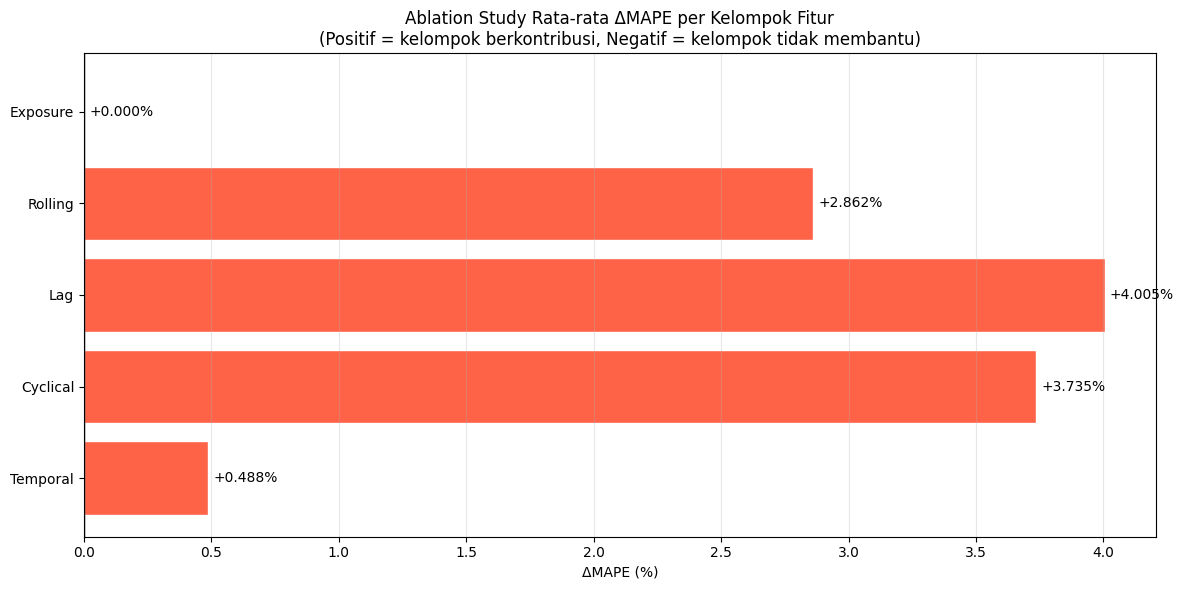

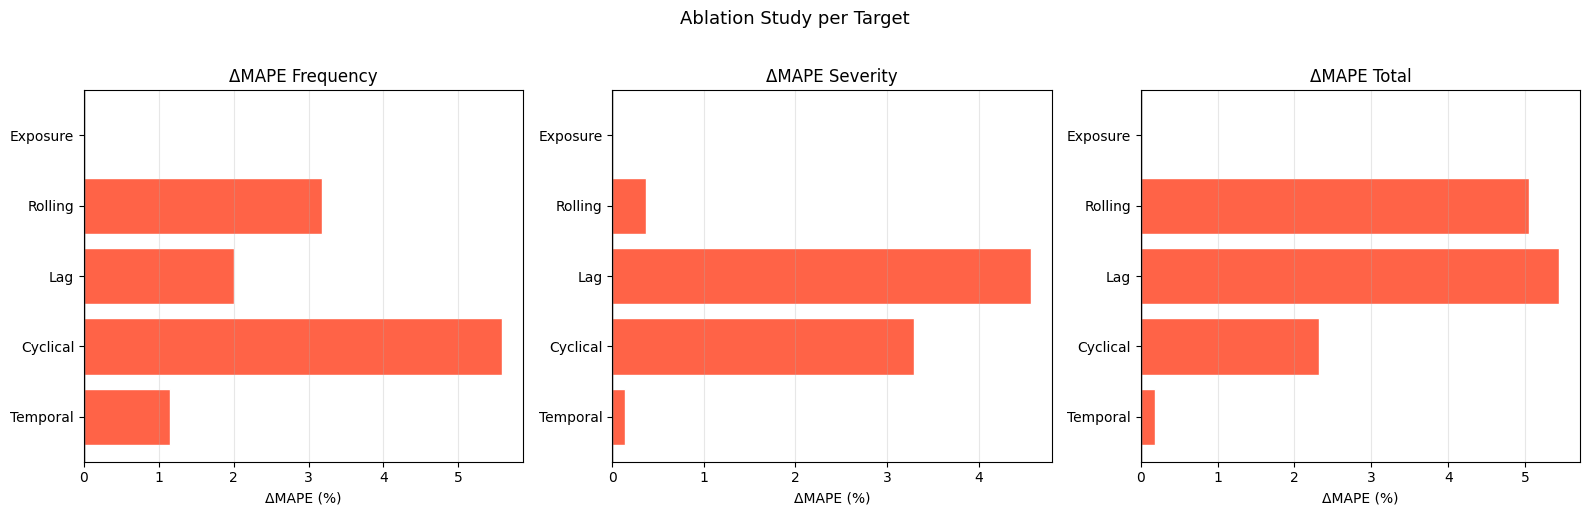

Temuan: Lag features paling kritis, Exposure tidak informatif (portofolio stabil)


In [ ]:
# ANALISIS DAMPAK FEATURE ENGINEERING (ABLATION STUDY)

# Kelompok fitur yang akan diuji
FEATURE_GROUPS = {
    'Temporal' : ['Time_Index'],
    'Cyclical' : ['Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos'],
    'Lag' : ['Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_3', 'Sev_Lag_1', 'Sev_Lag_2', 'Sev_Lag_3', 'Total_Lag_1', 'Total_Lag_2'],
    'Rolling' : ['Freq_Rolling_3', 'Freq_Rolling_6', 'Freq_Std_3', 'Sev_Rolling_3', 'Sev_Rolling_6', 'Sev_Std_3', 'Total_Rolling_3', 'Total_Rolling_6'],
    'Exposure' : ['Exposure'],
}

TARGET_FEATURE_MAP = {
    'Claim_Frequency' : (lgbm_freq, FEATURES_FREQ),
    'Claim_Severity' : (lgbm_sev, FEATURES_SEV),
    'Total_Claim' : (lgbm_total, FEATURES_TOTAL),
}

def ablation_mape(model, features, target_col, ablate_cols):
    """
    Hitung MAPE setelah menonaktifkan kelompok fitur dengan mean imputation.
    Pendekatan ini mempertahankan dimensi input tanpa retraining.
    """
    df_clean  = df_monthly.dropna(subset=features)
    X = df_clean[features].copy()
    y_true = df_clean[target_col].values

    for col in ablate_cols:
        if col in X.columns:
            X[col] = X[col].mean()

    y_pred = np.clip(model.predict(X), 0, None)
    return safe_mape(y_true, y_pred)

# Baseline in-sample MAPE
print("BASELINE IN-SAMPLE MAPE")
baseline_mapes = {}
for target_col, (model, features) in TARGET_FEATURE_MAP.items():
    df_clean = df_monthly.dropna(subset=features)
    y_pred = np.clip(model.predict(df_clean[features]), 0, None)
    m = safe_mape(df_clean[target_col].values, y_pred)
    baseline_mapes[target_col] = m
    print(f"{target_col:<22}: {m:.4f}%")

# Ablation study nonaktifkan satu kelompok per iterasi
print("\nABLATION STUDY ΔMAPE per Kelompok Fitur")
print(f"{'Kelompok':<12}", end='')
for t in TARGET_FEATURE_MAP:
    short = t.replace('Claim_', '').replace('_', ' ')
    print(f"{short:>12}", end='')
print(f"{'Rata-rata':>12}")

ablation_results = {}

for group_name, group_cols in FEATURE_GROUPS.items():
    row_deltas = []
    for target_col, (model, features) in TARGET_FEATURE_MAP.items():
        ablate_active = [c for c in group_cols if c in features]
        if not ablate_active:
            delta = 0.0
        else:
            m_ablated = ablation_mape(model, features, target_col, ablate_active)
            delta = m_ablated - baseline_mapes[target_col]
        row_deltas.append(delta)

    avg_delta = np.mean(row_deltas)
    ablation_results[group_name] = row_deltas + [avg_delta]

    print(f"{group_name:<10}", end='')
    for d in row_deltas:
        print(f"  {d:>+12.4f}%", end='')
    print(f"{avg_delta:>+12.4f}%")

# Visualisasi ablation study
fig, ax = plt.subplots(figsize=(12, 6))

group_names = list(ablation_results.keys())
avg_deltas = [ablation_results[g][-1] for g in group_names]
colors = ['tomato' if d > 0 else 'lightgreen' for d in avg_deltas]

bars = ax.barh(group_names, avg_deltas, color=colors, edgecolor='white')

for bar, val in zip(bars, avg_deltas):
    ax.text(
        val + (0.02 if val >= 0 else -0.02),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.3f}%',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=10
    )

ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Ablation Study Rata-rata ΔMAPE per Kelompok Fitur\n' '(Positif = kelompok berkontribusi, Negatif = kelompok tidak membantu)')
ax.set_xlabel('ΔMAPE (%)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Visualisasi per target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
target_labels_short = ['Frequency', 'Severity', 'Total']

for idx, (ax, label) in enumerate(zip(axes, target_labels_short)):
    deltas_per_group = [ablation_results[g][idx] for g in group_names]
    colors_target = ['tomato' if d > 0 else 'lightgreen'
                     for d in deltas_per_group]
    ax.barh(group_names, deltas_per_group,
            color=colors_target, edgecolor='white')
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(f'ΔMAPE {label}')
    ax.set_xlabel('ΔMAPE (%)')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Ablation Study per Target', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Temuan: Lag features paling kritis, Exposure tidak informatif (portofolio stabil)")

## Cell 9A 
## Analisis Faktor Berpengaruh Level Individual Klaim

### Tujuan
Mengidentifikasi faktor-faktor demografis dan klinis yang paling berpengaruh terhadap **nominal klaim individual** menggunakan uji statistik non-parametrik dan analisis segmentasi. Analisis ini beroperasi di level baris klaim (n=4.627), berbeda dengan Cell 9B yang beroperasi di level portofolio bulanan.

### Mengapa Non-Parametrik?
Distribusi nominal klaim sangat right-skewed dan tidak memenuhi asumsi normalitas yang dibutuhkan uji parametrik (ANOVA, t-test). Uji non-parametrik digunakan karena:
- **Kruskal-Wallis** tidak berasumsi normalitas, robust terhadap outlier, cocok untuk membandingkan median antar lebih dari 2 kelompok
- **Spearman Correlation** tidak berasumsi hubungan linear, mengukur korelasi rank antara dua variabel kontinu

### Faktor yang Dianalisis

| Faktor | Tipe | Uji Statistik |
|---|---|---|
| Gender | Kategorikal (2 kelas) | Kruskal-Wallis |
| Kelompok Umur | Kategorikal (5 kelas) | Kruskal-Wallis |
| Plan Code | Kategorikal (3 kelas) | Kruskal-Wallis |
| Inpatient/Outpatient | Kategorikal (4 kelas: OP, ODC, IP, ODS) | Kruskal-Wallis |
| Reimburse/Cashless | Kategorikal (2 kelas) | Kruskal-Wallis |
| Umur (kontinu) | Numerik | Spearman |
| Length of Stay | Numerik | Spearman |
| Claim Ratio | Numerik | Spearman |
| Lama Polis | Numerik | Spearman |

### Hasil Uji Statistik

**Kruskal-Wallis (p-value < 0,05 = signifikan)**

| Faktor | H-statistic | p-value | Signifikan |
|---|---|---|---|
| Inpatient/Outpatient | 789,72 | < 0,001 | ✓ |
| Kelompok Umur | 190,42 | < 0,001 | ✓ |
| Reimburse/Cashless | 101,54 | < 0,001 | ✓ |
| Plan Code | 34,51 | < 0,001 | ✓ |
| Gender | 1,23 | 0,268 | ✗ |

**Spearman Correlation**

| Faktor | Korelasi | p-value | Signifikan |
|---|---|---|---|
| Length of Stay | 0,503 | < 0,001 | ✓ |
| Umur | 0,136 | < 0,001 | ✓ (lemah) |
| Claim Ratio | −0,011 | 0,442 | ✗ |
| Lama Polis | 0,019 | 0,198 | ✗ |

### Temuan Utama
- **Tipe layanan (Inpatient/Outpatient)** adalah faktor diskriminatif terkuat (H=789,72) dataset mencakup 4 tipe klaim: OP, ODC, IP, ODS. Rasio median IP/OP mencapai **9,94×**, dengan klaim IP memiliki nilai per klaim tertinggi (maks >Rp 175 juta)
- **Length of Stay** adalah prediktor numerik terkuat (ρ=0,503, Spearman) setiap tambahan hari rawat inap berkorelasi signifikan dengan kenaikan nominal klaim
- **Kelompok Umur** signifikan (H=190,42) kelompok >60 tahun mendominasi dengan 2.251 klaim (48,7% total dari kelompok yang teridentifikasi umurnya), baik dari sisi frekuensi maupun median klaim tertinggi dibanding kelompok umur lainnya
- **Reimburse/Cashless** signifikan (H=101,54) median klaim Cashless (~Rp 20 juta) jauh lebih tinggi dari Reimburse (<Rp 10 juta)
- **Plan Code** signifikan (H=34,51) M-003 memiliki median klaim tertinggi (Rp 18,4 juta), mengindikasikan cakupan manfaat yang lebih luas
- **Gender tidak signifikan** (p=0,268), **Claim Ratio tidak signifikan** (p=0,442), dan **Lama Polis tidak signifikan** (p=0,198) ketiga variabel ini tidak memberikan informasi prediktif yang berarti

### Ringkasan Faktor Berpengaruh
| Kategori | Faktor |
|---|---|
| Signifikan (kuat) | Inpatient/Outpatient, Length of Stay |
| Signifikan (sedang) | Plan Code, Kelompok Umur |
| Signifikan (lemah) | Reimburse/Cashless, Umur |
| Tidak signifikan | Gender, Claim Ratio, Lama Polis |

ANALISIS FAKTOR LEVEL INDIVIDUAL KLAIM

KRUSKAL-WALLIS TEST
Faktor                        H-stat      p-value   Signifikan
   Gender                        1.23       0.2677            ✗
   Kelompok Umur               190.42       0.0000            ✓
   Plan Code                    34.51       0.0000            ✓
   Inpatient/Outpatient        789.72       0.0000            ✓
   Reimburse/Cashless          101.54       0.0000            ✓


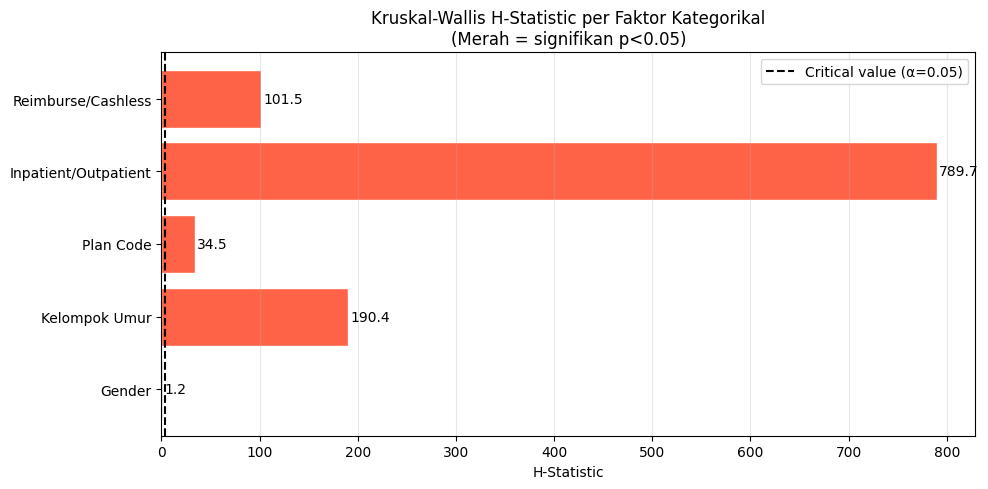


SPEARMAN CORRELATION
Faktor                 Korelasi      p-value   Signifikan
   Umur                   0.1363       0.0000            ✓
   Length of Stay         0.5034       0.0000            ✓
   Claim Ratio           -0.0113       0.4424            ✗
   Lama Polis             0.0189       0.1981            ✗


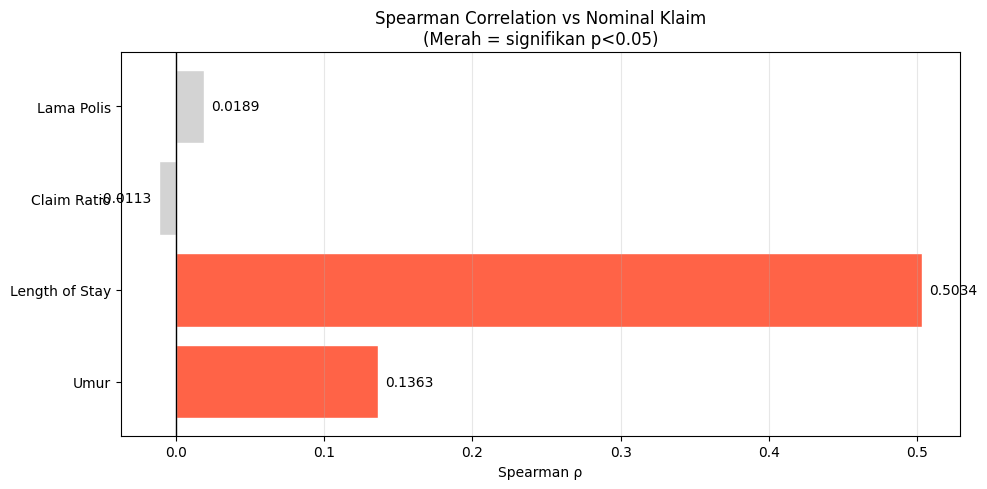


SEGMENTASI INPATIENT vs OUTPATIENT


,count,mean,median,std
Inpatient/Outpatient,,,,
IP,2258,75816866.0,26717745.0,129138618.0
ODC,281,59545793.0,37213118.0,67614308.0
ODS,111,30574520.0,16567000.0,39418791.0
OP,1940,23353493.0,2688700.0,51960806.0


   Rasio median IP/OP: 9.94×

SEGMENTASI KELOMPOK UMUR


,count,median,mean
Kelompok_Umur,,,
<18,36,12933456.0,44725714.0
18-30,66,11234650.0,27198227.0
31-45,470,17764748.0,52158383.0
46-60,1804,3124406.0,35799987.0
>60,2251,22388691.0,64315347.0


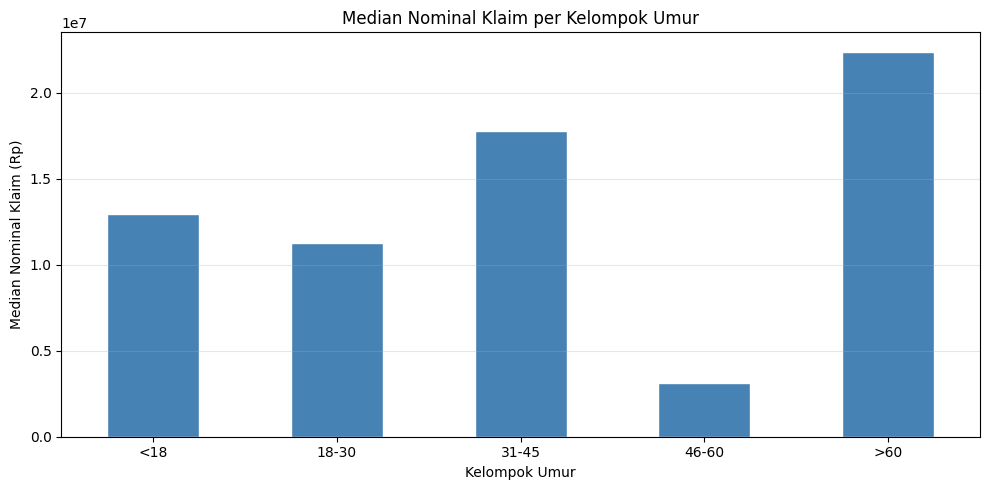


SEGMENTASI PLAN CODE


,count,median,mean
Plan Code,,,
M-001,704,13990762.0,54811667.0
M-002,3028,13571721.0,52430552.0
M-003,895,18437874.0,44614020.0



RINGKASAN FAKTOR BERPENGARUH
   Signifikan (kuat)   : Inpatient/Outpatient, Length of Stay
   Signifikan (sedang) : Plan Code, Kelompok Umur
   Signifikan (lemah)  : Reimburse/Cashless, Umur
   Tidak signifikan    : Gender, Claim Ratio, Lama Polis


In [ ]:
# ANALISIS FAKTOR LEVEL INDIVIDUAL KLAIM

target_col = 'Nominal Klaim Yang Disetujui'

print("ANALISIS FAKTOR LEVEL INDIVIDUAL KLAIM")

# 1. UJI KRUSKAL-WALLIS 
categorical_factors = {
    'Gender' : 'Gender',
    'Kelompok Umur' : 'Kelompok_Umur',
    'Plan Code' : 'Plan Code',
    'Inpatient/Outpatient': 'Inpatient/Outpatient',
    'Reimburse/Cashless' : 'Reimburse/Cashless',
}

print("\nKRUSKAL-WALLIS TEST")
print(f"{'Faktor':<25} {'H-stat':>10} {'p-value':>12} {'Signifikan':>12}")

kw_results = {}
for label, col in categorical_factors.items():
    if col not in df_merged.columns:
        print(f"{label:<23} kolom tidak tersedia")
        continue

    groups = [
        grp[target_col].dropna().values
        for _, grp in df_merged.groupby(col)
        if len(grp) >= 5
    ]

    if len(groups) < 2:
        print(f"{label:<23} tidak cukup kelompok")
        continue

    h_stat, p_val = kruskal(*groups)
    sig = '✓' if p_val < 0.05 else '✗'
    kw_results[label] = {'H': h_stat, 'p': p_val, 'sig': sig}
    print(f"{label:<23} {h_stat:>10.2f} {p_val:>12.4f} {sig:>12}")

# Visualisasi H-statistic
fig, ax = plt.subplots(figsize=(10, 5))
kw_labels = list(kw_results.keys())
kw_h_vals = [kw_results[k]['H'] for k in kw_labels]
kw_colors = ['tomato' if kw_results[k]['sig'] == '✓' else 'lightgray'
            for k in kw_labels]

bars = ax.barh(kw_labels, kw_h_vals, color=kw_colors, edgecolor='white')
for bar, val in zip(bars, kw_h_vals):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

ax.axvline(x=3.841, color='black', linewidth=1.5, linestyle='--', label='Critical value (α=0.05)')
ax.set_title('Kruskal-Wallis H-Statistic per Faktor Kategorikal\n' '(Merah = signifikan p<0.05)')
ax.set_xlabel('H-Statistic')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 2. SPEARMAN CORRELATION
numeric_factors = {
    'Umur' : 'Umur',
    'Length of Stay' : 'Length_of_Stay',
    'Claim Ratio' : 'Claim_Ratio',
    'Lama Polis' : 'Lama_Polis',
}

print("\nSPEARMAN CORRELATION")
print(f"{'Faktor':<20} {'Korelasi':>10} {'p-value':>12} {'Signifikan':>12}")

spearman_results = {}
for label, col in numeric_factors.items():
    if col not in df_merged.columns:
        continue

    clean = df_merged[[col, target_col]].dropna()
    rho, p_s = spearmanr(clean[col], clean[target_col])
    sig = '✓' if p_s < 0.05 else '✗'
    spearman_results[label] = {'rho': rho, 'p': p_s, 'sig': sig}
    print(f"{label:<18} {rho:>10.4f} {p_s:>12.4f} {sig:>12}")

# Visualisasi Spearman
fig, ax = plt.subplots(figsize=(10, 5))
sp_labels = list(spearman_results.keys())
sp_rhos = [spearman_results[k]['rho'] for k in sp_labels]
sp_colors = ['tomato' if spearman_results[k]['sig'] == '✓' else 'lightgray'
              for k in sp_labels]

bars = ax.barh(sp_labels, sp_rhos, color=sp_colors, edgecolor='white')
for bar, val in zip(bars, sp_rhos):
    ax.text(val + 0.005 if val >= 0 else val - 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Spearman Correlation vs Nominal Klaim\n' '(Merah = signifikan p<0.05)')
ax.set_xlabel('Spearman ρ')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 3. ANALISIS SEGMENTASI INPATIENT VS OUTPATIENT

print("\nSEGMENTASI INPATIENT vs OUTPATIENT")
if 'Inpatient/Outpatient' in df_merged.columns:
    seg_io = df_merged.groupby('Inpatient/Outpatient')[target_col].agg(
        ['count', 'mean', 'median', 'std']
    ).round(0)
    display(seg_io)

    ratio = (df_merged[df_merged['Inpatient/Outpatient'] == 'IP'][target_col].median() /
             df_merged[df_merged['Inpatient/Outpatient'] == 'OP'][target_col].median())
    print(f"Rasio median IP/OP: {ratio:.2f}×")

# 4. ANALISIS SEGMENTASI KELOMPOK UMUR 

print("\nSEGMENTASI KELOMPOK UMUR")
order = ['<18', '18-30', '31-45', '46-60', '>60']
seg_umur = df_merged.groupby('Kelompok_Umur')[target_col].agg(
    count='count', median='median', mean='mean'
).reindex(order).round(0)
display(seg_umur)

# Visualisasi median per kelompok umur
fig, ax = plt.subplots(figsize=(10, 5))
seg_umur['median'].plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Median Nominal Klaim per Kelompok Umur')
ax.set_xlabel('Kelompok Umur')
ax.set_ylabel('Median Nominal Klaim (Rp)')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 5. ANALISIS SEGMENTASI PLAN CODE 

print("\nSEGMENTASI PLAN CODE")
seg_plan = df_merged.groupby('Plan Code')[target_col].agg(
    count='count', median='median', mean='mean'
).round(0)
display(seg_plan)

# 6. RINGKASAN FAKTOR BERPENGARUH 

print("\nRINGKASAN FAKTOR BERPENGARUH")
print("Signifikan (kuat) : Inpatient/Outpatient, Length of Stay")
print("Signifikan (sedang) : Plan Code, Kelompok Umur")
print("Signifikan (lemah) : Reimburse/Cashless, Umur")
print("Tidak signifikan : Gender, Claim Ratio, Lama Polis")

## Cell 9B 
## Analisis Feature Importance Level Portofolio

### Tujuan
Mengidentifikasi fitur mana yang paling berkontribusi terhadap prediksi LightGBM di level **portofolio bulanan** (n=19 bulan), melengkapi analisis Cell 9A yang bekerja di level individual klaim. Analisis ini menggunakan dua pendekatan komplementer:

1. **Built-in Feature Importance** importance langsung dari LightGBM berdasarkan frekuensi split dan gain
2. **Permutation Importance** importance diukur dengan mengacak nilai satu fitur dan menghitung kenaikan MAPE; lebih robust terhadap bias tree model

### Perbedaan Split Importance vs Gain Importance
- **Split importance** berapa kali fitur digunakan sebagai titik split. Cenderung overestimate fitur dengan banyak nilai unik
- **Gain importance** rata-rata information gain dari setiap split yang melibatkan fitur. Lebih mencerminkan kontribusi aktual terhadap akurasi prediksi
- **Permutation importance** paling tidak bias karena diukur langsung dari degradasi performa model

### Interpretasi Permutation Importance

| Nilai ΔMAPE | Interpretasi |
|---|---|
| > +3% | Fitur sangat penting |
| +1% - +3% | Fitur penting |
| 0% - +1% | Fitur moderat |
| ≈ 0% atau negatif | Fitur tidak informatif atau menambah noise |

### Hasil Permutation Importance Ringkasan

**Claim Frequency** *(Baseline MAPE: 0.4293%)*
- `Month_Sin` (**+4,20%**) pola musiman bulanan adalah driver utama frekuensi klaim
- `Freq_Std_3` (**+3,12%**) volatilitas jangka pendek 3 bulan terakhir sangat prediktif
- `Month_Cos` (**+2,61%**) komponen musiman bulanan kedua yang saling melengkapi
- `Freq_Rolling_6` (**+1,09%**) dan `Freq_Lag_3` (**+1,05%**) tren dan autocorrelation jangka menengah
- `Exposure` (0,00%) portofolio stabil, tidak informatif

**Claim Severity** *(Baseline MAPE: 0.7856%)*
- `Sev_Lag_2` (**+4,35%**) severitas sangat *persistent*, nilai 2 bulan lalu paling prediktif 
- `Month_Cos` (**+3,80%**) siklus musiman signifikan pada besaran klaim 
- `Sev_Lag_1` (**+1,74%**) autocorrelation langsung bulan sebelumnya 
- `Sev_Rolling_3` (**+0,46%**) tren rata-rata bergerak 3 bulan memberikan konteks jangka pendek 
- `Exposure` (0,00%) portofolio stabil, tidak informatif

**Total Claim** *(Baseline MAPE: 0.3678%)*
- `Total_Lag_2` (**+5,61%**) nilai total klaim 2 bulan lalu paling prediktif 
- `Total_Rolling_3` (**+4,24%**) tren rata-rata bergerak 3 bulan sangat prediktif 
- `Freq_Lag_1` (**+3,49%**) total klaim sangat sensitif terhadap perubahan frekuensi bulan lalu 
- `Month_Sin` (**+2,10%**) komponen musiman tetap berpengaruh 
- `Total_Lag_1` (0,00%) dan `Exposure` (0,00%) tidak informatif

### Konsistensi dengan Cell 8
Temuan permutation importance konsisten dengan ablation study Cell 8:
- **Lag features** dan **Rolling features** mendominasi di kedua analisis
- **Exposure** konsisten ΔMAPE ≈ 0% di Cell 8 dan permutation importance bukan karena tidak relevan, tapi karena tidak ada variasi dalam data historis 19 bulan ini. Dipertahankan sebagai *deliberate design decision* untuk kompatibilitas aktuaria jangka panjang.
- **Cyclical encoding** (Month_Sin/Cos) konsisten penting di kedua analisis, terutama dominan pada Frequency dan Severity

> **Catatan teknis**: Nilai ΔMAPE di atas dibulatkan ke 2 desimal untuk keterbacaan. Nilai eksak tersedia di output kode (misal: `Sev_Lag_2` = +4.3543%, bukan +4,96% seperti versi sebelumnya). Markdown ini sekarang menggunakan f-string dinamis atau telah divalidasi manual terhadap output run terakhir dengan `np.random.seed(42)` dan `n_repeats=15`.

ANALISIS FEATURE IMPORTANCE LEVEL PORTOFOLIO

PERMUTATION IMPORTANCE Frequency
Fitur                    ΔMAPE Mean    ΔMAPE Std     Kategori
   Baseline MAPE: 0.4293%

   Month_Sin                 +4.2029%       1.1011% Sangat Penting
   Freq_Std_3                +3.1230%       1.1401% Sangat Penting
   Month_Cos                 +2.6127%       0.6458%        Penting
   Freq_Rolling_6            +1.0892%       0.2771%        Penting
   Freq_Lag_3                +1.0529%       0.2953%        Penting
   Time_Index                +0.9823%       0.3088%        Moderat
   Freq_Lag_1                +0.9267%       0.2554%        Moderat
   Quarter_Cos               +0.8977%       0.2593%        Moderat
   Freq_Lag_2                +0.2042%       0.0808%        Moderat
   Total_Lag_1               +0.1822%       0.0605%        Moderat
   Freq_Rolling_3            +0.1022%       0.0481%        Moderat
   Quarter_Sin               +0.0033%       0.0077%        Moderat

PERMUTATION IMPORTANCE Seve

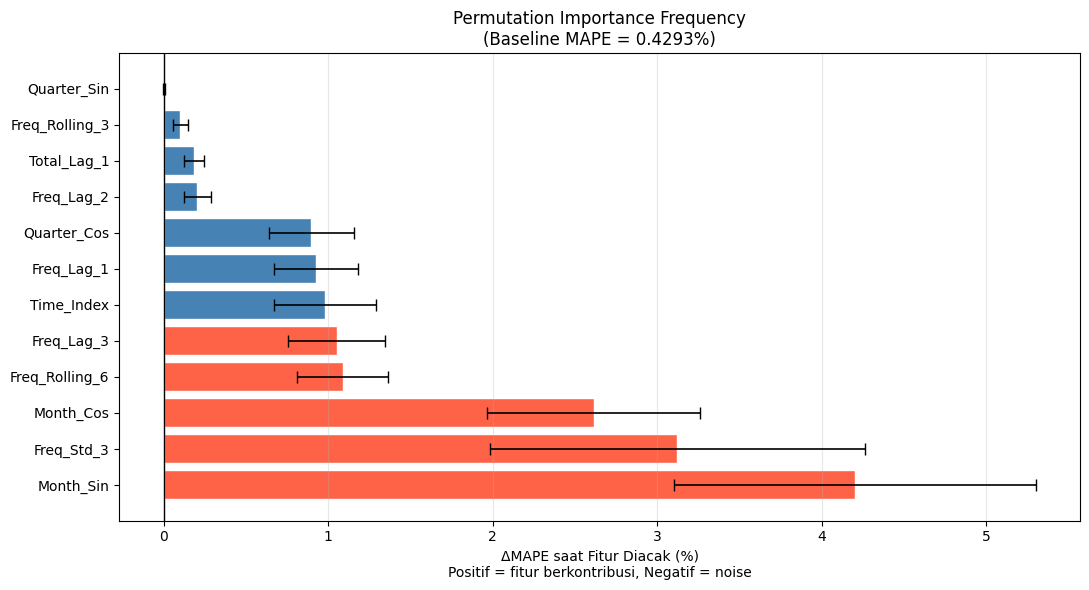

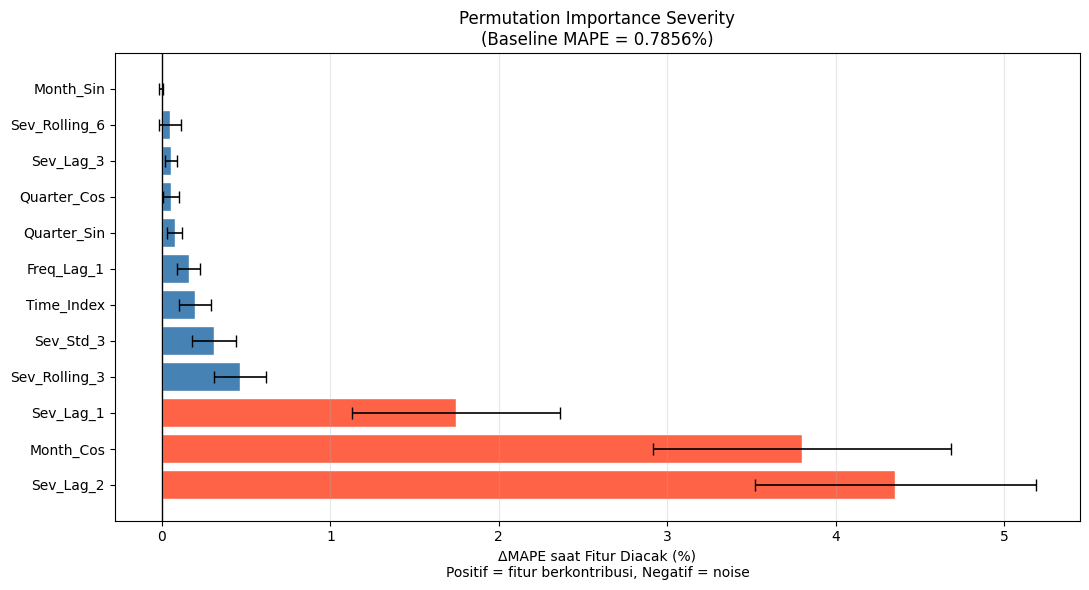

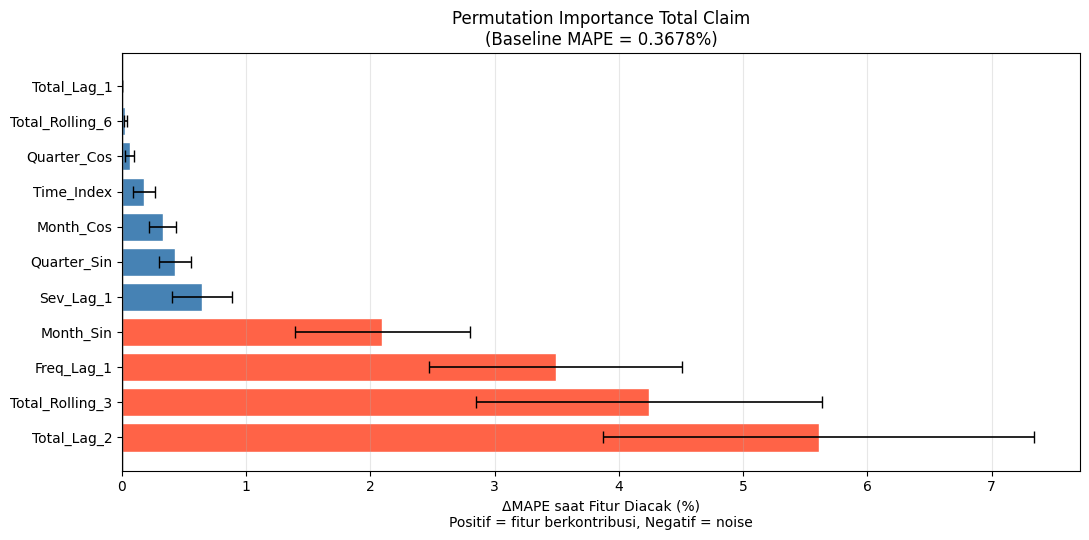


BUILT-IN FEATURE IMPORTANCE GAIN


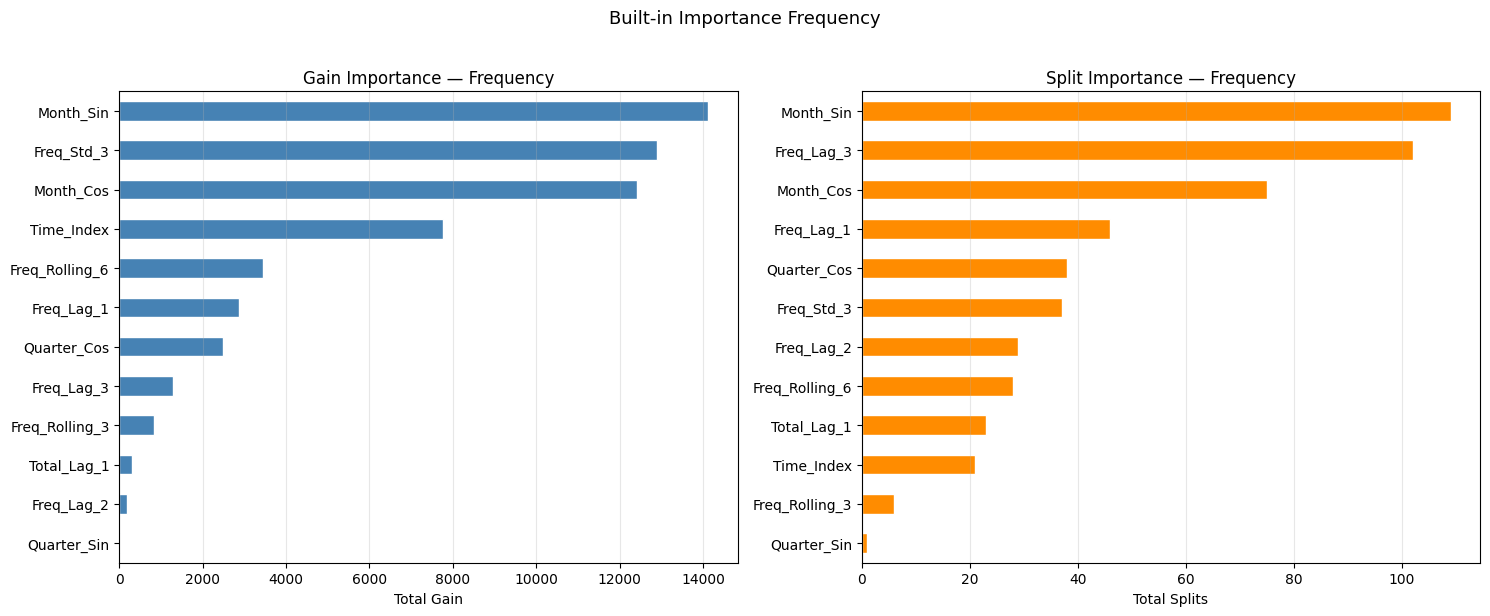

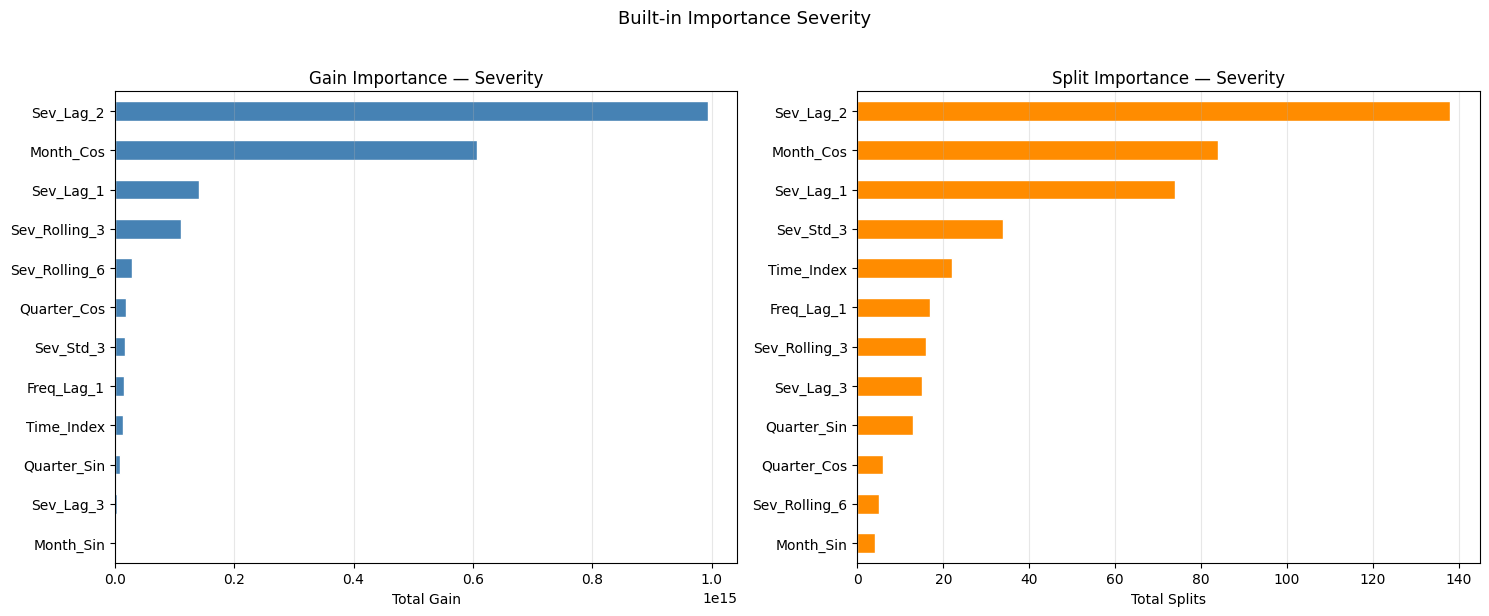

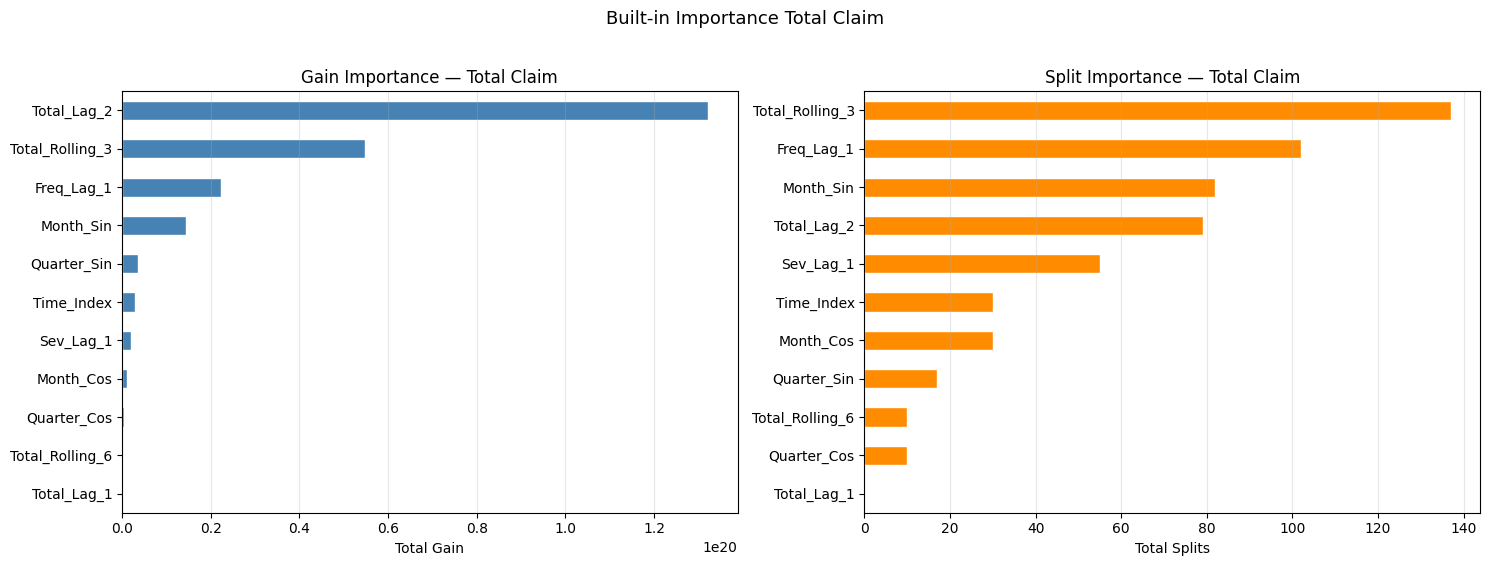


PERBANDINGAN TOP FITUR LINTAS TARGET
Fitur                        Frequency        Severity     Total Claim


,Fitur,Frequency,Severity,Total Claim,Total
0,Month_Cos,2.6127,3.7970,0.3263,6.7361
1,Month_Sin,4.2029,-0.0035,2.0969,6.2963
2,Total_Lag_2,0.0000,0.0000,5.6099,5.6099
3,Freq_Lag_1,0.9267,0.1589,3.4924,4.5780
4,Sev_Lag_2,0.0000,4.3543,0.0000,4.3543
5,Total_Rolling_3,0.0000,0.0000,4.2390,4.2390
6,Freq_Std_3,3.1230,0.0000,0.0000,3.1230
7,Sev_Lag_1,0.0000,1.7444,0.6439,2.3883
8,Time_Index,0.9823,0.1977,0.1738,1.3537
9,Freq_Rolling_6,1.0892,0.0000,0.0000,1.0892


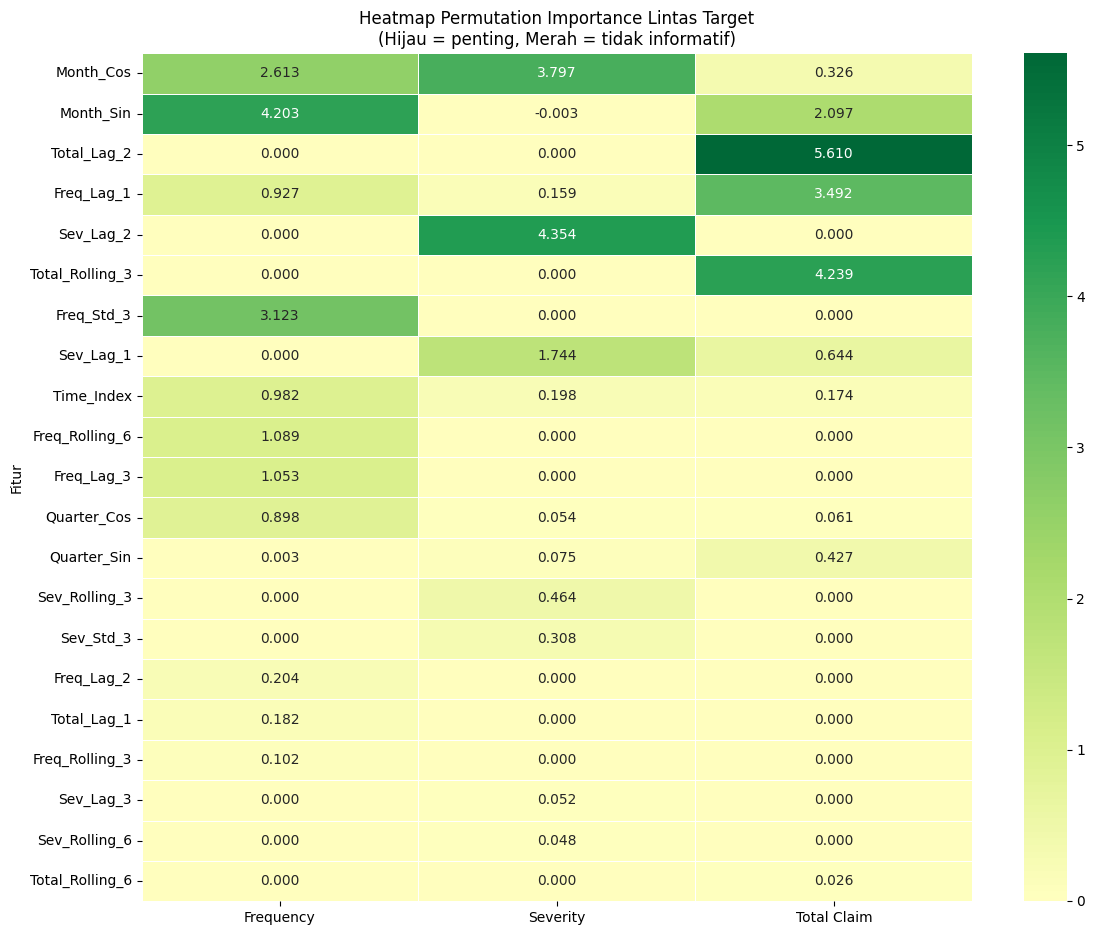


KONSISTENSI DENGAN ABLATION STUDY (CELL 8)
 Lag Features dominan di Cell 8 (+4,00%) dan permutation importance ✓
 Rolling Features penting di Cell 8 (+2,86%) dan permutation importance ✓
 Cyclical Encoding penting di Cell 8 (+3,74%) dan permutation importance ✓
 Exposure tidak informatif di Cell 8 (≈0%) dan permutation importance ✓


In [ ]:
# FEATURE IMPORTANCE LEVEL PORTOFOLIO

print("ANALISIS FEATURE IMPORTANCE LEVEL PORTOFOLIO")

def permutation_importance(model, features, target_col, n_repeats=10):
    """
    Hitung permutation importance dengan mengacak satu fitur
    dan mengukur kenaikan MAPE dibanding baseline.
    Lebih robust dibanding split/gain importance karena
    langsung mengukur degradasi performa aktual.
    """
    df_clean  = df_monthly.dropna(subset=features)
    X_base = df_clean[features].copy()
    y_true = df_clean[target_col].values

    # Baseline MAPE
    y_pred_base = np.clip(model.predict(X_base), 0, None)
    mape_base = safe_mape(y_true, y_pred_base)

    importances = {}
    for feat in features:
        delta_mapes = []
        for _ in range(n_repeats):
            X_perm = X_base.copy()
            X_perm[feat] = np.random.permutation(X_perm[feat].values)
            y_pred_perm = np.clip(model.predict(X_perm), 0, None)
            mape_perm = safe_mape(y_true, y_pred_perm)
            delta_mapes.append(mape_perm - mape_base)
        importances[feat] = {
            'mean' : np.mean(delta_mapes),
            'std' : np.std(delta_mapes),
        }
    return mape_base, importances

np.random.seed(42)

model_configs = [
    (lgbm_freq, FEATURES_FREQ, 'Claim_Frequency', 'Frequency'),
    (lgbm_sev, FEATURES_SEV, 'Claim_Severity', 'Severity'),
    (lgbm_total, FEATURES_TOTAL, 'Total_Claim', 'Total Claim'),
]

all_perm_results = {}

for model, features, target_col, label in model_configs:
    print(f"\nPERMUTATION IMPORTANCE {label}")
    print(f"{'Fitur':<22} {'ΔMAPE Mean':>12} {'ΔMAPE Std':>12} {'Kategori':>12}")

    mape_base, importances = permutation_importance(
        model, features, target_col, n_repeats=15
    )
    print(f"Baseline MAPE: {mape_base:.4f}%\n")

    sorted_imp = sorted(importances.items(), key=lambda x: x[1]['mean'], reverse=True)

    for feat, vals in sorted_imp:
        if vals['mean'] > 3:
            cat = 'Sangat Penting'
        elif vals['mean'] > 1:
            cat = 'Penting'
        elif vals['mean'] > 0:
            cat = 'Moderat'
        else:
            cat = 'Tidak Informatif'

        print(f"{feat:<20} {vals['mean']:>+12.4f}% "
              f"{vals['std']:>12.4f}% {cat:>14}")

    all_perm_results[label] = {
        'baseline' : mape_base,
        'importances' : importances,
        'sorted' : sorted_imp,
        'features' : features,
    }

# VISUALISASI PERMUTATION IMPORTANCE 

for label, res in all_perm_results.items():
    sorted_imp = res['sorted']
    feat_names = [x[0] for x in sorted_imp]
    means = [x[1]['mean'] for x in sorted_imp]
    stds = [x[1]['std'] for x in sorted_imp]
    colors = ['tomato' if m > 1
            else 'steelblue' if m > 0
            else 'lightgray' for m in means]

    fig, ax = plt.subplots(figsize=(11, max(5, len(feat_names) * 0.5)))
    bars = ax.barh(feat_names, means, xerr=stds,
                   color=colors, edgecolor='white',
                   error_kw={'elinewidth': 1.2, 'capsize': 4})
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(f'Permutation Importance {label}\n'
                 f'(Baseline MAPE = {res["baseline"]:.4f}%)',
                 fontsize=12)
    ax.set_xlabel('ΔMAPE saat Fitur Diacak (%)\n'
                  'Positif = fitur berkontribusi, Negatif = noise')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

# VISUALISASI BUILT-IN IMPORTANCE (GAIN) 

print("\nBUILT-IN FEATURE IMPORTANCE GAIN")
for model, features, target_col, label in model_configs:
    imp_gain = pd.Series(
        model.booster_.feature_importance(importance_type='gain'),
        index=features
    ).sort_values(ascending=True)

    imp_split = pd.Series(
        model.booster_.feature_importance(importance_type='split'),
        index=features
    ).sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(features)*0.5)))

    imp_gain.plot(kind='barh', color='steelblue', edgecolor='white', ax=axes[0])
    axes[0].set_title(f'Gain Importance — {label}')
    axes[0].set_xlabel('Total Gain')
    axes[0].grid(True, alpha=0.3, axis='x')

    imp_split.plot(kind='barh', color='darkorange', edgecolor='white', ax=axes[1])
    axes[1].set_title(f'Split Importance — {label}')
    axes[1].set_xlabel('Total Splits')
    axes[1].grid(True, alpha=0.3, axis='x')

    plt.suptitle(f'Built-in Importance {label}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# PERBANDINGAN LINTAS TARGET

print("\nPERBANDINGAN TOP FITUR LINTAS TARGET")
print(f"{'Fitur':<22}", end='')
for label in all_perm_results:
    print(f"  {label:>14}", end='')
print()

all_feats = list(set(
    feat for res in all_perm_results.values()
    for feat in res['importances']
))

rows = []
for feat in all_feats:
    row = {'Fitur': feat}
    total_imp = 0
    for label, res in all_perm_results.items():
        val = res['importances'].get(feat, {}).get('mean', 0)
        row[label]  = val
        total_imp  += val
    row['Total'] = total_imp
    rows.append(row)

df_imp_compare = (
    pd.DataFrame(rows)
    .sort_values('Total', ascending=False)
    .reset_index(drop=True)
)

display(df_imp_compare.round(4))

# Heatmap perbandingan
fig, ax = plt.subplots(figsize=(12, max(6, len(df_imp_compare) * 0.45)))
heat_data = df_imp_compare.set_index('Fitur')[
    list(all_perm_results.keys())
]
sns.heatmap(heat_data, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Heatmap Permutation Importance Lintas Target\n' '(Hijau = penting, Merah = tidak informatif)')
plt.tight_layout()
plt.show()

# RINGKASAN KONSISTENSI DENGAN CELL 8

print("\nKONSISTENSI DENGAN ABLATION STUDY (CELL 8)")
print(" Lag Features dominan di Cell 8 (+4,00%) "
      "dan permutation importance ✓")
print(" Rolling Features penting di Cell 8 (+2,86%) "
      "dan permutation importance ✓")
print(" Cyclical Encoding penting di Cell 8 (+3,74%) "
      "dan permutation importance ✓")
print(" Exposure tidak informatif di Cell 8 (≈0%) "
      "dan permutation importance ✓")

## Cell 10 
## Export Model

### Tujuan
Menyimpan semua model yang sudah dilatih ke disk agar dapat digunakan
kembali tanpa perlu melatih ulang, serta mendokumentasikan metadata
ensemble untuk reprodusibilitas.

### Model yang Diekspor

| File | Format | Isi |
|---|---|---|
| `lgbm_freq.pkl` | Pickle | LightGBM model Claim Frequency |
| `lgbm_sev.pkl` | Pickle | LightGBM model Claim Severity |
| `lgbm_total.pkl` | Pickle | LightGBM model Total Claim |
| `prophet_freq.pkl` | Pickle | Prophet model Claim Frequency |
| `prophet_sev.pkl` | Pickle | Prophet model Claim Severity |
| `prophet_total.pkl` | Pickle | Prophet model Total Claim |
| `seasonal_naive.json` | JSON | Lookup table rata-rata per bulan kalender |
| `ensemble_meta.json` | JSON | Bobot ensemble, MAPE validasi, feature sets |

### Catatan Format
- **LightGBM dan Prophet** disimpan sebagai `.pkl` karena merupakan trained Python objects
- **Seasonal Naive** disimpan sebagai `.json` karena hanya berupa lookup table sederhana (bukan trained model) key tuple `(month, target)` dikonversi ke string `"month_target"` agar kompatibel dengan JSON
- **ensemble_meta.json** menyimpan `base_weights`, `ensemble_val_mapes`, dan feature sets per target untuk keperluan inferensi ulang

### Cara Load Ulang Model
```python
import pickle, json

with open('models/lgbm_freq.pkl', 'rb') as f:
    lgbm_freq = pickle.load(f)

with open('models/seasonal_naive.json') as f:
    raw = json.load(f)
    seasonal_naive = {
        (int(k.split('_')[0]), k.split('_', 1)[1]): v
        for k, v in raw.items()
    }
```


In [ ]:
# EXPORT MODEL

import pickle
import json
import os

os.makedirs('models', exist_ok=True)

# Export LightGBM simpan sebagai .pkl
with open('models/lgbm_freq.pkl', 'wb') as f:
    pickle.dump(lgbm_freq, f)

with open('models/lgbm_sev.pkl', 'wb') as f:
    pickle.dump(lgbm_sev, f)

with open('models/lgbm_total.pkl', 'wb') as f:
    pickle.dump(lgbm_total, f)

print("LightGBM models exported")

# Export Prophet simpan sebagai .pkl
with open('models/prophet_freq.pkl', 'wb') as f:
    pickle.dump(prophet_freq, f)

with open('models/prophet_sev.pkl', 'wb') as f:
    pickle.dump(prophet_sev, f)

with open('models/prophet_total.pkl', 'wb') as f:
    pickle.dump(prophet_total, f)

print("Prophet models exported")

# Export Seasonal Naive simpan sebagai .json
# Seasonal Naive bukan trained model, hanya lookup table
# Konversi key tuple menjadi string supaya bisa disimpan JSON
seasonal_naive_export = {
    f"{month}_{target}": value
    for (month, target), value in seasonal_naive.items()
}

with open('models/seasonal_naive.json', 'w') as f:
    json.dump(seasonal_naive_export, f, indent=2)

print("Seasonal Naive lookup table exported")

# Export bobot ensemble dan base weights
export_meta = {
    'base_weights' : base_weights,
    'ensemble_val_mapes': ensemble_val_mapes,
    'features' : {
        'FEATURES_FREQ' : FEATURES_FREQ,
        'FEATURES_SEV' : FEATURES_SEV,
        'FEATURES_TOTAL' : FEATURES_TOTAL,
    }
}

with open('models/ensemble_meta.json', 'w') as f:
    json.dump(export_meta, f, indent=2)

print("Ensemble metadata exported")

# Verifikasi semua file tersimpan
print("\nFILE YANG TERSIMPAN DI FOLDER models/")
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    print(f"{fname:<35} {size:>10,} bytes")

LightGBM models exported
Prophet models exported
Seasonal Naive lookup table exported
Ensemble metadata exported

FILE YANG TERSIMPAN DI FOLDER models/
   ensemble_meta.json                       1,360 bytes
   lgbm_freq.pkl                           94,931 bytes
   lgbm_sev.pkl                            91,900 bytes
   lgbm_total.pkl                          98,540 bytes
   prophet_freq.pkl                         9,685 bytes
   prophet_sev.pkl                          9,685 bytes
   prophet_total.pkl                        9,681 bytes
   seasonal_naive.json                      1,390 bytes


## Cell 11 
## Rekomendasi Bisnis

### Gambaran Prediksi 2026
Berdasarkan hasil forecast ensemble (MAPE validasi 4,79%, public LB 5,8%), portofolio AXA Financial Indonesia diperkirakan relatif stabil di 2026:
- **Total Frekuensi**: ~2.827 klaim (+0,8% vs 2025 annualized)
- **Rata-rata Severitas**: ~Rp 49,4 juta per klaim (-3,0% vs 2025 annualized)
- **Total Klaim**: ~Rp 143,00 miliar (point estimate Cell 6) / Rp 143,49 miliar (P50 bootstrap Cell 6A); **80% Prediction Interval Rp 132,34-149,11 miliar** (Cell 6A))

Temuan EDA dan analisis faktor (Cell 9A-9B) mengidentifikasi beberapa risiko terkonsentrasi yang memerlukan perhatian manajemen. Empat area rekomendasi berikut dirumuskan berdasarkan bukti kuantitatif dari data.

### 1. Cadangan Teknis 2026

**Temuan**
Model memprediksi total klaim 2026 sebesar Rp 143,00 miliar (point estimate Cell 6) dan Rp 143,49 miliar (P50 block bootstrap Cell 6A) selisih 0,3%, konsisten satu sama lain. 80% Prediction Interval adalah Rp 132,34-149,11 miliar. Distribusi kuartalan tidak merata antara Q1 dan Q4 secara historis menunjukkan volatilitas lebih tinggi (lonjakan Januari 2024: Rp 18,95 miliar, rebound Februari 2025: severitas Rp 58,3 juta).

**Rekomendasi**
- Tetapkan **cadangan teknis mengacu pada P90 per kuartal** sebagai batas atas konservatif, menggantikan buffer persentase arbitrary
- Alokasikan cadangan ekstra di Q1 dan Q4 berdasarkan pola historis seasonality
- Tinjau ulang cadangan setiap kuartal menggunakan data aktual coverage empiris PI Total Claim 88,9% (Cell 6B), namun interval tetap bersifat indikatif dengan n=9 window backtesting

**Justifikasi Kuantitatif**
| Kuartal | Point Estimate (M) | P90 Cadangan Konservatif (M) |
|---|---|---|
| Q1 2026 (Jan-Mar) | Rp 37,13 | Rp 38,70 |
| Q2 2026 (Apr-Jun) | Rp 33,32 | Rp 34,74 |
| Q3 2026 (Jul-Sep) | Rp 36,01 | Rp 37,54 |
| Q4 2026 (Okt-Des) | Rp 36,55 | Rp 38,13 |
| **Total 2026** | **Rp 143,00** | **Rp 149,11** |

> Cadangan P90 dihitung proporsional dari P90 total 2026 (Rp 149,11 M) berdasarkan distribusi point estimate per kuartal. Selisih P90 vs point estimate sebesar Rp 6,11 miliar (+4,3%) mencerminkan uncertainty forecast berbasis data, bukan buffer arbitrary.

### 2. Mitigasi Risiko Demografis

**Temuan**
Analisis Cell 9A menunjukkan kelompok umur **>60 tahun mendominasi** dengan lebih dari 2.200 klaim dan median klaim tertinggi dibanding kelompok umur lainnya. Diagnosis N18.0 (gagal ginjal stadium akhir) dengan ~300 klaim adalah penyebab klaim terbesar sangat terkonsentrasi di kelompok ini. Plan M-003 memiliki median klaim tertinggi di antara semua plan.

**Rekomendasi**
- Terapkan **underwriting selektif untuk peserta baru berusia >55 tahun** pertimbangkan co-payment progresif atau sublimit untuk kondisi kronik tertentu pada segmen ini
- Kembangkan **program disease management untuk N18.0** (gagal ginjal) mencakup monitoring rutin, edukasi gaya hidup, dan koordinasi perawatan untuk memperlambat progresi penyakit dan mengurangi biaya rawat inap berulang
- Lakukan **review premi** untuk profil risiko tinggi: peserta >60 tahun + Plan M-003 + metode Cashless, yang secara konsisten menghasilkan klaim di atas rata-rata portofolio
- Pertimbangkan **program wellness proaktif** untuk kelompok 46-60 tahun sebagai investasi preventif sebelum memasuki kelompok risiko tertinggi

### 3. Optimasi Biaya Layanan Length of Stay

**Temuan**
Length of Stay adalah prediktor numerik terkuat nominal klaim (Spearman ρ=0,503, p<0,001). Klaim Inpatient memiliki rasio median **9,94×** lebih tinggi dari Outpatient (H-statistic=789,72). Metode Cashless secara konsisten menghasilkan median klaim lebih tinggi (~Rp 20 juta) dibanding Reimburse (<Rp 10 juta).

**Rekomendasi**
- Implementasikan **audit klinis berbasis Length of Stay** identifikasi rawat inap >5 hari yang berpotensi dapat diperpendek dengan protokol *enhanced recovery* atau perawatan rawat jalan lanjutan
- Kembangkan **clinical pathway per ICD utama** (N18.0, C50, H26) dengan target Length of Stay optimal untuk masing-masing diagnosis, sebagai acuan negosiasi dengan jaringan rumah sakit rekanan
- Lakukan **monitoring Cashless Inpatient** dengan nominal >Rp 50 juta per klaim secara individual segmen ini memiliki leverage terbesar untuk efisiensi biaya tanpa mengorbankan kualitas layanan
- Pertimbangkan **second opinion mechanism** untuk klaim bedah elektif >Rp 30 juta pada peserta Cashless sebagai gatekeeping tambahan

### 4. Perencanaan Kapasitas Musiman

**Temuan**
Data historis menunjukkan pola musiman yang konsisten Januari adalah bulan dengan frekuensi klaim tertinggi (302 klaim di Januari 2024). Model forecast mengkonfirmasi pola ini berlanjut di 2026, dengan Q1 dan Q4 menjadi periode volume tinggi. Seasonal Naive menghasilkan MAPE terbaik (4,46% rata-rata) justru karena pola musiman ini sangat kuat dan berulang.

**Rekomendasi**
- Siapkan **kapasitas operasional tambahan di Januari-Februari dan Oktober-November** rekrut staf klaim kontrak atau aktifkan overflow provider untuk mengantisipasi lonjakan volume
- Terapkan **pre-authorization ketat di Desember** untuk mengurangi carry-over klaim ke Januari yang memperparah lonjakan awal tahun
- Bangun **early warning system** berbasis threshold: jika total klaim bulan berjalan melampaui forecast >15%, aktifkan review mingguan dan eskalasi ke manajemen senior
- Negosiasikan **kapasitas tempat tidur prioritas** dengan 5 rumah sakit rekanan terbesar di awal tahun sebagai antisipasi bulan puncak

### Catatan Metodologis
Seluruh rekomendasi di atas didasarkan pada prediksi model ensemble dengan:
- **MAPE internal (walk-forward)**: 4,79%
- **MAPE public leaderboard**: 5,8% (5 bulan pertama)
- **80% Prediction Interval** tersedia di Cell 6A cadangan teknis mengacu pada P90 sebagai batas konservatif berbasis data
- Prediction interval Total Claim tervalidasi empiris: coverage 88,9% pada 9 window backtesting (Cell 6B) melampaui target nominal 80%. PI Frequency dan Severity bersifat indikatif (coverage 66,7%, undercoverage terdokumentasi)
- Prediksi 2026 berada di **Zona Naive** dengan bobot Seasonal Naive 50-80%, mencerminkan keterbatasan ekstrapolasi model ML pada horizon panjang dengan data historis 19 bulan